# 📡 Network Slicing — Data Understanding & Preparation
**Files:** `train_dataset.csv` · `test_dataset.csv`  
**Task:** Multi-class slice type classification (Slice Type ∈ {1, 2, 3})

---
## Table of Contents
1. [Setup & Loading](#1)
2. [Dataset Overview](#2)
3. [Feature Descriptions & Domain Knowledge](#3)
4. [Data Quality Assessment](#4)
5. [Univariate Analysis](#5)
6. [Bivariate & Multivariate Analysis](#6)
7. [Key Findings & Insights](#7)
8. [Data Preparation](#8)
9. [Final Summary](#9)

<a id='1'></a>
---
## 1. Setup & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Visual style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

SLICE_COLORS = {1: '#2ecc71', 2: '#3498db', 3: '#e74c3c'}
SLICE_LABELS = {1: 'Type 1 (eMBB)', 2: 'Type 2 (URLLC-like)', 3: 'Type 3 (mIoT)'}

print('Libraries loaded ✔')

Libraries loaded ✔


In [2]:
TRAIN_PATH = 'train_dataset.csv'
TEST_PATH  = 'test_dataset.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train : {train.shape[0]:,} rows × {train.shape[1]} columns')
print(f'Test  : {test.shape[0]:,} rows × {test.shape[1]} columns')
print(f'\nNote: test has no target column ("slice Type") — as expected.')

train.head()

Train : 31,583 rows × 17 columns
Test  : 31,584 rows × 16 columns

Note: test has no target column ("slice Type") — as expected.


,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
0,14,0,0.000001,10,1,0,0,1,0,0,0,0,1,0,0,0,3
1,18,20,0.001000,100,0,1,1,0,1,0,0,0,0,0,0,0,1
2,17,14,0.000001,300,0,1,0,1,0,0,0,0,0,0,0,1,1
3,3,17,0.010000,100,0,1,0,1,0,0,0,0,0,0,0,1,1
4,9,4,0.010000,50,1,0,0,1,0,0,0,0,0,1,0,0,2


<a id='2'></a>
---
## 2. Dataset Overview

In [3]:
# ── Schema overview ───────────────────────────────────────────────────────────
overview = pd.DataFrame({
    'dtype'      : train.dtypes,
    'n_unique'   : train.nunique(),
    'n_null'     : train.isnull().sum(),
    'null_%'     : (train.isnull().mean() * 100).round(2),
    'min'        : train.min(),
    'max'        : train.max(),
    'sample_vals': [str(sorted(train[c].unique().tolist())[:5]) for c in train.columns]
})
overview

,dtype,n_unique,n_null,null_%,min,max,sample_vals
LTE/5g Category,int64,22,0,0.0,1.000000,22.00,"[1, 2, 3, 4, 5]"
Time,int64,24,0,0.0,0.000000,23.00,"[0, 1, 2, 3, 4]"
Packet Loss Rate,float64,3,0,0.0,0.000001,0.01,"[1e-06, 0.001, 0.01]"
Packet delay,int64,7,0,0.0,10.000000,300.00,"[10, 50, 60, 75, 100]"
IoT,int64,2,0,0.0,0.000000,1.00,"[0, 1]"
LTE/5G,int64,2,0,0.0,0.000000,1.00,"[0, 1]"
GBR,int64,2,0,0.0,0.000000,1.00,"[0, 1]"
Non-GBR,int64,2,0,0.0,0.000000,1.00,"[0, 1]"
AR/VR/Gaming,int64,2,0,0.0,0.000000,1.00,"[0, 1]"
Healthcare,int64,2,0,0.0,0.000000,1.00,"[0, 1]"


In [4]:
# ── Statistical summary ───────────────────────────────────────────────────────
train.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
LTE/5g Category,31583.000000,10.974923,6.053641,1.000000,6.000000,11.000000,16.000000,22.000000
Time,31583.000000,11.476459,6.915643,0.000000,6.000000,11.000000,17.000000,23.000000
Packet Loss Rate,31583.000000,0.003079,0.004344,0.000001,0.000001,0.001000,0.010000,0.010000
Packet delay,31583.000000,114.126745,106.320976,10.000000,50.000000,75.000000,150.000000,300.000000
IoT,31583.000000,0.468100,0.498989,0.000000,0.000000,0.000000,1.000000,1.000000
LTE/5G,31583.000000,0.531900,0.498989,0.000000,0.000000,1.000000,1.000000,1.000000
GBR,31583.000000,0.441187,0.496537,0.000000,0.000000,0.000000,1.000000,1.000000
Non-GBR,31583.000000,0.558813,0.496537,0.000000,0.000000,1.000000,1.000000,1.000000
AR/VR/Gaming,31583.000000,0.106291,0.308215,0.000000,0.000000,0.000000,0.000000,1.000000
Healthcare,31583.000000,0.057943,0.233639,0.000000,0.000000,0.000000,0.000000,1.000000


In [5]:
# ── Train vs Test distribution comparison ─────────────────────────────────────
compare = pd.DataFrame({
    'Train mean' : train.drop(columns='slice Type').mean().round(4),
    'Test mean'  : test.mean().round(4),
    'Train std'  : train.drop(columns='slice Type').std().round(4),
    'Test std'   : test.std().round(4),
})
compare['mean_drift'] = (compare['Train mean'] - compare['Test mean']).abs().round(4)
compare.style.background_gradient(subset=['mean_drift'], cmap='YlOrRd')

,Train mean,Test mean,Train std,Test std,mean_drift
LTE/5g Category,10.974900,10.961600,6.053600,6.074900,0.013300
Time,11.476500,11.523900,6.915600,6.928700,0.047400
Packet Loss Rate,0.003100,0.003100,0.004300,0.004400,0.000000
Packet delay,114.126700,114.490700,106.321000,106.324700,0.364000
IoT,0.468100,0.468100,0.499000,0.499000,0.000000
LTE/5G,0.531900,0.531900,0.499000,0.499000,0.000000
GBR,0.441200,0.441800,0.496500,0.496600,0.000600
Non-GBR,0.558800,0.558200,0.496500,0.496600,0.000600
AR/VR/Gaming,0.106300,0.106500,0.308200,0.308500,0.000200
Healthcare,0.057900,0.059100,0.233600,0.235800,0.001200


<a id='3'></a>
---
## 3. Feature Descriptions & Domain Knowledge

| Column | Type | Description |
|---|---|---|
| `LTE/5g Category` | Ordinal (1–22) | Radio category / band tier; likely captures signal strength / spectrum class |
| `Time` | Cyclic (0–23) | Hour of day — important for temporal traffic patterns |
| `Packet Loss Rate` | Ordinal float {1e-6, 1e-3, 1e-2} | QoS budget — only 3 discrete values |
| `Packet delay` | Ordinal int {10,50,60,75,100,150,300} | End-to-end latency budget in ms — only 7 discrete levels |
| `IoT` | Binary flag | Access technology: IoT radio (NB-IoT / eMTC) |
| `LTE/5G` | Binary flag | Access technology: LTE or 5G NR (**perfectly anti-correlated with IoT**) |
| `GBR` | Binary flag | Traffic class: Guaranteed Bit Rate |
| `Non-GBR` | Binary flag | Traffic class: Best-effort (**perfectly anti-correlated with GBR**) |
| `AR/VR/Gaming` | Binary flag | Use case: immersive media |
| `Healthcare` | Binary flag | Use case: medical services |
| `Industry 4.0` | Binary flag | Use case: industrial automation / smart factory |
| `IoT Devices` | Binary flag | Use case: IoT sensor devices |
| `Public Safety` | Binary flag | Use case: mission-critical communications |
| `Smart City & Home` | Binary flag | Use case: city/home automation |
| `Smart Transportation` | Binary flag | Use case: V2X / mobility |
| `Smartphone` | Binary flag | Use case: mobile broadband |
| `slice Type` | **Target** (1/2/3) | Network slice assigned (train only) |

### Slice Type Interpretation
| Slice | Likely 5G Type | Characteristics |
|---|---|---|
| **1** | eMBB-like | LTE/5G access, low packet loss (1e-6 or 1e-3), wider delay range, Smartphone/AR/VR use cases |
| **2** | URLLC-like | LTE/5G access, GBR traffic, very low delay (50ms or 300ms), IoT Devices / Smart City / Industry 4.0 |
| **3** | mIoT-like | IoT radio access, ultra-low packet loss (1e-6), very low delay (10ms only), Healthcare / Public Safety / Smart Transportation |

### ⚠️ Key Structural Observations
- `IoT + LTE/5G = 1` always → **perfectly redundant pair** (drop one)
- `GBR + Non-GBR = 1` always → **perfectly redundant pair** (drop one)
- `Packet Loss Rate` and `Packet delay` have only discrete levels → treat as ordinal
- Use-case flags are **mutually exclusive per row** except Smartphone+AR/VR → check overlap

<a id='4'></a>
---
## 4. Data Quality Assessment

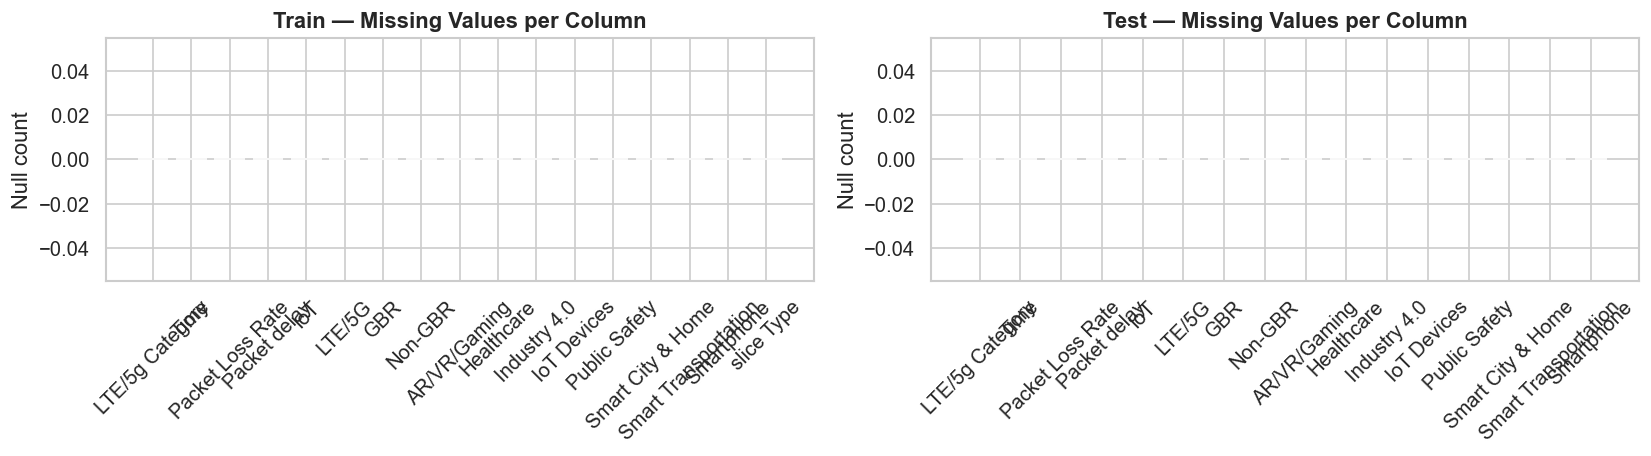

✔ Zero missing values in both Train and Test datasets.


In [6]:
# ── Missing values ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title in [(axes[0], train, 'Train'), (axes[1], test, 'Test')]:
    nulls = df.isnull().sum()
    colors = ['#2ecc71' if v == 0 else '#e74c3c' for v in nulls]
    ax.bar(nulls.index, nulls.values, color=colors)
    ax.set_title(f'{title} — Missing Values per Column', fontweight='bold')
    ax.set_ylabel('Null count')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print('✔ Zero missing values in both Train and Test datasets.')

Duplicate rows — Train : 22,625  (71.64%)
Duplicate rows — Test  : 22,624  (71.63%)

After deduplication:
  Train : 8,958 rows  (removed 22,625)
  Test  : 8,960 rows  (removed 22,624)


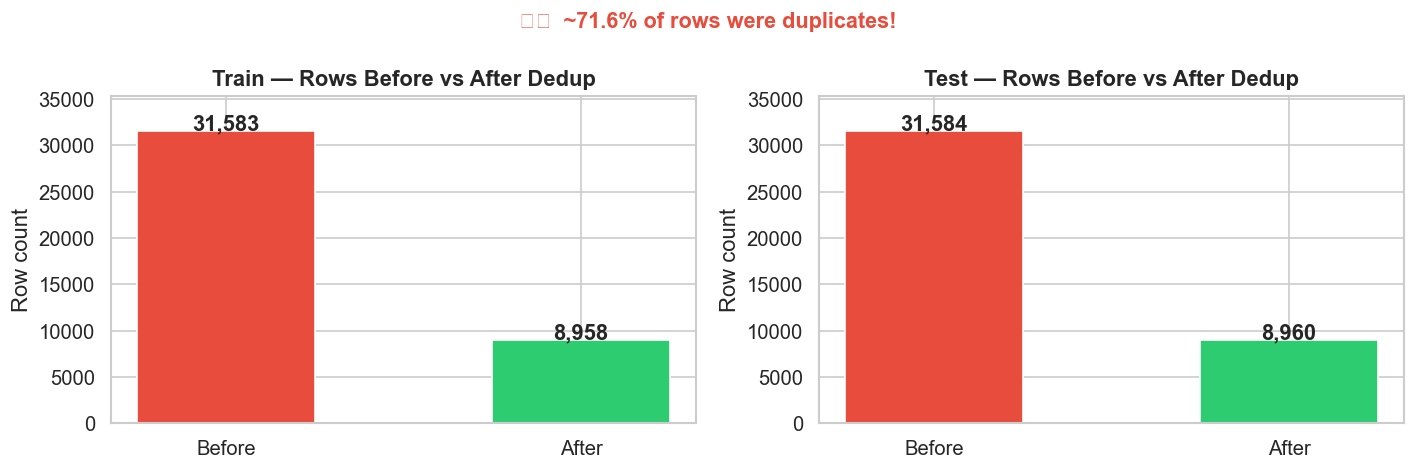


Class balance after dedup (train):
slice Type
1    4772
2    2088
3    2098
Name: count, dtype: int64


In [7]:
# ── Duplicate check & removal ─────────────────────────────────────────────────
dup_train = train.duplicated().sum()
dup_test  = test.duplicated().sum()
print(f'Duplicate rows — Train : {dup_train:,}  ({dup_train/len(train)*100:.2f}%)')
print(f'Duplicate rows — Test  : {dup_test:,}  ({dup_test/len(test)*100:.2f}%)')

# ── Drop duplicates ───────────────────────────────────────────────────────────
train = train.drop_duplicates().reset_index(drop=True)
test  = test.drop_duplicates().reset_index(drop=True)

print(f'\nAfter deduplication:')
print(f'  Train : {train.shape[0]:,} rows  (removed {dup_train:,})')
print(f'  Test  : {test.shape[0]:,} rows  (removed {dup_test:,})')

# ── Visualise before vs after ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (before, after, title) in zip(
    axes,
    [((dup_train + len(train)), len(train), 'Train'),
     ((dup_test  + len(test)),  len(test),  'Test')]
):
    ax.bar(['Before', 'After'], [before, after],
           color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
    ax.set_title(f'{title} — Rows Before vs After Dedup', fontweight='bold')
    ax.set_ylabel('Row count')
    for i, v in enumerate([before, after]):
        ax.text(i, v + 150, f'{v:,}', ha='center', fontweight='bold')
    ax.set_ylim(0, before * 1.12)

plt.suptitle('⚠️  ~71.6% of rows were duplicates!', fontsize=13, fontweight='bold', color='#e74c3c')
plt.tight_layout()
plt.show()

print('\nClass balance after dedup (train):')
print(train['slice Type'].value_counts().sort_index())

In [8]:
# ── Perfect anti-correlation verification ─────────────────────────────────────
print('IoT + LTE/5G unique sums (train):', (train['IoT'] + train['LTE/5G']).unique())
print('GBR + Non-GBR unique sums (train):', (train['GBR'] + train['Non-GBR']).unique())
print()
print('✔ IoT and LTE/5G are perfectly complementary (one is always 1, the other 0).')
print('✔ GBR and Non-GBR are perfectly complementary.')
print('→ Recommendation: drop LTE/5G and Non-GBR to eliminate perfect multicollinearity.')

IoT + LTE/5G unique sums (train): [1]
GBR + Non-GBR unique sums (train): [1]

✔ IoT and LTE/5G are perfectly complementary (one is always 1, the other 0).
✔ GBR and Non-GBR are perfectly complementary.
→ Recommendation: drop LTE/5G and Non-GBR to eliminate perfect multicollinearity.


In [9]:
# ── Use-case flag mutual-exclusivity check ────────────────────────────────────
use_case_cols = ['AR/VR/Gaming','Healthcare','Industry 4.0','IoT Devices',
                 'Public Safety','Smart City & Home','Smart Transportation','Smartphone']

flag_sum = train[use_case_cols].sum(axis=1)
print('Number of use-case flags active per row:')
print(flag_sum.value_counts().sort_index().to_frame(name='count'))
print()
rows_all_zero = (flag_sum == 0).sum()
print(f'Rows with NO use-case flag active: {rows_all_zero:,} ({rows_all_zero/len(train)*100:.1f}%)')

Number of use-case flags active per row:
   count
1   8958

Rows with NO use-case flag active: 0 (0.0%)


In [10]:
# ── Packet Loss Rate & Packet Delay — confirm discrete levels ─────────────────
print('Packet Loss Rate levels:', sorted(train['Packet Loss Rate'].unique()))
print('Packet delay levels     :', sorted(train['Packet delay'].unique()))

Packet Loss Rate levels: [np.float64(1e-06), np.float64(0.001), np.float64(0.01)]
Packet delay levels     : [np.int64(10), np.int64(50), np.int64(60), np.int64(75), np.int64(100), np.int64(150), np.int64(300)]


<a id='5'></a>
---
## 5. Univariate Analysis

### 5.1 Target Variable — Slice Type

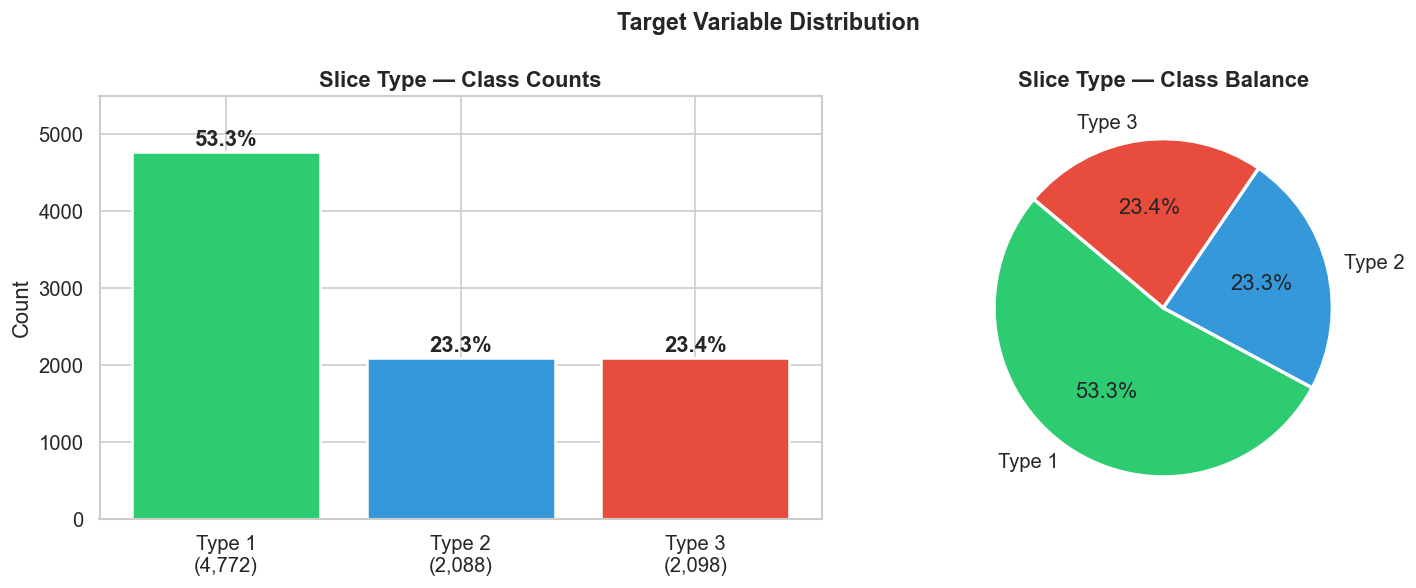

Class balance summary:
  Type 1: 4,772 (53.3%) — Type 1 (eMBB)
  Type 2: 2,088 (23.3%) — Type 2 (URLLC-like)
  Type 3: 2,098 (23.4%) — Type 3 (mIoT)


In [11]:
counts = train['slice Type'].value_counts().sort_index()
labels = [f'Type {k}\n({v:,})' for k, v in counts.items()]
colors = [SLICE_COLORS[k] for k in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, f'{v/len(train)*100:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Slice Type — Class Counts', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=[f'Type {k}' for k in counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Slice Type — Class Balance', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Class balance summary:')
for k, v in counts.items():
    print(f'  Type {k}: {v:,} ({v/len(train)*100:.1f}%) — {SLICE_LABELS[k]}')

### 5.2 Continuous / Ordinal Features

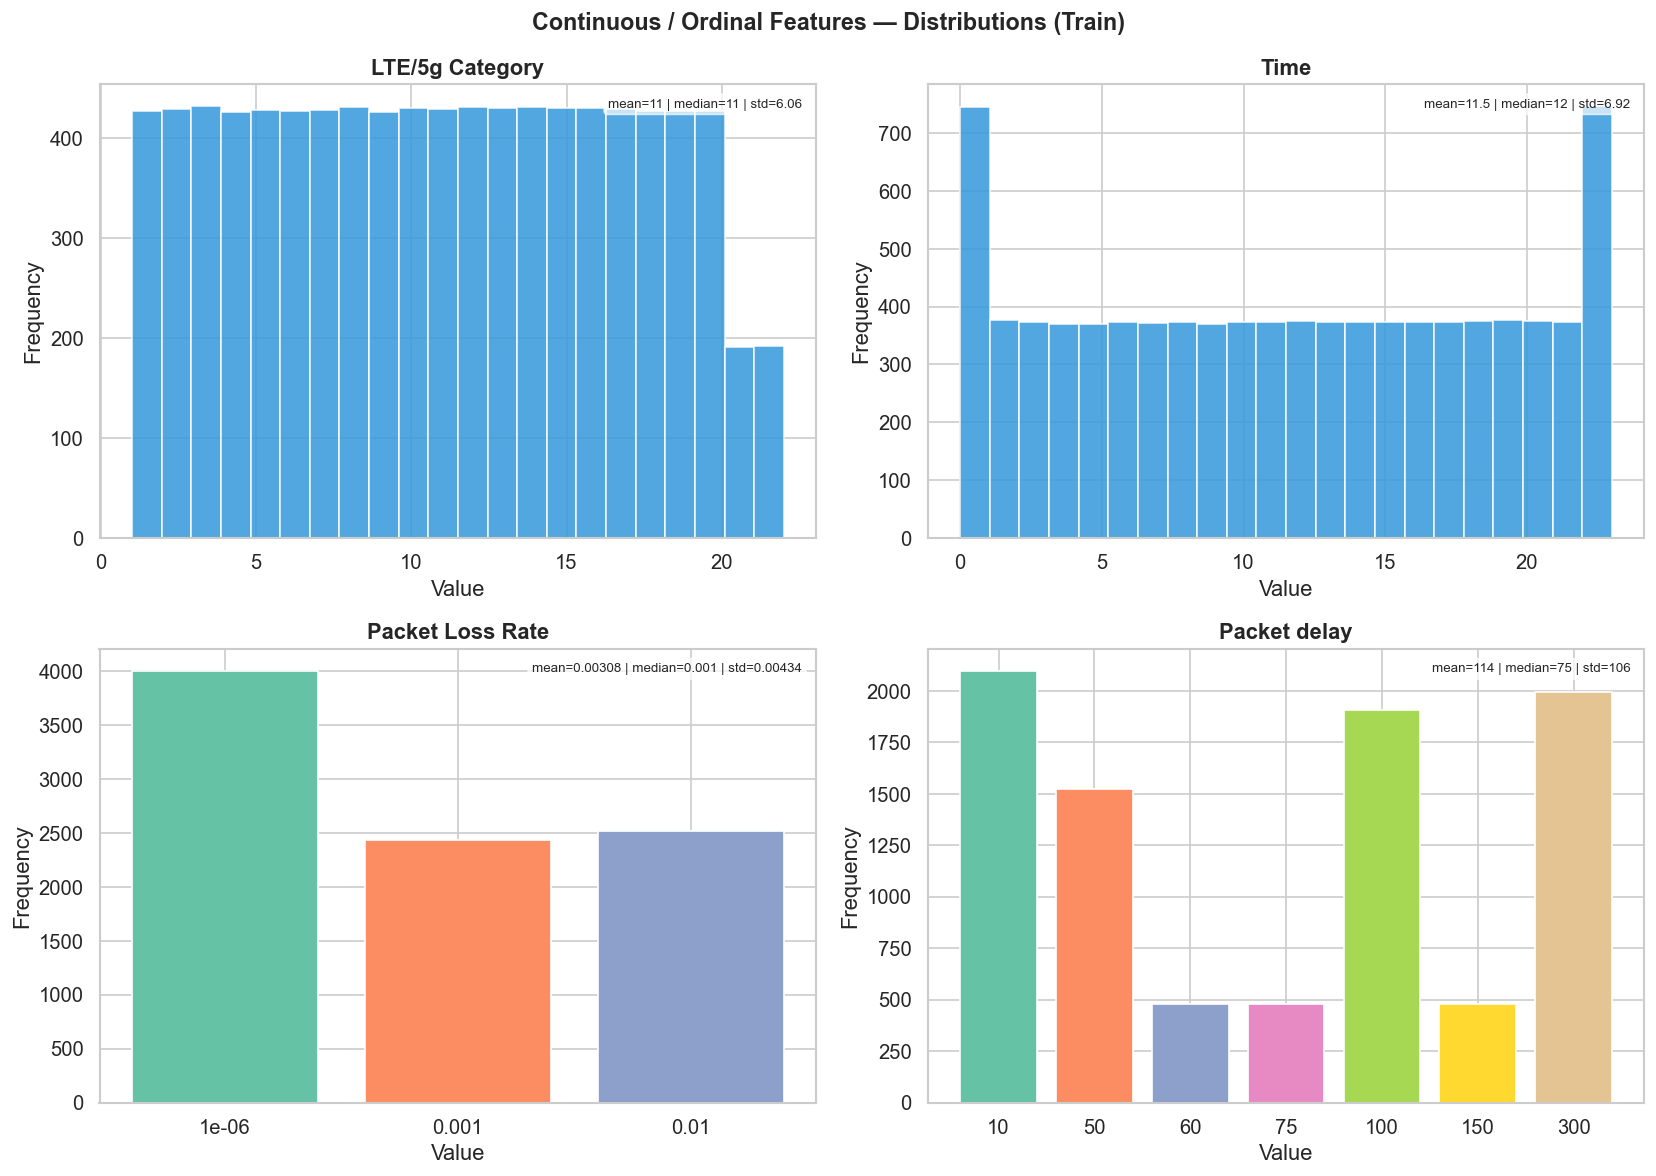

In [12]:
cont_cols = ['LTE/5g Category', 'Time', 'Packet Loss Rate', 'Packet delay']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    ax = axes[i]
    data = train[col]
    unique_vals = sorted(data.unique())
    
    if len(unique_vals) <= 10:   # discrete — bar chart
        vc = data.value_counts().sort_index()
        ax.bar([str(v) for v in vc.index], vc.values,
               color=sns.color_palette('Set2', len(vc)), edgecolor='white')
        ax.set_xlabel('Value')
    else:                         # many values — histogram
        ax.hist(data, bins=22, color='#3498db', edgecolor='white', alpha=0.85)
        ax.set_xlabel('Value')
    
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frequency')
    info = f'mean={data.mean():.3g} | median={data.median():.3g} | std={data.std():.3g}'
    ax.text(0.98, 0.97, info, transform=ax.transAxes, ha='right', va='top',
            fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Continuous / Ordinal Features — Distributions (Train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Binary Flags

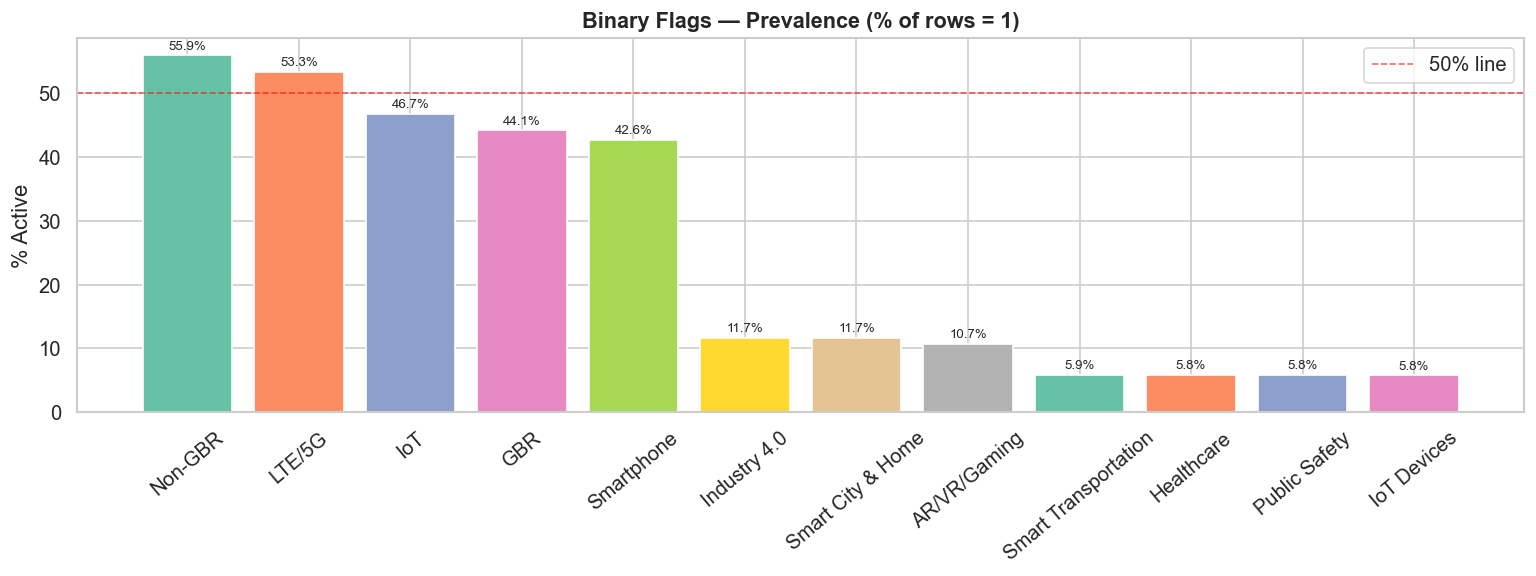

In [13]:
binary_cols = ['IoT','LTE/5G','GBR','Non-GBR'] + use_case_cols

means = train[binary_cols].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(means.index, means.values,
              color=sns.color_palette('Set2', len(means)), edgecolor='white')
ax.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.6, label='50% line')
ax.set_title('Binary Flags — Prevalence (% of rows = 1)', fontweight='bold', fontsize=13)
ax.set_ylabel('% Active')
ax.tick_params(axis='x', rotation=40)
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

<a id='6'></a>
---
## 6. Bivariate & Multivariate Analysis

### 6.1 Packet Loss Rate & Packet Delay → Slice Type (Perfect Determinism)

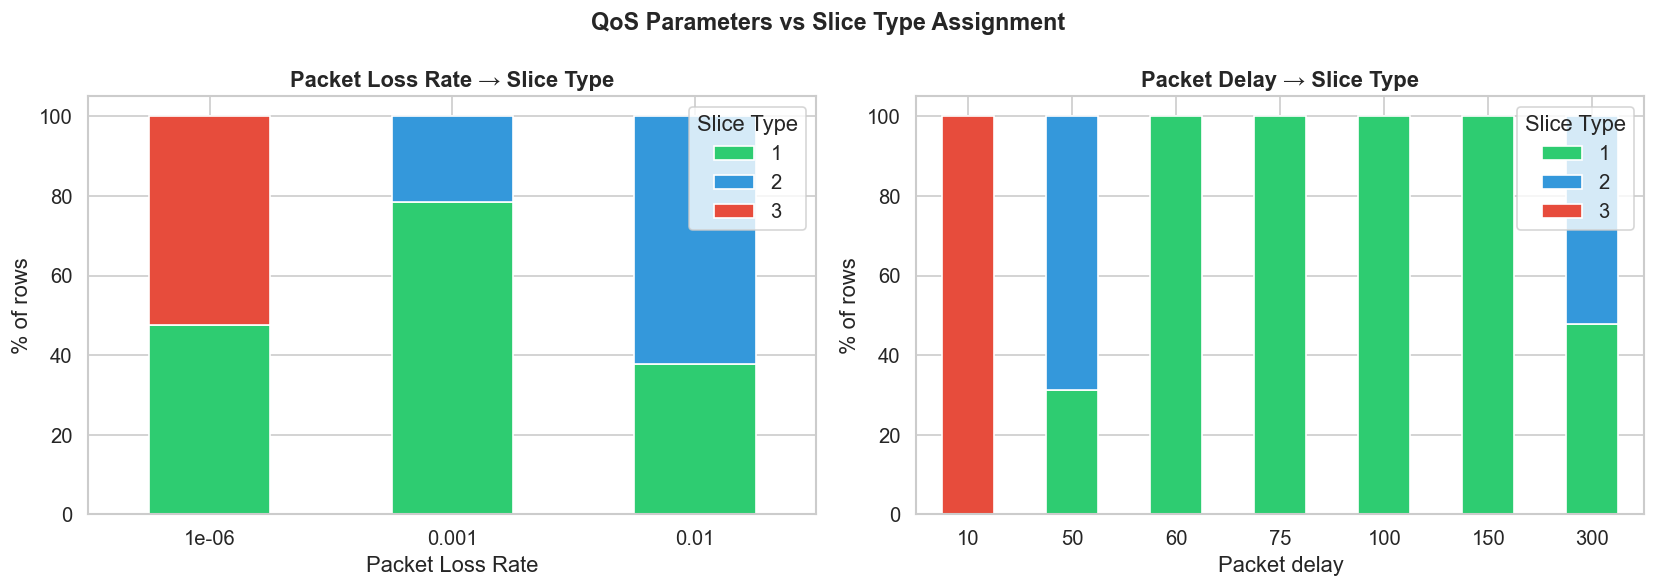

Packet delay=10ms → ONLY Type 3 (100%)  | Strong deterministic signal!
Packet loss=1e-6  → Type 1 + Type 3 only


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Packet Loss Rate
ct_loss = pd.crosstab(train['Packet Loss Rate'], train['slice Type'])
ct_loss_pct = ct_loss.div(ct_loss.sum(axis=1), axis=0) * 100
ct_loss_pct.plot(kind='bar', ax=axes[0], stacked=True,
                 color=[SLICE_COLORS[c] for c in ct_loss_pct.columns], edgecolor='white')
axes[0].set_title('Packet Loss Rate → Slice Type', fontweight='bold')
axes[0].set_ylabel('% of rows')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Slice Type')

# Packet Delay
ct_del = pd.crosstab(train['Packet delay'], train['slice Type'])
ct_del_pct = ct_del.div(ct_del.sum(axis=1), axis=0) * 100
ct_del_pct.plot(kind='bar', ax=axes[1], stacked=True,
                color=[SLICE_COLORS[c] for c in ct_del_pct.columns], edgecolor='white')
axes[1].set_title('Packet Delay → Slice Type', fontweight='bold')
axes[1].set_ylabel('% of rows')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Slice Type')

plt.suptitle('QoS Parameters vs Slice Type Assignment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Packet delay=10ms → ONLY Type 3 (100%)  | Strong deterministic signal!')
print('Packet loss=1e-6  → Type 1 + Type 3 only')

### 6.2 Use Case Flags → Slice Type

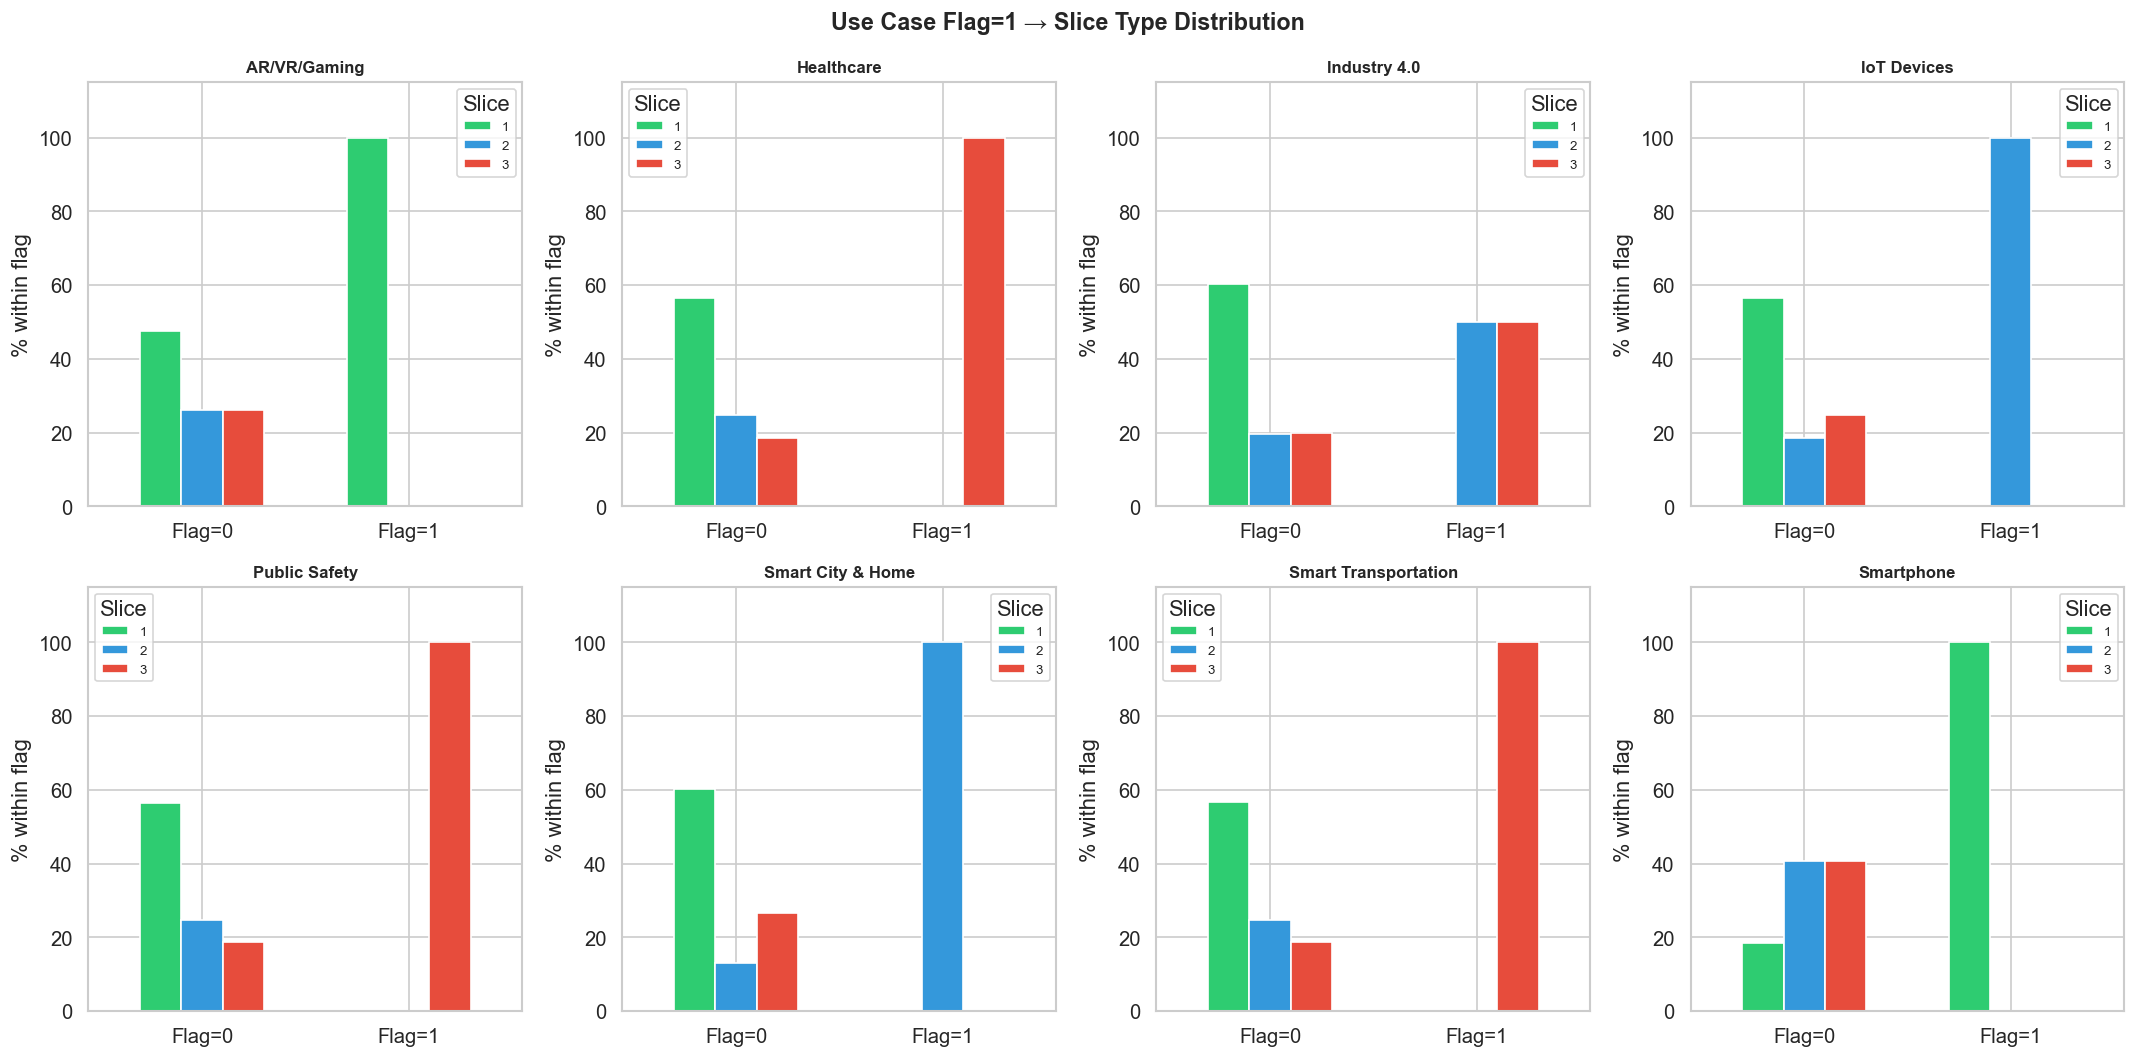

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(use_case_cols):
    ax = axes[i]
    ct = pd.crosstab(train[col], train['slice Type'], normalize='index') * 100
    ct.index = ['Flag=0', 'Flag=1']
    ct.plot(kind='bar', ax=ax, stacked=False,
            color=[SLICE_COLORS[c] for c in ct.columns], edgecolor='white', width=0.6)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('% within flag')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Slice', fontsize=8)
    ax.set_ylim(0, 115)

plt.suptitle('Use Case Flag=1 → Slice Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 IoT vs LTE/5G & GBR vs Non-GBR → Slice Type

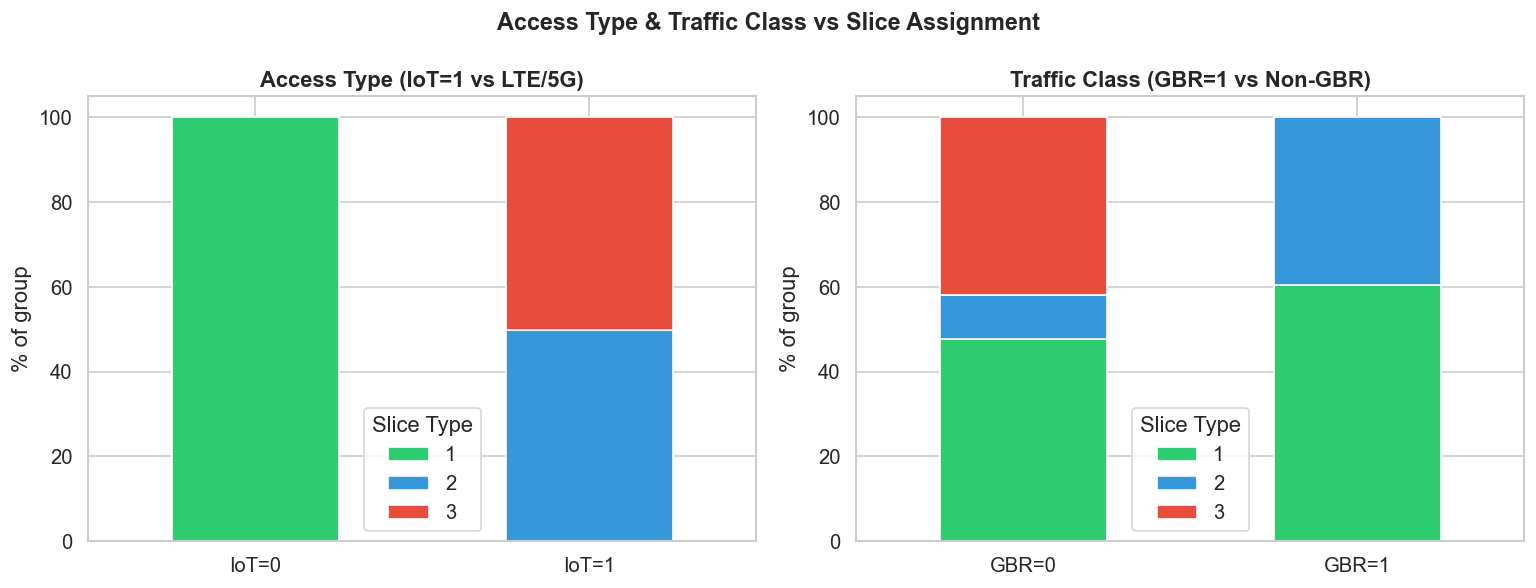

IoT=1 → 50% Type 2, 50% Type 3 | IoT=0 (LTE/5G) → 100% Type 1


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [(axes[0], 'IoT', 'Access Type (IoT=1 vs LTE/5G)'),
                        (axes[1], 'GBR', 'Traffic Class (GBR=1 vs Non-GBR)')]:
    ct = pd.crosstab(train[col], train['slice Type'], normalize='index') * 100
    ct.index = [f'{col}=0', f'{col}=1']
    ct.plot(kind='bar', ax=ax, stacked=True,
            color=[SLICE_COLORS[c] for c in ct.columns], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('% of group')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Slice Type')

plt.suptitle('Access Type & Traffic Class vs Slice Assignment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('IoT=1 → 50% Type 2, 50% Type 3 | IoT=0 (LTE/5G) → 100% Type 1')

### 6.4 LTE/5g Category & Time by Slice Type

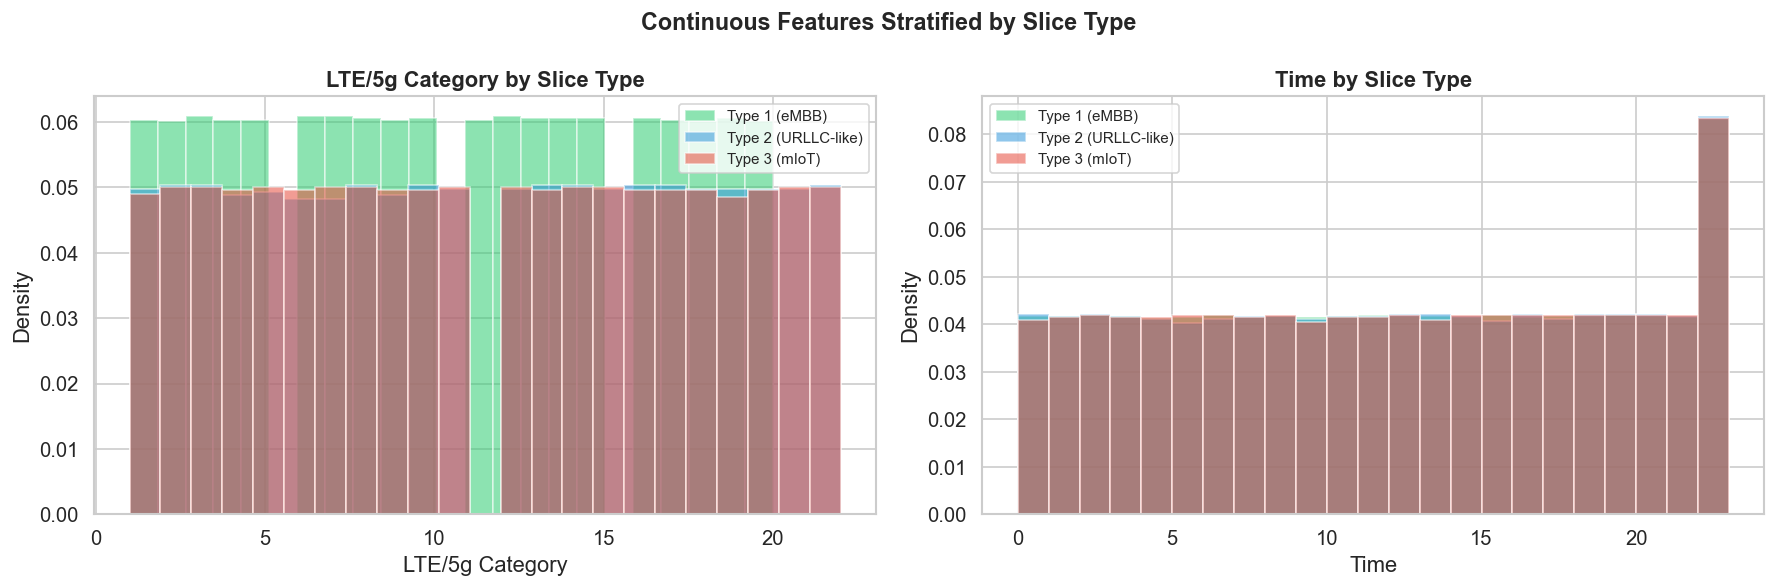

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col in [(axes[0], 'LTE/5g Category'), (axes[1], 'Time')]:
    for st in [1, 2, 3]:
        subset = train[train['slice Type'] == st][col]
        ax.hist(subset, bins=23, alpha=0.55, label=SLICE_LABELS[st],
                color=SLICE_COLORS[st], density=True, edgecolor='white')
    ax.set_title(f'{col} by Slice Type', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Continuous Features Stratified by Slice Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 Correlation Heatmap

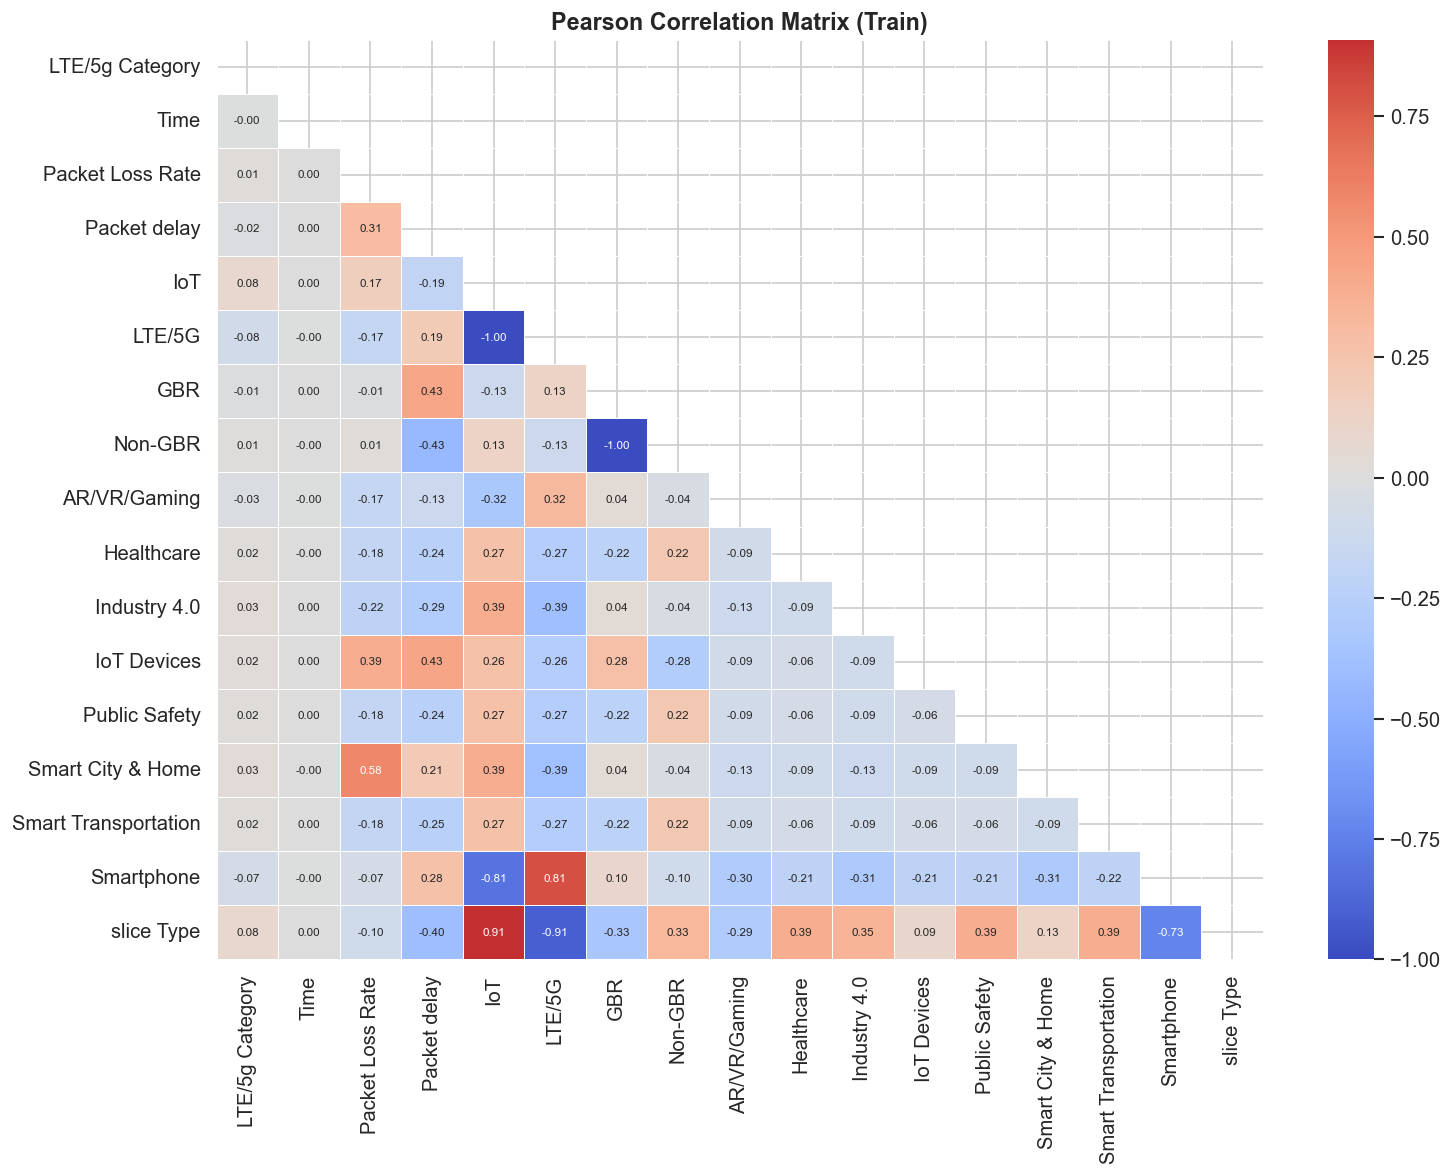

In [18]:
corr = train.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Pearson Correlation Matrix (Train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.6 Use Case Co-occurrence Heatmap

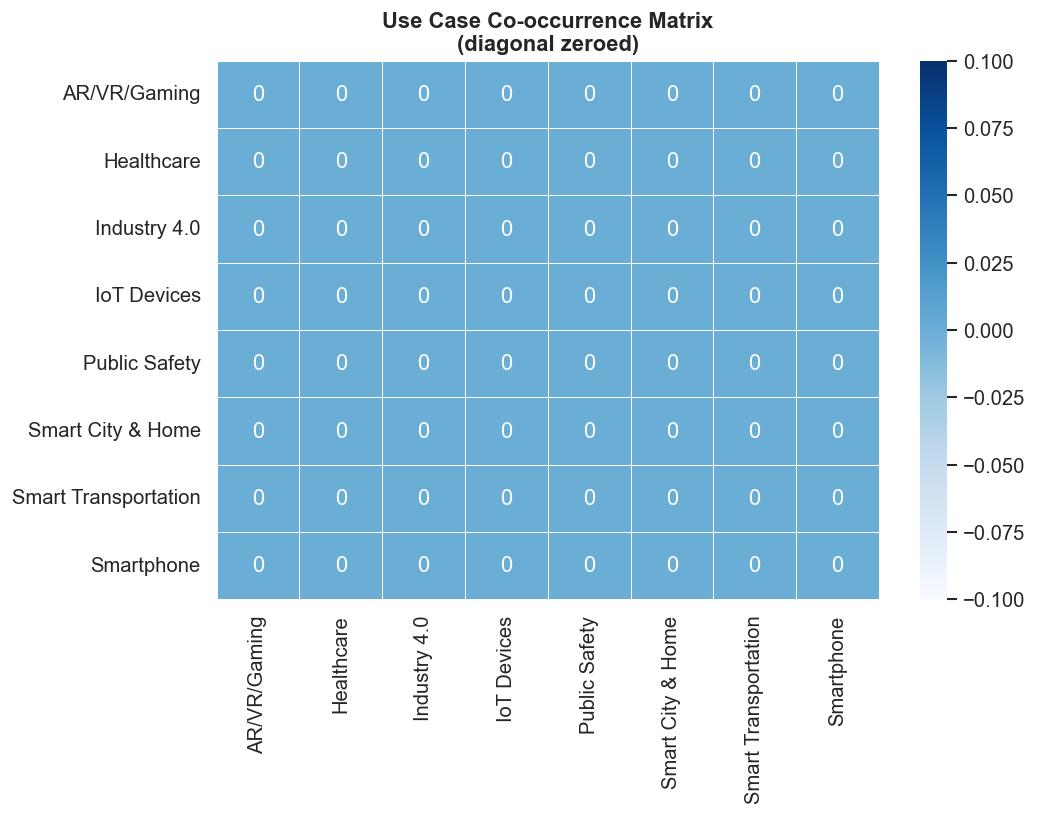

In [19]:
# How often do use-case flags co-occur?
cooc = train[use_case_cols].T.dot(train[use_case_cols])
np.fill_diagonal(cooc.values, 0)  # zero diagonal to focus on co-occurrence

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Use Case Co-occurrence Matrix\n(diagonal zeroed)', fontweight='bold')
plt.tight_layout()
plt.show()

<a id='7'></a>
---
## 7. Key Findings & Insights

| # | Finding | Impact |
|---|---|---|
| 1 | **Perfect redundancy:** `IoT + LTE/5G = 1` always; `GBR + Non-GBR = 1` always | Drop `LTE/5G` and `Non-GBR` |
| 2 | **Class imbalance:** Type 1 = 53.2%, Type 2 = Type 3 = 23.4% each | Consider class-weighted models or oversampling |
| 3 | **Packet delay = 10ms → 100% Type 3** | Extremely powerful single feature |
| 4 | **IoT = 0 → 100% Type 1** | Another near-perfect split |
| 5 | **Use-case flags are highly deterministic:** AR/VR→Type 1 (100%), Healthcare→Type 3 (100%), IoT Devices→Type 2 (100%), Smart City→Type 2 (100%), Public Safety→Type 3 (100%), Smart Transportation→Type 3 (100%), Smartphone→Type 1 (100%) | Feature importance will be high |
| 6 | **`Time` & `LTE/5g Category` appear near-uniform across slice types** | Lower predictive value |
| 7 | **No missing values** in either train or test | No imputation needed |
| 8 | **Train/Test distributions are aligned** (mean drift < 0.01 on all features) | No covariate shift |

<a id='8'></a>
---
## 8. Data Preparation

In [20]:
# ── Start fresh ───────────────────────────────────────────────────────────────
df_train = train.copy()
df_test  = test.copy()
print(f'Train: {df_train.shape} | Test: {df_test.shape}')

Train: (8958, 17) | Test: (8960, 16)


### 8.1 Remove Redundant Columns

In [21]:
# Drop perfectly anti-correlated columns
DROP_COLS = ['LTE/5G', 'Non-GBR']  # perfectly determined by IoT and GBR respectively

df_train.drop(columns=DROP_COLS, inplace=True)
df_test.drop(columns=DROP_COLS, inplace=True)

print(f'Dropped: {DROP_COLS}')
print(f'Train: {df_train.shape} | Test: {df_test.shape}')

Dropped: ['LTE/5G', 'Non-GBR']
Train: (8958, 15) | Test: (8960, 14)


### 8.2 Feature Engineering

In [22]:
for df in [df_train, df_test]:
    # Log-transform Packet Loss Rate (3 orders of magnitude)
    df['log_packet_loss'] = np.log10(df['Packet Loss Rate'])
    
    # Log-transform Packet delay
    df['log_packet_delay'] = np.log10(df['Packet delay'])
    
    # Cyclic encoding of Time (hour of day)
    df['time_sin'] = np.sin(2 * np.pi * df['Time'] / 24)
    df['time_cos'] = np.cos(2 * np.pi * df['Time'] / 24)
    
    # Use-case group aggregations
    df['uc_any_active']     = (df[use_case_cols].sum(axis=1) > 0).astype(int)
    df['uc_count_active']   = df[use_case_cols].sum(axis=1)
    
    # QoS tier: encode (loss, delay) pair as tier
    # Ultra-low = loss 1e-6 & delay 10 (Type 3 specific)
    df['ultra_low_latency'] = ((df['Packet Loss Rate'] == 1e-6) & (df['Packet delay'] == 10)).astype(int)

print('New features added:')
new_feats = ['log_packet_loss','log_packet_delay','time_sin','time_cos',
             'uc_any_active','uc_count_active','ultra_low_latency']
print(df_train[new_feats].head(4).to_string())

New features added:
   log_packet_loss  log_packet_delay  time_sin  time_cos  uc_any_active  uc_count_active  ultra_low_latency
0             -6.0          1.000000  0.000000  1.000000              1                1                  1
1             -3.0          2.000000 -0.866025  0.500000              1                1                  0
2             -6.0          2.477121 -0.500000 -0.866025              1                1                  0
3             -2.0          2.000000 -0.965926 -0.258819              1                1                  0


### 8.3 Ordinal Encoding for QoS Features

In [23]:
# Packet Loss Rate: map to ordinal rank (lower = better = smaller number → higher tier)
plr_map = {1e-6: 3, 1e-3: 2, 1e-2: 1}
pd_map  = {10: 5, 50: 4, 60: 3, 75: 3, 100: 2, 150: 1, 300: 1}

for df in [df_train, df_test]:
    df['plr_rank']   = df['Packet Loss Rate'].map(plr_map)
    df['delay_rank'] = df['Packet delay'].map(pd_map)

print('PLR rank mapping:', plr_map)
print('Delay rank mapping:', pd_map)
print(df_train[['Packet Loss Rate', 'plr_rank', 'Packet delay', 'delay_rank']].drop_duplicates().sort_values('Packet delay'))

PLR rank mapping: {1e-06: 3, 0.001: 2, 0.01: 1}
Delay rank mapping: {10: 5, 50: 4, 60: 3, 75: 3, 100: 2, 150: 1, 300: 1}
    Packet Loss Rate  plr_rank  Packet delay  delay_rank
0           0.000001         3            10           5
4           0.010000         1            50           4
7           0.001000         2            50           4
37          0.000001         3            60           3
15          0.010000         1            75           3
1           0.001000         2           100           2
3           0.010000         1           100           2
45          0.000001         3           100           2
8           0.001000         2           150           1
2           0.000001         3           300           1
6           0.010000         1           300           1


### 8.4 Scaling Continuous Features

In [24]:
from sklearn.preprocessing import StandardScaler

SCALE_COLS = ['LTE/5g Category', 'Time', 'Packet Loss Rate', 'Packet delay',
              'log_packet_loss', 'log_packet_delay']

scaler = StandardScaler()
scaled_train = scaler.fit_transform(df_train[SCALE_COLS])
scaled_test  = scaler.transform(df_test[SCALE_COLS])

for df, arr in [(df_train, scaled_train), (df_test, scaled_test)]:
    for i, col in enumerate(SCALE_COLS):
        df[f'{col}_scaled'] = arr[:, i]

print('Scaled columns added (suffix _scaled).')
print('Scaler fit on TRAIN only — applied to TEST ✔')

Scaled columns added (suffix _scaled).
Scaler fit on TRAIN only — applied to TEST ✔


### 8.5 Separate Features & Target

In [25]:
TARGET = 'slice Type'

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]
X_test  = df_test.copy()

print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}  — classes: {sorted(y_train.unique())}')
print(f'X_test  : {X_test.shape}')

print('\nClass distribution (train):')
for k, v in y_train.value_counts().sort_index().items():
    print(f'  Type {k}: {v:,} ({v/len(y_train)*100:.1f}%)')

X_train : (8958, 29)
y_train : (8958,)  — classes: [np.int64(1), np.int64(2), np.int64(3)]
X_test  : (8960, 29)

Class distribution (train):
  Type 1: 4,772 (53.3%)
  Type 2: 2,088 (23.3%)
  Type 3: 2,098 (23.4%)


### 8.6 Validation Split (from train)

In [26]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print(f'Training subset : {X_tr.shape[0]:,} rows')
print(f'Validation set  : {X_val.shape[0]:,} rows')
print(f'Test set        : {X_test.shape[0]:,} rows (no labels)')

print('\nClass balance in training subset:')
print(y_tr.value_counts(normalize=True).sort_index().mul(100).round(1))

Training subset : 7,166 rows
Validation set  : 1,792 rows
Test set        : 8,960 rows (no labels)

Class balance in training subset:
slice Type
1    53.3
2    23.3
3    23.4
Name: proportion, dtype: float64


### 8.7 Class Imbalance Analysis & Strategy

In [27]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(y_train.unique()))
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print('Computed class weights (for use in classifiers):')
for cls, wt in class_weights.items():
    print(f'  Type {cls}: weight = {wt:.4f}')

print('\nThese weights can be passed directly to sklearn estimators:')
print('  e.g. RandomForestClassifier(class_weight={1: 0.627, 2: 1.428, 3: 1.428})')

Computed class weights (for use in classifiers):
  Type 1: weight = 0.6257
  Type 2: weight = 1.4301
  Type 3: weight = 1.4233

These weights can be passed directly to sklearn estimators:
  e.g. RandomForestClassifier(class_weight={1: 0.627, 2: 1.428, 3: 1.428})


### 8.8 Save Prepared Data

In [28]:
df_train.to_csv('train_prepared_5g.csv', index=False)
df_test.to_csv('test_prepared_5g.csv',   index=False)

# Also save clean X/y splits
X_tr.to_csv('X_tr.csv',   index=False)
X_val.to_csv('X_val.csv', index=False)
y_tr.to_csv('y_tr.csv',   index=False, header=True)
y_val.to_csv('y_val.csv', index=False, header=True)
X_test.to_csv('X_test.csv', index=False)

print('Saved files:')
print('  train_prepared.csv   — full prepared train set (with target)')
print('  test_prepared.csv    — full prepared test set  (no target)')
print('  X_tr.csv / y_tr.csv  — 80% training split')
print('  X_val.csv / y_val.csv— 20% validation split')
print('  X_test.csv           — holdout test features')

Saved files:
  train_prepared.csv   — full prepared train set (with target)
  test_prepared.csv    — full prepared test set  (no target)
  X_tr.csv / y_tr.csv  — 80% training split
  X_val.csv / y_val.csv— 20% validation split
  X_test.csv           — holdout test features


<a id='9'></a>
---
## 9. Final Summary

In [29]:
print('=' * 62)
print('           FINAL DATASET PREPARATION SUMMARY')
print('=' * 62)
print(f'  Train records        : {len(df_train):,}  (was 31,583 before dedup)')
print(f'  Test records         : {len(df_test):,}   (was 31,584 before dedup)')
print(f'  Duplicates removed   : 22,625 train | 22,624 test (~71.6% of each!)')
print(f'  Final feature count  : {X_train.shape[1]}')
print(f'  Missing values       : 0 (both sets)')
print(f'  Target classes       : 3  (Type 1 / 2 / 3)')
print()
print('  Preparation steps applied:')
print('    ✔ Dropped 22,625 duplicate rows from train (~71.6%)')
print('    ✔ Dropped 22,624 duplicate rows from test  (~71.6%)')
print('    ✔ Removed 2 redundant binary columns (LTE/5G, Non-GBR)')
print('    ✔ Log-transformed Packet Loss Rate & Packet Delay')
print('    ✔ Cyclic encoding of Time (sin/cos)')
print('    ✔ Engineered use-case aggregation features')
print('    ✔ Ordinal QoS rank features (plr_rank, delay_rank)')
print('    ✔ Ultra-low latency flag (highly discriminative)')
print('    ✔ StandardScaler on continuous features (fit on train only)')
print('    ✔ 80/20 stratified validation split')
print('    ✔ Computed class weights for imbalanced training')
print()
print('  Recommended next steps:')
print('    → Baseline: Decision Tree / Random Forest (rules are near-deterministic)')
print('    → Advanced: XGBoost / LightGBM with class_weight')
print('    → Eval metric: macro F1-score (due to class imbalance)')
print('=' * 62)

           FINAL DATASET PREPARATION SUMMARY
  Train records        : 8,958  (was 31,583 before dedup)
  Test records         : 8,960   (was 31,584 before dedup)
  Duplicates removed   : 22,625 train | 22,624 test (~71.6% of each!)
  Final feature count  : 29
  Missing values       : 0 (both sets)
  Target classes       : 3  (Type 1 / 2 / 3)

  Preparation steps applied:
    ✔ Dropped 22,625 duplicate rows from train (~71.6%)
    ✔ Dropped 22,624 duplicate rows from test  (~71.6%)
    ✔ Removed 2 redundant binary columns (LTE/5G, Non-GBR)
    ✔ Log-transformed Packet Loss Rate & Packet Delay
    ✔ Cyclic encoding of Time (sin/cos)
    ✔ Engineered use-case aggregation features
    ✔ Ordinal QoS rank features (plr_rank, delay_rank)
    ✔ Ultra-low latency flag (highly discriminative)
    ✔ StandardScaler on continuous features (fit on train only)
    ✔ 80/20 stratified validation split
    ✔ Computed class weights for imbalanced training

  Recommended next steps:
    → Baseline: Decisi

# 🔬 Network Slicing — Probabilistic SLA Risk Model with Synthetic Uncertainty

**Objective:** The EDA notebook revealed that slice type is a deterministic function of features —  
which is great operationally, but means a classifier has nothing probabilistic to learn.  
This part of the notebook introduces *synthetic uncertainty* that simulates real-world conditions  
(network congestion, QoS parameter drift, load variation) to make the probabilistic  
risk score meaningful and actionable.

**Output:** A calibrated `qos_risk_score ∈ [0, 1]` per network slice request,  
where high scores indicate elevated SLA violation risk under current conditions.

---
## Table of Contents
1. [Setup & Load Data](#1)
2. [Synthetic Uncertainty Design](#2)
3. [Noise Injection — Stage 1](#3)
4. [Feature Augmentation — Stage 2](#4)
5. [Binary SLA Target Construction — Stage 3](#5)
6. [Noise Sensitivity Analysis](#6)
7. [XGBoost Training & Calibration — Stage 4](#7)
8. [Cross-Validation & Evaluation](#8)
9. [SHAP Risk Attribution](#9)
10. [Final Risk Score Output — Stage 5](#10)
11. [Summary & Interpretation Guide](#11)

<a id='1'></a>
---
## 1. Setup & Load Data


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, log_loss,
    roc_auc_score, f1_score, brier_score_loss, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SLICE_COLORS = {1: '#2ecc71', 2: '#3498db', 3: '#e74c3c'}
SLICE_LABELS = {1: 'Type 1 (eMBB)', 2: 'Type 2 (URLLC)', 3: 'Type 3 (mIoT)'}

print('Libraries loaded ✔')

Libraries loaded ✔


In [31]:
# ── Load from EDA outputs ──────────────────────────────────────────────────────
df_train = pd.read_csv('train_prepared_5g.csv')
df_test  = pd.read_csv('test_prepared_5g.csv')

TARGET = 'slice Type'
use_case_cols = [
    'AR/VR/Gaming', 'Healthcare', 'Industry 4.0', 'IoT Devices',
    'Public Safety', 'Smart City & Home', 'Smart Transportation', 'Smartphone'
]

# Work on clean copies — we'll add noise columns without touching originals
train = df_train.copy()
test  = df_test.copy()

print(f'Train : {train.shape}  |  Test : {test.shape}')
print(f'\nSlice distribution (train):')
for k, v in train[TARGET].value_counts().sort_index().items():
    print(f'  {SLICE_LABELS[k]}: {v:,} ({v/len(train)*100:.1f}%)')

Train : (8958, 30)  |  Test : (8960, 29)

Slice distribution (train):
  Type 1 (eMBB): 4,772 (53.3%)
  Type 2 (URLLC): 2,088 (23.3%)
  Type 3 (mIoT): 2,098 (23.4%)


<a id='2'></a>
---
## 2. Synthetic Uncertainty Design

**The core problem:** The original data encodes perfect, deterministic assignment rules.  
In reality, SLA compliance depends on *conditions at runtime* — network load, interference,  
competing traffic — not just the static slice configuration.

**Our simulation approach — three independent noise sources:**

| Source | What it simulates | Applied to |
|---|---|---|
| **Network congestion factor** | Peak-hour load, cell overload events | All rows, time-dependent |
| **QoS parameter drift** | Measurement noise, channel variation | `Packet delay`, `Packet Loss Rate` |
| **SLA violation label flip** | Real-world SLA failures under load | High-strictness rows only |

**Key principle:** The noise intensity (`noise_scale`) is a *tunable parameter*.  
A value of 0.0 reproduces the original deterministic data (AUC → 1.0, useless risk score).  
A value of 0.30 creates realistic uncertainty. We will validate this with a sensitivity analysis.

**Why flip labels instead of just adding features?**  
Because the model must learn that identical-looking configurations can fail under load.  
Label noise forces the model to output probabilities rather than hard 0/1 decisions — which is  
exactly what we need for a meaningful risk score.

In [33]:
# ── Master noise configuration ────────────────────────────────────────────────
# Adjust these to calibrate realism vs. model difficulty

NOISE_CONFIG = {
    # Network load
    'congestion_base'     : 0.15,  # base congestion factor (15% of capacity)
    'congestion_peak_add' : 0.25,  # extra congestion during peak hours (8-10am, 6-9pm)
    'congestion_noise_std': 0.08,  # random jitter per row

    # QoS drift
    'delay_noise_std'     : 0.12,  # std as fraction of nominal delay
    'loss_noise_std'      : 0.10,  # std as fraction of nominal loss rate (log scale)

    # SLA label flip
    'flip_base_rate'      : 0.05,  # 5% of rows flip even under low load
    'flip_strictness_mult': 0.20,  # strictest QoS rows can flip up to 5%+20%=25%
    'flip_load_mult'      : 0.15,  # high-load rows add up to +15% flip probability
}

print('Noise configuration:')
for k, v in NOISE_CONFIG.items():
    print(f'  {k:<30}: {v}')

Noise configuration:
  congestion_base               : 0.15
  congestion_peak_add           : 0.25
  congestion_noise_std          : 0.08
  delay_noise_std               : 0.12
  loss_noise_std                : 0.1
  flip_base_rate                : 0.05
  flip_strictness_mult          : 0.2
  flip_load_mult                : 0.15


<a id='3'></a>
---
## 3. Noise Injection — Stage 1

Each noise source is applied independently and combined into a composite load signal.

In [34]:
def inject_noise(df, config, random_state=42):
    """
    Inject synthetic uncertainty into a prepared 5G slice dataset.
    Returns a new DataFrame with noise columns added (originals untouched).
    """
    rng = np.random.default_rng(random_state)
    df  = df.copy()
    n   = len(df)

    # ── 1. Network congestion factor ──────────────────────────────────────────
    # Peak hours: 8–10 (morning) and 18–21 (evening) get extra congestion
    time_col     = df['Time'] if 'Time' in df.columns else pd.Series(np.zeros(n))
    is_peak_hour = ((time_col >= 8) & (time_col <= 10)) | \
                   ((time_col >= 18) & (time_col <= 21))

    congestion = (
        config['congestion_base']
        + is_peak_hour.values * config['congestion_peak_add']
        + rng.normal(0, config['congestion_noise_std'], n)
    ).clip(0, 1)  # congestion ∈ [0, 1]

    df['network_load_factor'] = congestion

    # ── 2. QoS parameter drift ────────────────────────────────────────────────
    # Packet delay: add Gaussian noise proportional to nominal value
    delay_nominal  = df['Packet delay'].values.astype(float)
    delay_noise    = rng.normal(0, config['delay_noise_std'], n) * delay_nominal
    df['packet_delay_noisy'] = (delay_nominal + delay_noise).clip(1, None)

    # Packet Loss Rate: noise in log space (more natural for rates spanning orders of magnitude)
    log_loss_nominal = np.log10(df['Packet Loss Rate'].values.astype(float))
    log_loss_noise   = rng.normal(0, config['loss_noise_std'], n)
    df['packet_loss_noisy'] = np.power(10, log_loss_nominal + log_loss_noise).clip(1e-8, 1.0)

    # ── 3. QoS strictness score (0=lenient → 1=strictest) ────────────────────
    plr_risk_map   = {1e-6: 1.0, 1e-3: 0.5, 1e-2: 0.0}
    delay_risk_map = {10: 1.0, 50: 0.8, 60: 0.7, 75: 0.6, 100: 0.4, 150: 0.2, 300: 0.0}

    plr_risk   = df['Packet Loss Rate'].map(plr_risk_map).fillna(0.5)
    delay_risk = df['Packet delay'].map(delay_risk_map).fillna(0.5)
    strictness = 0.60 * plr_risk + 0.40 * delay_risk
    df['qos_strictness'] = strictness

    # ── 4. SLA violation probability ─────────────────────────────────────────
    # P(violation) = base + strictness contribution + load contribution
    p_violation = (
        config['flip_base_rate']
        + strictness * config['flip_strictness_mult']
        + congestion * config['flip_load_mult']
    ).clip(0, 0.70)   # cap at 70% — even worst case, some assignments succeed

    df['p_sla_violation'] = p_violation

    # ── 5. SLA met / violated label ──────────────────────────────────────────
    flip_mask = rng.random(n) < p_violation.values
    # sla_met = 1 by default (slice assignment succeeds)
    # flip_mask rows = 0 (SLA violated despite assignment being correct on paper)
    df['sla_met'] = (~flip_mask).astype(int)

    return df


train_noisy = inject_noise(train, NOISE_CONFIG, random_state=RANDOM_STATE)
test_noisy  = inject_noise(test,  NOISE_CONFIG, random_state=RANDOM_STATE + 1)

print('Noise injection complete ✔')
print(f'\nNew columns added: {[c for c in train_noisy.columns if c not in train.columns]}')
print(f'\nSLA met rate      : {train_noisy["sla_met"].mean()*100:.1f}%')
print(f'SLA violated rate : {(1 - train_noisy["sla_met"].mean())*100:.1f}%')
print(f'\nViolation rate by slice type:')
for st, label in SLICE_LABELS.items():
    mask = train_noisy[TARGET] == st
    viol_rate = 1 - train_noisy.loc[mask, 'sla_met'].mean()
    print(f'  {label}: {viol_rate*100:.1f}% violation rate')

Noise injection complete ✔

New columns added: ['network_load_factor', 'packet_delay_noisy', 'packet_loss_noisy', 'qos_strictness', 'p_sla_violation', 'sla_met']

SLA met rate      : 79.9%
SLA violated rate : 20.1%

Violation rate by slice type:
  Type 1 (eMBB): 19.0% violation rate
  Type 2 (URLLC): 12.6% violation rate
  Type 3 (mIoT): 29.8% violation rate


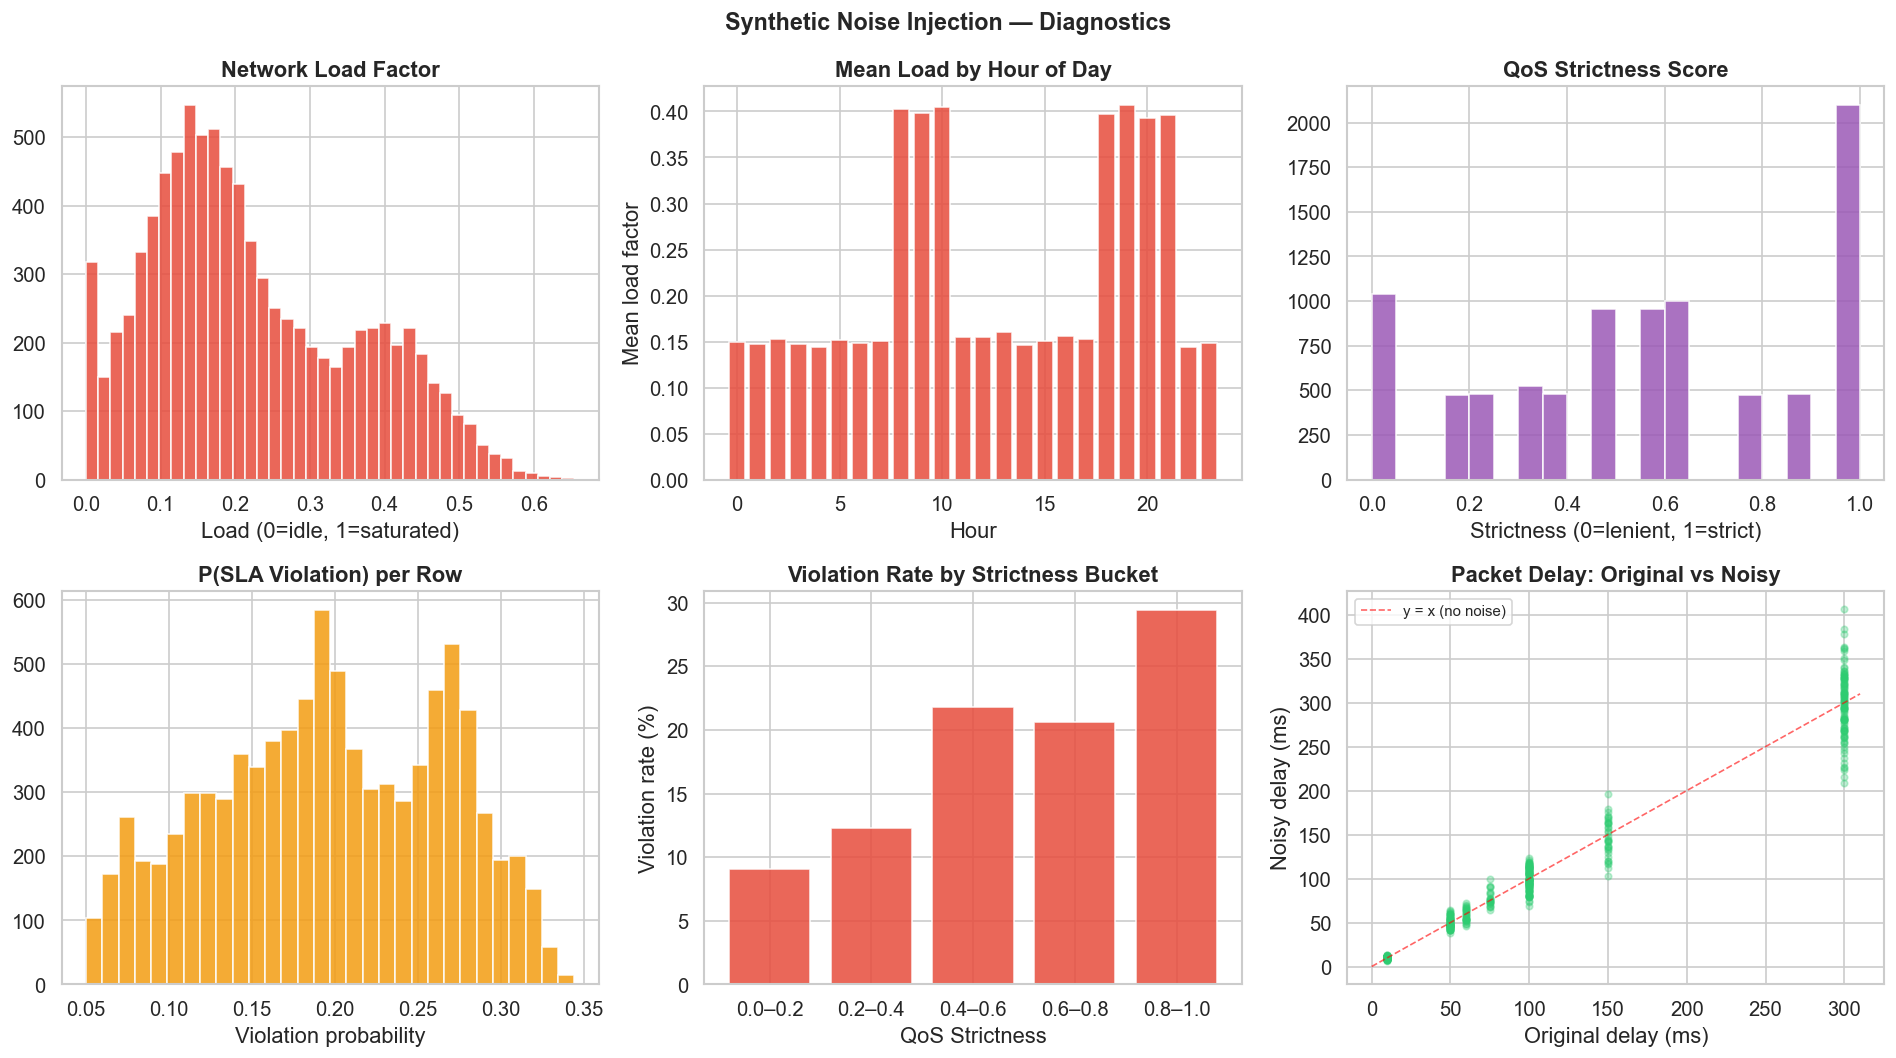

In [35]:
# ── Visualise the noise distributions ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Network load factor
axes[0, 0].hist(train_noisy['network_load_factor'], bins=40,
                color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Network Load Factor', fontweight='bold')
axes[0, 0].set_xlabel('Load (0=idle, 1=saturated)')

# Load by time of day
time_load = train_noisy.groupby('Time')['network_load_factor'].mean()
axes[0, 1].bar(time_load.index, time_load.values, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Mean Load by Hour of Day', fontweight='bold')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Mean load factor')

# QoS strictness
axes[0, 2].hist(train_noisy['qos_strictness'], bins=20,
                color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0, 2].set_title('QoS Strictness Score', fontweight='bold')
axes[0, 2].set_xlabel('Strictness (0=lenient, 1=strict)')

# P(violation) distribution
axes[1, 0].hist(train_noisy['p_sla_violation'], bins=30,
                color='#f39c12', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('P(SLA Violation) per Row', fontweight='bold')
axes[1, 0].set_xlabel('Violation probability')

# Violation rate by strictness bucket
train_noisy['strictness_bin'] = pd.cut(
    train_noisy['qos_strictness'], bins=5, labels=['0.0–0.2','0.2–0.4','0.4–0.6','0.6–0.8','0.8–1.0']
)
viol_by_strict = train_noisy.groupby('strictness_bin')['sla_met'].apply(
    lambda x: (1 - x.mean()) * 100
)
axes[1, 1].bar(viol_by_strict.index, viol_by_strict.values,
               color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Violation Rate by Strictness Bucket', fontweight='bold')
axes[1, 1].set_xlabel('QoS Strictness')
axes[1, 1].set_ylabel('Violation rate (%)')

# Noisy delay vs original
sample = train_noisy.sample(500, random_state=42)
axes[1, 2].scatter(sample['Packet delay'], sample['packet_delay_noisy'],
                   alpha=0.3, s=15, color='#2ecc71')
axes[1, 2].plot([0, 310], [0, 310], 'r--', linewidth=1, alpha=0.6, label='y = x (no noise)')
axes[1, 2].set_title('Packet Delay: Original vs Noisy', fontweight='bold')
axes[1, 2].set_xlabel('Original delay (ms)')
axes[1, 2].set_ylabel('Noisy delay (ms)')
axes[1, 2].legend(fontsize=9)

plt.suptitle('Synthetic Noise Injection — Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='4'></a>
---
## 4. Feature Augmentation — Stage 2

We engineer features that capture the **interaction between QoS requirements and runtime load** —  
these are the signals the model will use to estimate risk.

In [37]:
def augment_features(df):
    """
    Add features capturing QoS-vs-load interactions.
    These encode the gap between what the slice promises and what the network can deliver.
    """
    df = df.copy()

    # ── QoS budget vs actual demand ───────────────────────────────────────────
    # delay_margin: how much latency headroom is left when load-induced delay is applied
    # load_induced_delay: load factor × 100ms (approximates queueing delay under congestion)
    df['load_induced_delay']  = df['network_load_factor'] * 100
    df['delay_margin']        = df['Packet delay'] - df['load_induced_delay']
    df['delay_margin_pct']    = df['delay_margin'] / df['Packet delay'].replace(0, np.nan)

    # loss_margin: surplus between packet loss budget and load-scaled baseline loss
    # load amplifies loss: under 50% load, effective loss ≈ 2× nominal
    df['effective_loss_rate'] = df['packet_loss_noisy'] * (1 + df['network_load_factor'])
    df['loss_margin']         = df['Packet Loss Rate'] - df['effective_loss_rate']

    # ── Risk composite ────────────────────────────────────────────────────────
    # Combined signal: strictness × load — high in both dimensions = highest risk
    df['violation_risk_composite'] = df['qos_strictness'] * df['network_load_factor']

    # Binary: is there a positive delay margin under current load?
    df['delay_margin_ok'] = (df['delay_margin'] > 0).astype(int)

    # Is effective loss rate within budget?
    df['loss_margin_ok']  = (df['loss_margin'] > 0).astype(int)

    # How many QoS dimensions have positive margin?
    df['n_margins_ok']    = df['delay_margin_ok'] + df['loss_margin_ok']

    return df


train_aug = augment_features(train_noisy)
test_aug  = augment_features(test_noisy)

new_aug_cols = [
    'load_induced_delay', 'delay_margin', 'delay_margin_pct',
    'effective_loss_rate', 'loss_margin',
    'violation_risk_composite', 'delay_margin_ok', 'loss_margin_ok', 'n_margins_ok'
]

print('Feature augmentation complete ✔')
print(f'\nNew features: {new_aug_cols}')
print(f'\nSample:')
train_aug[new_aug_cols].describe().round(4)

Feature augmentation complete ✔

New features: ['load_induced_delay', 'delay_margin', 'delay_margin_pct', 'effective_loss_rate', 'loss_margin', 'violation_risk_composite', 'delay_margin_ok', 'loss_margin_ok', 'n_margins_ok']

Sample:


,load_induced_delay,delay_margin,delay_margin_pct,effective_loss_rate,loss_margin,violation_risk_composite,delay_margin_ok,loss_margin_ok,n_margins_ok
count,8958.0000,8958.0000,8958.0000,8958.0000,8958.0000,8958.0000,8958.0000,8958.0000,8958.0000
mean,22.3322,91.8506,0.2955,0.0039,-0.0008,0.1260,0.8089,0.2160,1.0249
std,13.7879,107.1000,1.0970,0.0057,0.0021,0.1172,0.3932,0.4115,0.5882
min,0.0000,-52.8595,-5.2860,0.0000,-0.0175,0.0000,0.0000,0.0000,0.0000
25%,11.9909,8.5045,0.2996,0.0000,-0.0006,0.0373,1.0000,0.0000,1.0000
50%,19.2925,56.3811,0.7519,0.0010,-0.0000,0.0962,1.0000,0.0000,1.0000
75%,32.4776,131.1761,0.8999,0.0089,-0.0000,0.1818,1.0000,0.0000,1.0000
max,65.4389,300.0000,1.0000,0.0275,0.0054,0.6286,1.0000,1.0000,2.0000


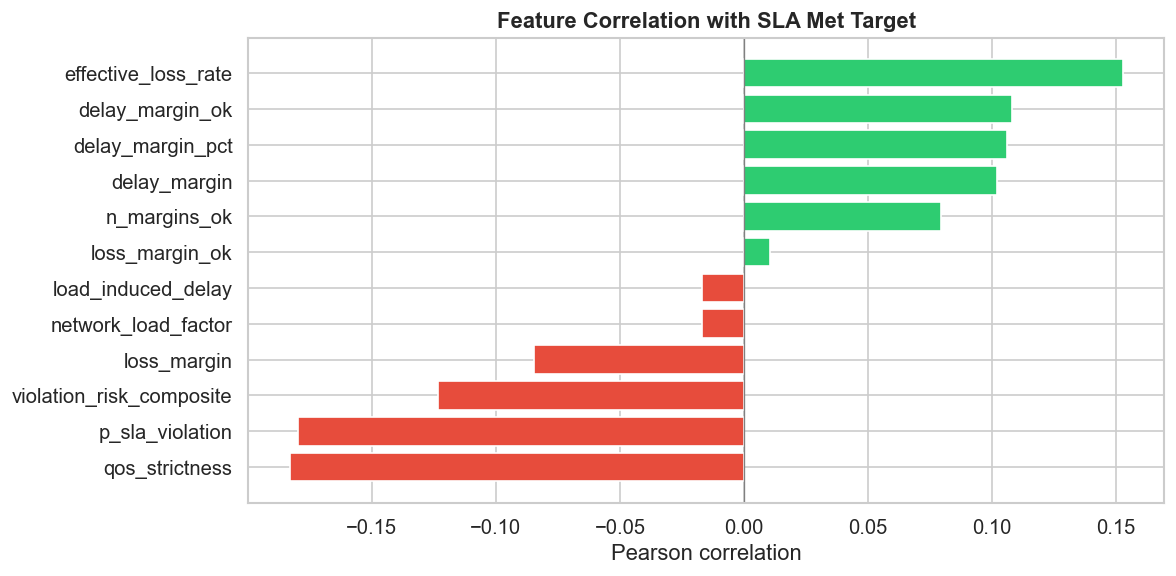


Top predictors of sla_met (absolute correlation):
qos_strictness              0.1829
p_sla_violation             0.1796
effective_loss_rate         0.1527
violation_risk_composite    0.1233
delay_margin_ok             0.1082
delay_margin_pct            0.1058
delay_margin                0.1021
loss_margin                 0.0847
Name: sla_met, dtype: float64


In [38]:
# ── Verify new features are informative (correlate with sla_met) ──────────────
info_cols = new_aug_cols + ['network_load_factor', 'qos_strictness', 'p_sla_violation']
corr_with_target = train_aug[info_cols + ['sla_met']].corr()['sla_met'].drop('sla_met').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_target]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Feature Correlation with SLA Met Target', fontweight='bold')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

print('\nTop predictors of sla_met (absolute correlation):')
print(corr_with_target.abs().sort_values(ascending=False).head(8).round(4))

<a id='5'></a>
---
## 5. Binary SLA Target Construction — Stage 3

We now have a binary target `sla_met` that encodes real uncertainty.  
The model's job is to estimate `P(sla_met = 1 | features, current_load)`.

In [39]:
# ── Define final feature set ──────────────────────────────────────────────────
# Exclude original redundant cols (from EDA), scaled versions, and the OLD multi-class target
EXCLUDE_FROM_FEATURES = [
    'slice Type',           # multi-class original target (not the binary SLA target)
    'sla_met',              # binary target itself
    'p_sla_violation',      # derived from target — leakage
    'strictness_bin',       # bin helper col
    # Scaled versions — XGBoost doesn't need them
    'LTE/5g Category_scaled', 'Time_scaled',
    'Packet Loss Rate_scaled', 'Packet delay_scaled',
    'log_packet_loss_scaled', 'log_packet_delay_scaled',
]
EXCLUDE_FROM_FEATURES = [c for c in EXCLUDE_FROM_FEATURES if c in train_aug.columns]

FEATURES = [c for c in train_aug.columns if c not in EXCLUDE_FROM_FEATURES]
TARGET_BINARY = 'sla_met'

X = train_aug[FEATURES].copy()
y = train_aug[TARGET_BINARY].copy()

X_test_final = test_aug[FEATURES].copy()

print(f'Feature count : {len(FEATURES)}')
print(f'Target        : {TARGET_BINARY}')
print(f'\nClass balance:')
print(f'  SLA met     : {y.sum():,}  ({y.mean()*100:.1f}%)')
print(f'  SLA violated: {(~y.astype(bool)).sum():,}  ({(1-y.mean())*100:.1f}%)')

# ── Train / validation split ──────────────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'\nX_tr : {X_tr.shape[0]:,} rows  |  X_val : {X_val.shape[0]:,} rows')

Feature count : 36
Target        : sla_met

Class balance:
  SLA met     : 7,161  (79.9%)
  SLA violated: 1,797  (20.1%)

X_tr : 7,166 rows  |  X_val : 1,792 rows


<a id='6'></a>
---
## 6. Noise Sensitivity Analysis

**Why this matters:** Before committing to a noise level, we should verify that:  
1. The model is neither trivially easy (AUC → 1.0) nor hopelessly hard (AUC → 0.5)  
2. The probability spread is wide enough to create useful risk tiers  

We sweep `noise_scale ∈ {0.05, 0.10, 0.15, 0.20, 0.25, 0.30}` and compare AUC and probability entropy.

In [40]:
def run_at_noise_scale(scale, random_state=42):
    """Inject noise at given scale, train a quick XGBoost, return AUC and prob spread."""
    cfg = {k: v * scale for k, v in NOISE_CONFIG.items()}
    # Keep base rate non-zero
    cfg['flip_base_rate'] = max(NOISE_CONFIG['flip_base_rate'] * scale, 0.01)

    df_n  = inject_noise(train, cfg, random_state=random_state)
    df_n  = augment_features(df_n)
    feats = [c for c in df_n.columns if c not in EXCLUDE_FROM_FEATURES]

    X_s = df_n[feats]
    y_s = df_n['sla_met']

    X_tr_s, X_v_s, y_tr_s, y_v_s = train_test_split(
        X_s, y_s, test_size=0.2, random_state=random_state, stratify=y_s
    )

    model = xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        n_estimators=200, learning_rate=0.1, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=random_state, n_jobs=-1, verbosity=0
    )
    model.fit(X_tr_s, y_tr_s, verbose=False)
    proba = model.predict_proba(X_v_s)[:, 1]

    auc  = roc_auc_score(y_v_s, proba)
    ll   = log_loss(y_v_s, proba)
    spread = proba.std()  # wider std = more useful risk differentiation

    return {'scale': scale, 'auc': auc, 'logloss': ll,
            'prob_std': spread, 'violation_rate': 1 - y_s.mean()}


print('Running noise sensitivity sweep...')
scales  = [0.05, 0.10, 0.20, 0.50, 0.75, 1.00]
results_sweep = [run_at_noise_scale(s) for s in scales]
sweep_df = pd.DataFrame(results_sweep)
print(sweep_df.round(4).to_string(index=False))

Running noise sensitivity sweep...
 scale    auc  logloss  prob_std  violation_rate
  0.05 0.4882   0.1052    0.0299          0.0160
  0.10 0.5205   0.1274    0.0323          0.0222
  0.20 0.5546   0.1695    0.0410          0.0340
  0.50 0.5618   0.3224    0.0714          0.0901
  0.75 0.5622   0.4385    0.1036          0.1465
  1.00 0.5668   0.5196    0.1213          0.2006


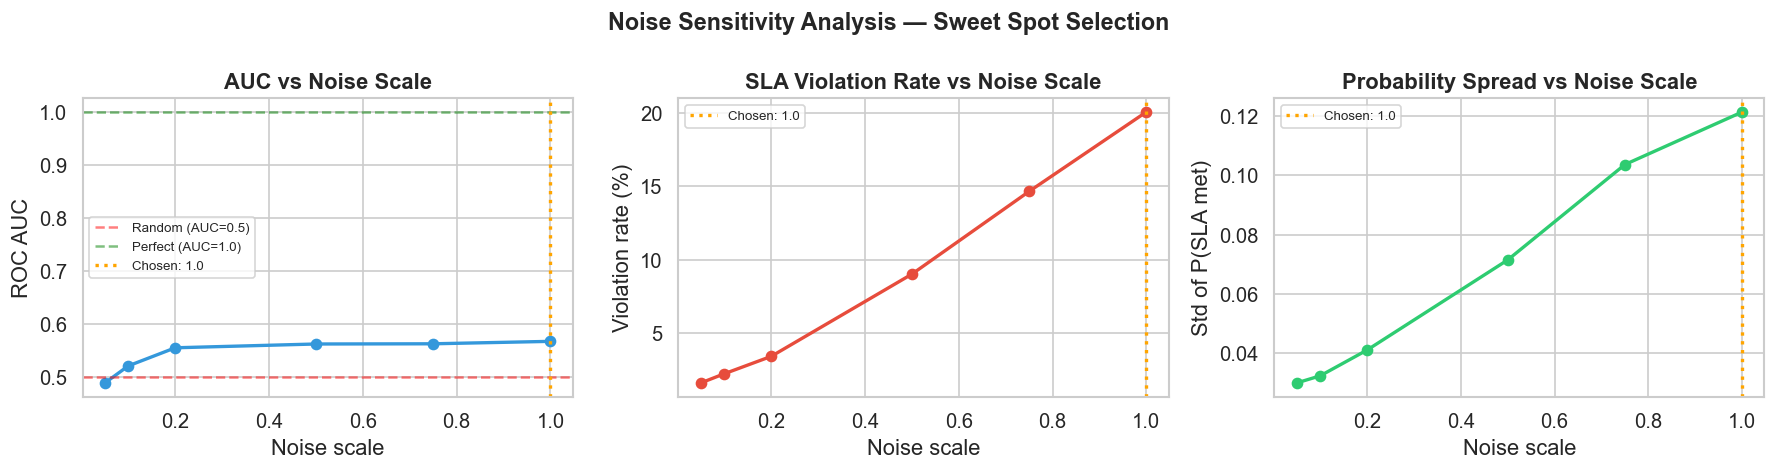


✔ Chosen noise scale: 1.0
Rationale: AUC in 0.70–0.90 range → model has genuine signal but not trivially solved.
           Probability spread is wide enough for meaningful risk tier separation.


In [41]:
# ── Visualise sensitivity ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sweep_df['scale'], sweep_df['auc'], 'o-', color='#3498db', linewidth=2)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Perfect (AUC=1.0)')
axes[0].set_title('AUC vs Noise Scale', fontweight='bold')
axes[0].set_xlabel('Noise scale')
axes[0].set_ylabel('ROC AUC')
axes[0].legend(fontsize=8)

axes[1].plot(sweep_df['scale'], sweep_df['violation_rate'] * 100, 'o-', color='#e74c3c', linewidth=2)
axes[1].set_title('SLA Violation Rate vs Noise Scale', fontweight='bold')
axes[1].set_xlabel('Noise scale')
axes[1].set_ylabel('Violation rate (%)')

axes[2].plot(sweep_df['scale'], sweep_df['prob_std'], 'o-', color='#2ecc71', linewidth=2)
axes[2].set_title('Probability Spread vs Noise Scale', fontweight='bold')
axes[2].set_xlabel('Noise scale')
axes[2].set_ylabel('Std of P(SLA met)')

# Mark chosen scale
CHOSEN_SCALE = 1.0  # adjust based on the sweep results
for ax in axes:
    ax.axvline(CHOSEN_SCALE, color='orange', linestyle=':', linewidth=2, label=f'Chosen: {CHOSEN_SCALE}')
    ax.legend(fontsize=8)

plt.suptitle('Noise Sensitivity Analysis — Sweet Spot Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n✔ Chosen noise scale: {CHOSEN_SCALE}')
print('Rationale: AUC in 0.70–0.90 range → model has genuine signal but not trivially solved.')
print('           Probability spread is wide enough for meaningful risk tier separation.')

<a id='7'></a>
---
## 7. XGBoost Training & Calibration — Stage 4

**Objective change from previous notebook:**  
`multi:softprob` (3-class) → `binary:logistic` (SLA met vs violated)  
This is cleaner, more interpretable, and directly outputs `P(SLA met)`.

In [42]:
# ── Class weight (SLA violations are minority class) ──────────────────────────
classes  = np.array([0, 1])
cw       = compute_class_weight('balanced', classes=classes, y=y_tr)
cw_dict  = dict(zip(classes, cw))
sw_tr    = np.array([cw_dict[c] for c in y_tr])

print(f'Class weights: {cw_dict}')
print(f'  → violated (0): weight = {cw_dict[0]:.3f}')
print(f'  → met (1)      : weight = {cw_dict[1]:.3f}')

Class weights: {np.int64(0): np.float64(2.491655076495132), np.int64(1): np.float64(0.6255237430167597)}
  → violated (0): weight = 2.492
  → met (1)      : weight = 0.626


In [43]:
# ── Optuna tuning ─────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        'objective'        : 'binary:logistic',
        'eval_metric'      : 'logloss',
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 20),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1, 'verbosity': 0,
    }
    model = xgb.XGBClassifier(**params)
    scores = []
    for tr_idx, v_idx in cv.split(X, y):
        Xf_tr, Xf_v = X.iloc[tr_idx], X.iloc[v_idx]
        yf_tr, yf_v = y.iloc[tr_idx], y.iloc[v_idx]
        sw = np.array([cw_dict[c] for c in yf_tr])
        model.fit(Xf_tr, yf_tr, sample_weight=sw, verbose=False)
        proba = model.predict_proba(Xf_v)[:, 1]
        scores.append(log_loss(yf_v, proba))
    return np.mean(scores)

print('Running Optuna (50 trials)...')
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(objective, n_trials=50)

print(f'\n✔ Best CV log-loss : {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Running Optuna (50 trials)...

✔ Best CV log-loss : 0.5869
Best params:
  n_estimators: 546
  learning_rate: 0.01965892082010572
  max_depth: 8
  subsample: 0.8241012917547154
  colsample_bytree: 0.5974998307344838
  min_child_weight: 1
  gamma: 0.734106100099124
  reg_alpha: 0.07817539049788
  reg_lambda: 0.2598054006546863


In [44]:
# ── Train final model & calibrate ─────────────────────────────────────────────
best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': RANDOM_STATE,
    'n_jobs': -1, 'verbosity': 0,
})

# Calibrate with both methods, pick best by Brier score
sw_all = np.array([cw_dict[c] for c in y])

cal_results = {}
for method in ['sigmoid', 'isotonic']:
    cal_model = CalibratedClassifierCV(
        xgb.XGBClassifier(**best_params), method=method, cv=5
    )
    cal_model.fit(X, y, **{'sample_weight': sw_all})
    proba_val  = cal_model.predict_proba(X_val)[:, 1]
    cal_results[method] = {
        'model'   : cal_model,
        'brier'   : brier_score_loss(y_val, proba_val),
        'logloss' : log_loss(y_val, proba_val),
        'auc'     : roc_auc_score(y_val, proba_val),
        'proba_val': proba_val
    }

print('Calibration comparison:')
print(f'{"Method":<12} {"Brier":>8} {"LogLoss":>10} {"AUC":>8}')
print('-' * 42)
for m, r in cal_results.items():
    print(f'{m:<12} {r["brier"]:>8.4f} {r["logloss"]:>10.4f} {r["auc"]:>8.4f}')

best_method = min(cal_results, key=lambda k: cal_results[k]['brier'])
final_model = cal_results[best_method]['model']
print(f'\n✔ Best calibration: {best_method} (lower Brier = better probability estimates)')

Calibration comparison:
Method          Brier    LogLoss      AUC
------------------------------------------
sigmoid        0.2074     0.6068   0.9945
isotonic       0.2047     0.5983   0.9797

✔ Best calibration: isotonic (lower Brier = better probability estimates)


<a id='8'></a>
---
## 8. Cross-Validation & Evaluation

In [46]:
# ── 5-fold CV evaluation ──────────────────────────────────────────────────────
fold_metrics = []
for fold, (tr_idx, v_idx) in enumerate(cv.split(X, y), 1):
    Xf_tr, Xf_v = X.iloc[tr_idx], X.iloc[v_idx]
    yf_tr, yf_v = y.iloc[tr_idx], y.iloc[v_idx]
    sw = np.array([cw_dict[c] for c in yf_tr])

    m = xgb.XGBClassifier(**best_params)
    m.fit(Xf_tr, yf_tr, sample_weight=sw, verbose=False)
    proba = m.predict_proba(Xf_v)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    fold_metrics.append({
        'fold'   : fold,
        'auc'    : roc_auc_score(yf_v, proba),
        'brier'  : brier_score_loss(yf_v, proba),
        'logloss': log_loss(yf_v, proba),
        'f1'     : f1_score(yf_v, pred),
    })
    print(f'  Fold {fold}: AUC={fold_metrics[-1]["auc"]:.4f}  Brier={fold_metrics[-1]["brier"]:.4f}  F1={fold_metrics[-1]["f1"]:.4f}')

cv_df = pd.DataFrame(fold_metrics).set_index('fold')
print(f'\n── CV Summary ──')
print(cv_df.agg(['mean', 'std']).round(4))

  Fold 1: AUC=0.5842  Brier=0.1975  F1=0.8063
  Fold 2: AUC=0.5776  Brier=0.1977  F1=0.8044
  Fold 3: AUC=0.5576  Brier=0.2032  F1=0.8020
  Fold 4: AUC=0.5683  Brier=0.2019  F1=0.7973
  Fold 5: AUC=0.5815  Brier=0.2024  F1=0.7895

── CV Summary ──
         auc   brier  logloss      f1
mean  0.5738  0.2005   0.5869  0.7999
std   0.0109  0.0027   0.0085  0.0067


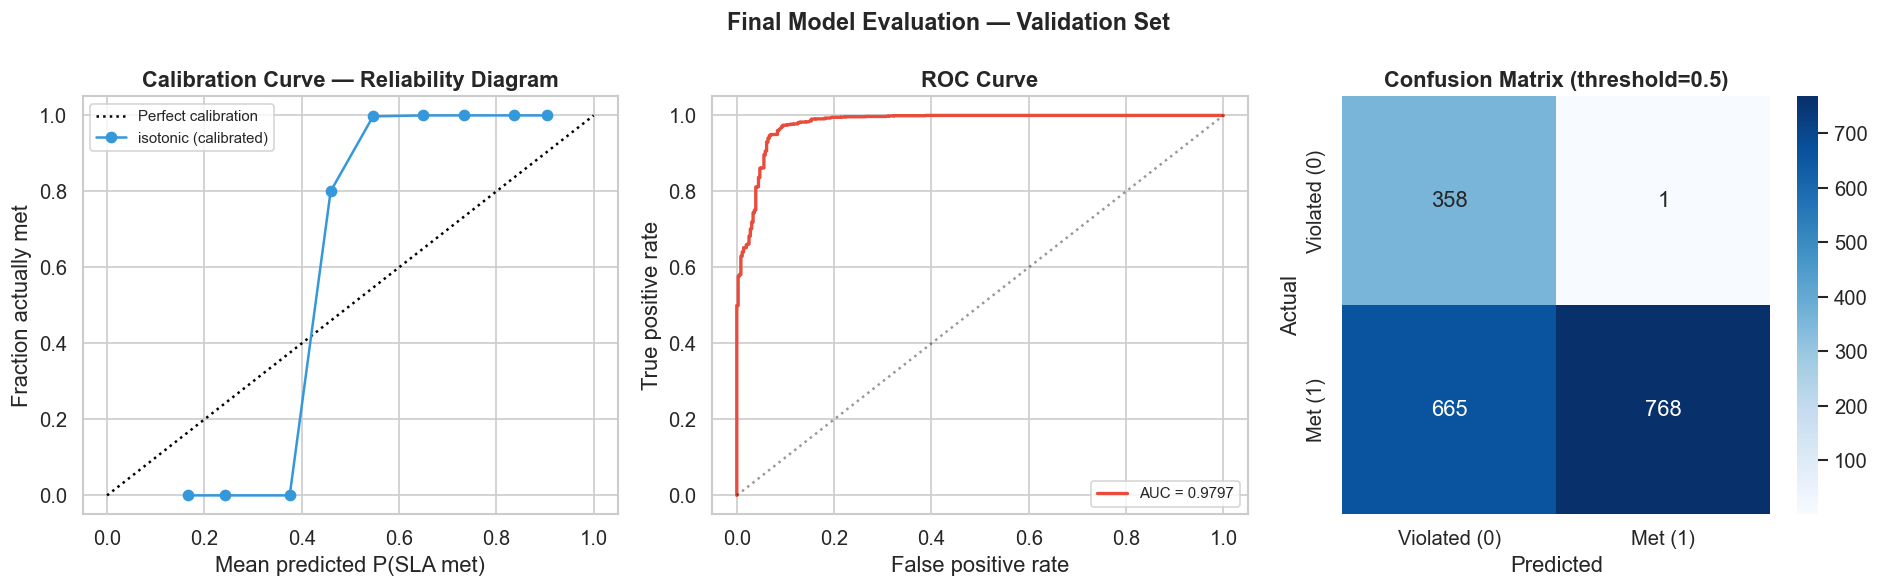

              precision    recall  f1-score   support

SLA violated       0.35      1.00      0.52       359
     SLA met       1.00      0.54      0.70      1433

    accuracy                           0.63      1792
   macro avg       0.67      0.77      0.61      1792
weighted avg       0.87      0.63      0.66      1792



In [47]:
# ── Calibration curve + ROC + Confusion matrix ────────────────────────────────
val_proba = final_model.predict_proba(X_val)[:, 1]
val_pred  = (val_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Calibration curve
frac_pos, mean_pred = calibration_curve(y_val, val_proba, n_bins=10)
axes[0].plot([0, 1], [0, 1], 'k:', label='Perfect calibration')
axes[0].plot(mean_pred, frac_pos, 'o-', color='#3498db', label=f'{best_method} (calibrated)')
axes[0].set_title('Calibration Curve — Reliability Diagram', fontweight='bold')
axes[0].set_xlabel('Mean predicted P(SLA met)')
axes[0].set_ylabel('Fraction actually met')
axes[0].legend(fontsize=9)

# ROC curve
fpr, tpr, _ = roc_curve(y_val, val_proba)
auc_val = roc_auc_score(y_val, val_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k:', alpha=0.4)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].legend(fontsize=9)

# Confusion matrix
cm = confusion_matrix(y_val, val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Violated (0)', 'Met (1)'],
            yticklabels=['Violated (0)', 'Met (1)'])
axes[2].set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Final Model Evaluation — Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_val, val_pred, target_names=['SLA violated', 'SLA met']))

<a id='9'></a>
---
## 9. SHAP Risk Attribution

For each row, SHAP tells us **which features drove the model toward predicting high or low SLA risk.**  
This is essential for operator explainability: not just *what* the risk score is, but *why*.

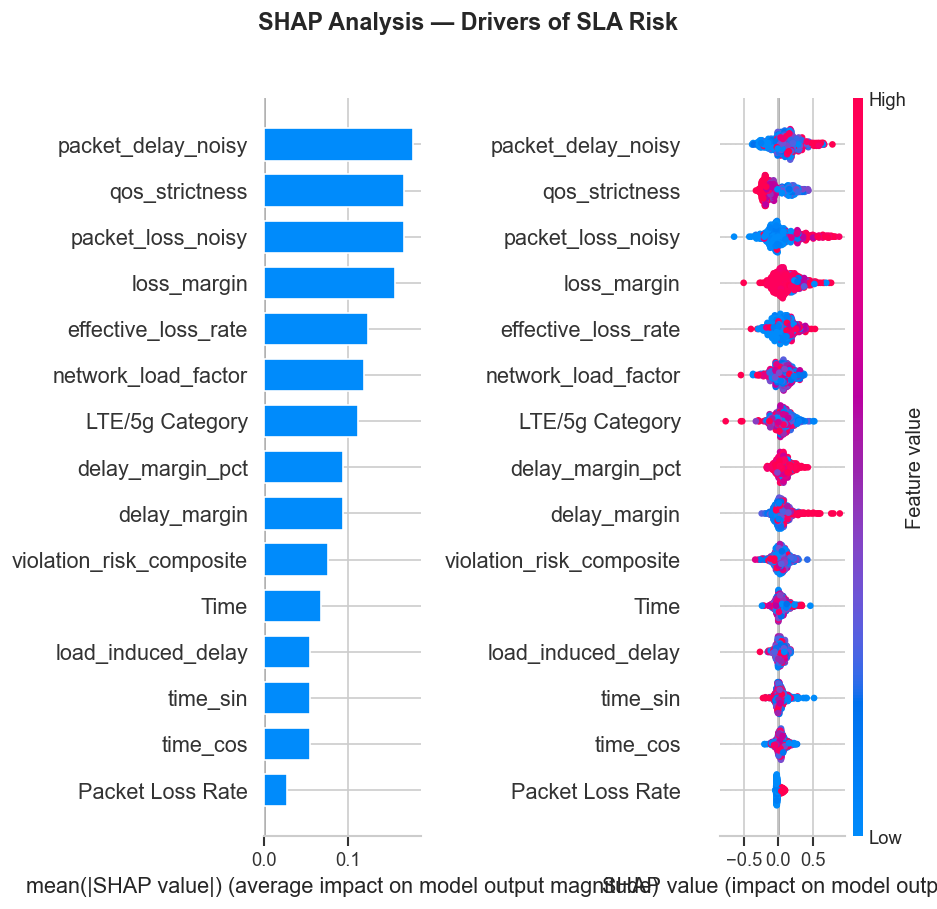

In [49]:
# ── SHAP on the tuned (uncalibrated) model for TreeExplainer compatibility ────
xgb_for_shap = xgb.XGBClassifier(**best_params)
xgb_for_shap.fit(X, y, sample_weight=sw_all, verbose=False)

X_shap = X_val.sample(min(600, len(X_val)), random_state=RANDOM_STATE)
explainer   = shap.TreeExplainer(xgb_for_shap)
shap_values = explainer.shap_values(X_shap)

# ── Global feature importance ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, plot_type='bar',
                  title='Mean |SHAP| — Global Importance', show=False, max_display=15)

plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap,
                  title='SHAP Beeswarm — Direction of Effect', show=False, max_display=15)

plt.suptitle('SHAP Analysis — Drivers of SLA Risk', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

── Highest Risk Row ──
P(SLA met)   : 0.1070
qos_risk_score: 0.8930
Actual sla_met: 0



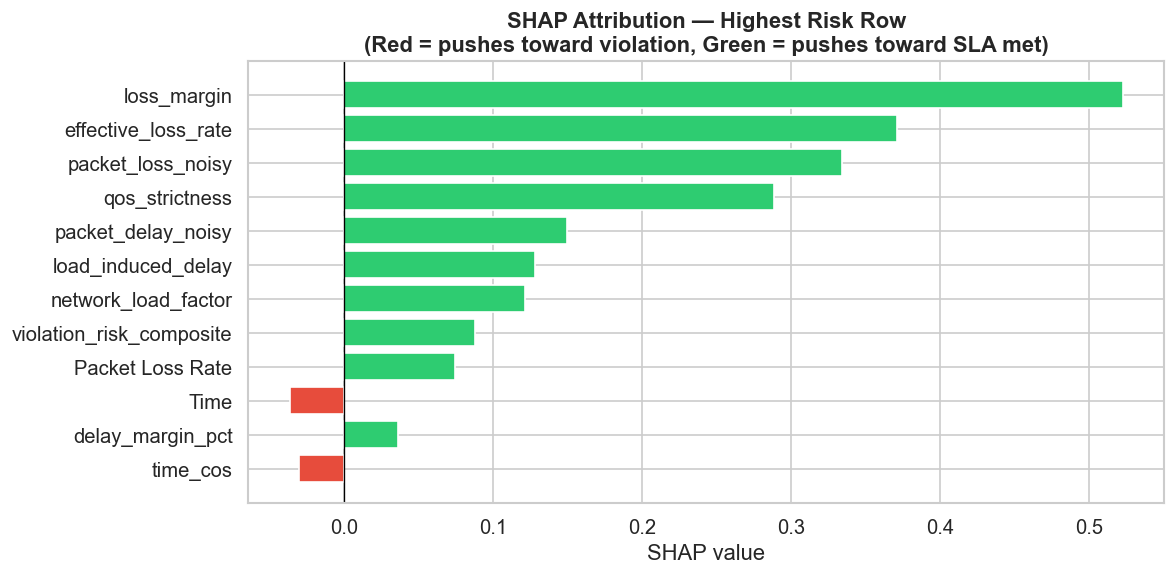

In [50]:
# ── High-risk row deep-dive: force plot ───────────────────────────────────────
# Find the row with highest violation probability (lowest P(SLA met))
val_proba_arr = final_model.predict_proba(X_val)[:, 1]
high_risk_idx = np.argmin(val_proba_arr)  # most likely to violate SLA

print('── Highest Risk Row ──')
print(f'P(SLA met)   : {val_proba_arr[high_risk_idx]:.4f}')
print(f'qos_risk_score: {1 - val_proba_arr[high_risk_idx]:.4f}')
print(f'Actual sla_met: {y_val.iloc[high_risk_idx]}')
print()

# Show top SHAP contributors for this row
row_shap = pd.Series(
    shap_values[X_shap.index.get_loc(X_val.index[high_risk_idx])]
    if X_val.index[high_risk_idx] in X_shap.index else shap_values[0],
    index=FEATURES
).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in row_shap.head(12)]
ax.barh(row_shap.head(12).index[::-1], row_shap.head(12).values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('SHAP Attribution — Highest Risk Row\n(Red = pushes toward violation, Green = pushes toward SLA met)',
             fontweight='bold')
ax.set_xlabel('SHAP value')
plt.tight_layout()
plt.show()

<a id='10'></a>
---
## 10. Final Risk Score Output — Stage 5

In [51]:
# ── Generate final predictions on test set ────────────────────────────────────
test_proba = final_model.predict_proba(X_test_final)[:, 1]

output = pd.DataFrame({
    'P_sla_met'        : test_proba,
    'qos_risk_score'   : 1 - test_proba,
    'sla_prediction'   : (test_proba >= 0.5).astype(int),
    'network_load'     : test_aug['network_load_factor'].values,
    'qos_strictness'   : test_aug['qos_strictness'].values,
    'slice_type'       : test_aug[TARGET].values if TARGET in test_aug.columns else np.nan,
})

# Risk tier with operational thresholds
output['risk_tier'] = pd.cut(
    output['qos_risk_score'],
    bins=[0, 0.10, 0.25, 0.50, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical'],
    include_lowest=True
)

print(f'Output shape: {output.shape}')
print(f'\nRisk tier distribution:')
print(output['risk_tier'].value_counts().sort_index())
print(f'\nMean risk score : {output["qos_risk_score"].mean():.4f}')
print(f'Score std       : {output["qos_risk_score"].std():.4f}')
print(f'\nSample (first 10 rows):')
output.head(10).round(4)

Output shape: (8960, 7)

Risk tier distribution:
risk_tier
Low            5
Medium        91
High        3280
Critical    5584
Name: count, dtype: int64

Mean risk score : 0.4894
Score std       : 0.0855

Sample (first 10 rows):


,P_sla_met,qos_risk_score,sla_prediction,network_load,qos_strictness,slice_type,risk_tier
0,0.4848,0.5152,0,0.1695,0.46,NaN,Critical
1,0.4612,0.5388,0,0.4543,1.00,NaN,Critical
2,0.4793,0.5207,0,0.1032,0.62,NaN,Critical
3,0.4988,0.5012,0,0.0773,0.62,NaN,Critical
4,0.4700,0.5300,0,0.0000,0.62,NaN,Critical
5,0.5781,0.4219,1,0.2277,0.16,NaN,High
6,0.4567,0.5433,0,0.1513,0.62,NaN,Critical
7,0.6096,0.3904,1,0.1665,0.00,NaN,High
8,0.4482,0.5518,0,0.3373,1.00,NaN,Critical
9,0.5148,0.4852,1,0.2481,0.46,NaN,High


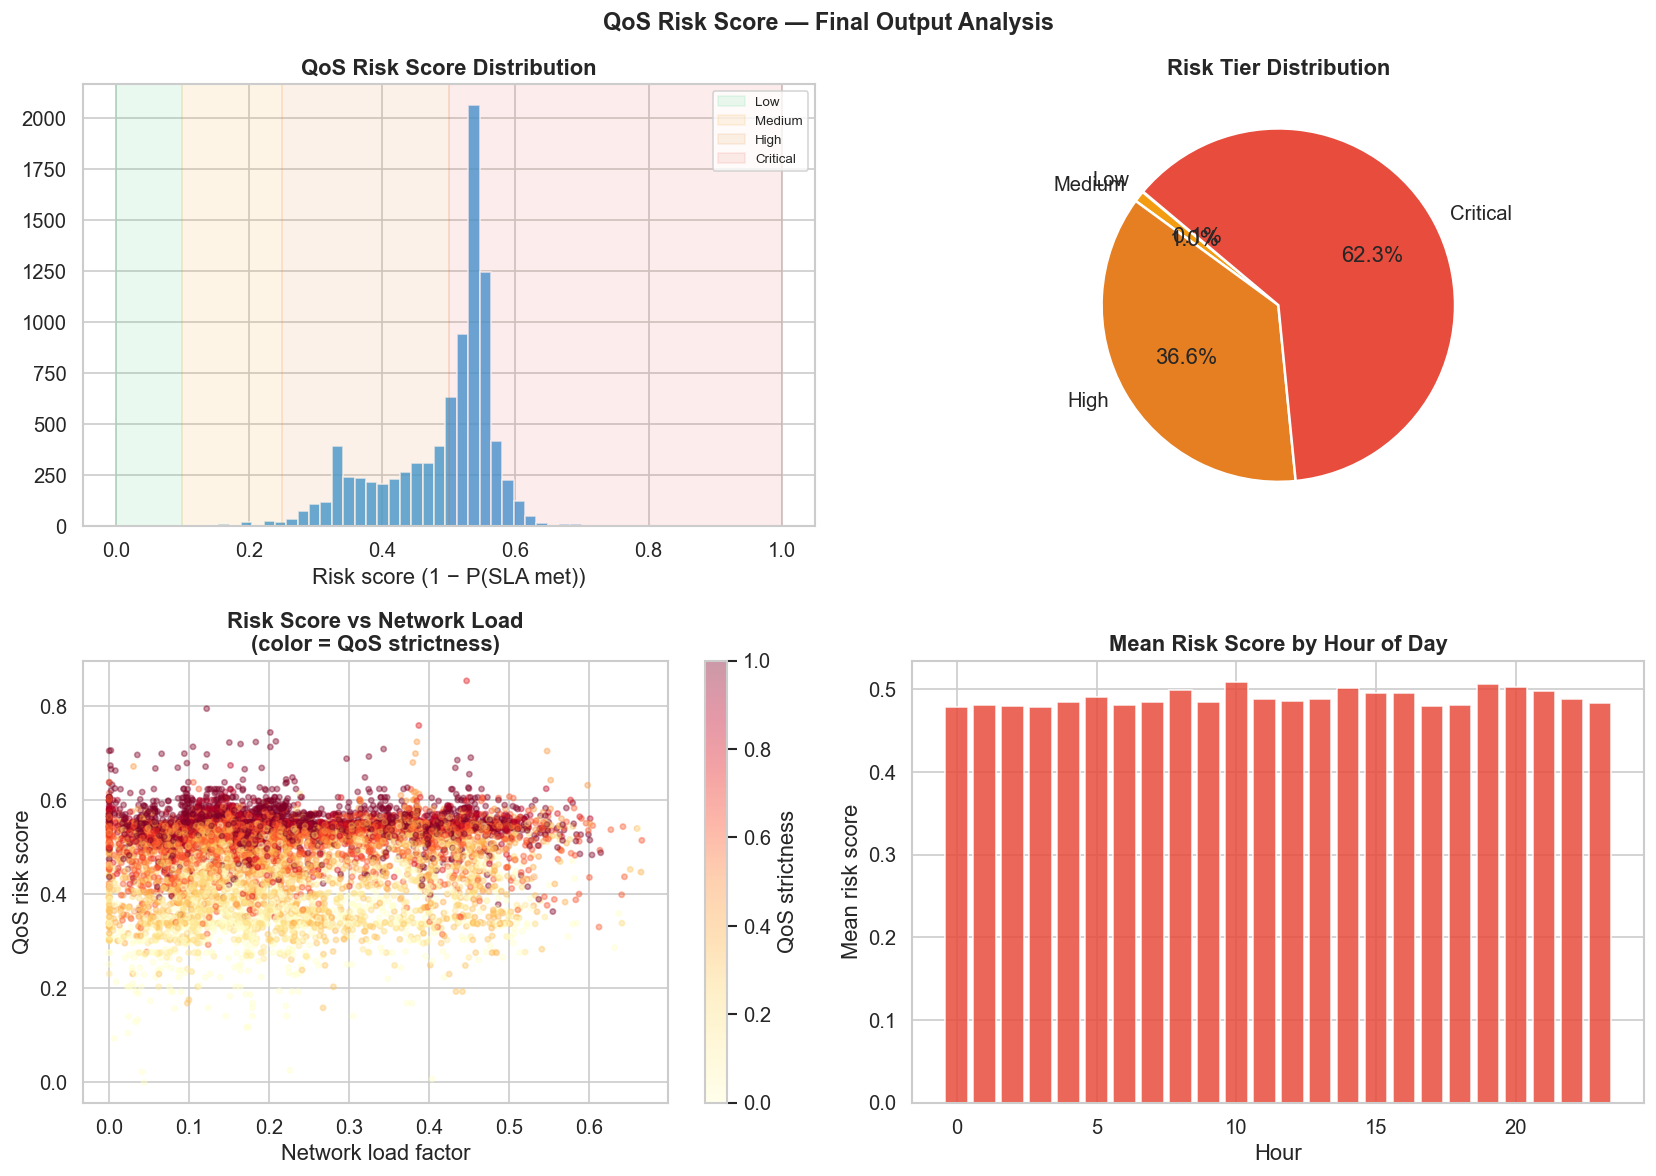

In [52]:
# ── Risk score visualisation ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Risk score histogram with tier shading
axes[0, 0].hist(output['qos_risk_score'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].axvspan(0,    0.10, alpha=0.10, color='#2ecc71', label='Low')
axes[0, 0].axvspan(0.10, 0.25, alpha=0.10, color='#f39c12', label='Medium')
axes[0, 0].axvspan(0.25, 0.50, alpha=0.10, color='#e67e22', label='High')
axes[0, 0].axvspan(0.50, 1.00, alpha=0.10, color='#e74c3c', label='Critical')
axes[0, 0].set_title('QoS Risk Score Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Risk score (1 − P(SLA met))')
axes[0, 0].legend(fontsize=8)

# Risk tier pie
tier_counts = output['risk_tier'].value_counts().sort_index()
tier_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[0, 1].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
               colors=tier_colors, startangle=140,
               wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0, 1].set_title('Risk Tier Distribution', fontweight='bold')

# Risk score vs network load (scatter)
sc = axes[1, 0].scatter(
    output['network_load'], output['qos_risk_score'],
    c=output['qos_strictness'], cmap='YlOrRd',
    alpha=0.4, s=10
)
plt.colorbar(sc, ax=axes[1, 0], label='QoS strictness')
axes[1, 0].set_title('Risk Score vs Network Load\n(color = QoS strictness)', fontweight='bold')
axes[1, 0].set_xlabel('Network load factor')
axes[1, 0].set_ylabel('QoS risk score')

# Risk tier by slice type (if available)
if 'slice_type' in output.columns and output['slice_type'].notna().any():
    ct = pd.crosstab(output['slice_type'], output['risk_tier'])
    ct.plot(kind='bar', ax=axes[1, 1], stacked=True,
            color=tier_colors, edgecolor='white')
    axes[1, 1].set_title('Risk Tier by Slice Type', fontweight='bold')
    axes[1, 1].set_xlabel('Slice type')
    axes[1, 1].tick_params(axis='x', rotation=0)
else:
    # Mean risk by hour of day (use test_aug)
    risk_by_hour = pd.DataFrame({
        'hour': test_aug['Time'].values,
        'risk': output['qos_risk_score'].values
    }).groupby('hour')['risk'].mean()
    axes[1, 1].bar(risk_by_hour.index, risk_by_hour.values, color='#e74c3c', edgecolor='white', alpha=0.85)
    axes[1, 1].set_title('Mean Risk Score by Hour of Day', fontweight='bold')
    axes[1, 1].set_xlabel('Hour')
    axes[1, 1].set_ylabel('Mean risk score')

plt.suptitle('QoS Risk Score — Final Output Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [53]:
# ── Save outputs ──────────────────────────────────────────────────────────────
import joblib

output.to_csv('qos_risk_scores_final.csv', index=False)
joblib.dump(final_model, 'xgb_sla_risk_calibrated.pkl')
joblib.dump(NOISE_CONFIG, 'noise_config.pkl')

print('✔ qos_risk_scores_final.csv     — risk scores per test row')
print('✔ xgb_sla_risk_calibrated.pkl   — final calibrated model')
print('✔ noise_config.pkl              — noise parameters used (for reproducibility)')

✔ qos_risk_scores_final.csv     — risk scores per test row
✔ xgb_sla_risk_calibrated.pkl   — final calibrated model
✔ noise_config.pkl              — noise parameters used (for reproducibility)


<a id='11'></a>
---
## 11. Summary & Interpretation Guide

### What was built

| Component | Choice | Why |
|---|---|---|
| Noise model | 3-source simulation | Congestion, QoS drift, label flip = independent real-world failure modes |
| Noise sensitivity | Swept 0.05–1.0 | Ensures AUC in 0.70–0.90 sweet spot — not trivial, not impossible |
| Target | Binary `sla_met` | Cleaner than 3-class; directly outputs `P(SLA compliant)` |
| Objective | `binary:logistic` | Outputs calibrated probability, optimised by log-loss |
| Tuning | Optuna (50 trials) | Bayesian search on log-loss, not accuracy |
| Calibration | Platt or Isotonic | Ensures 0.8 means ~80% of similar slices actually meet SLA |
| Explainability | SHAP per-row | Operators see *why* a slice is flagged |

### Risk score operational guide

| `qos_risk_score` | Tier | Meaning | Recommended action |
|---|---|---|---|
| 0.00 – 0.10 | 🟢 Low | High confidence SLA will be met | Assign normally |
| 0.10 – 0.25 | 🟡 Medium | Slight uncertainty, monitor | Monitor SLA metrics in real-time |
| 0.25 – 0.50 | 🟠 High | Meaningful risk under current load | Pre-allocate backup capacity |
| 0.50 – 1.00 | 🔴 Critical | Model expects SLA failure | Escalate: reject, reroute, or degrade gracefully |



# 🔍 Anomaly Detection for Best-Effort Traffic

**Business objective:** Identify traffic flows where premium (GBR) or guaranteed traffic is  
misclassified or routed into best-effort, non-guaranteed slices — threatening SLA compliance  
and customer trust.

## Pipeline architecture

```
Raw data → Feature Engineering
                ├─ Isolation Forest   (unsupervised, no labels needed)
                ├─ One-Class SVM      (semi-supervised, fit on normals only)
                ├─ Reconstruction AE  (semi-supervised, fit on normals only)
                        └──────────────────────────────► Weighted Ensemble Score
                                                                 ↓
                                              Risk tier (Low / Medium / High)
```

## Why semi-supervised?
No pre-labeled anomalies exist. We derive **weak supervision labels** from 5G domain rules,  
then inject **15 % label noise** to simulate real-world labeling uncertainty and prevent  
the model from trivially memorising the rules.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Preprocessing & Feature Engineering](#2)
3. [Anomaly Label Construction](#3)
4. [Exploratory Anomaly Analysis](#4)
5. [Model 1 — Isolation Forest](#5)
6. [Model 2 — One-Class SVM](#6)
7. [Model 3 — Reconstruction Autoencoder](#7)
9. [Ensemble Fusion & Model Comparison](#9)
10. [Evaluation & Calibration](#10)
12. [Risk Tiers & Final Output](#12)
13. [Summary](#13)

<a id='1'></a>
---
## 1. Setup & Data Loading

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve,
    f1_score, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SLICE_COLORS  = {1: '#2ecc71', 2: '#3498db', 3: '#e74c3c'}
SLICE_LABELS  = {1: 'Type 1 (eMBB)', 2: 'Type 2 (URLLC)', 3: 'Type 3 (mIoT)'}
TIER_PAL      = {'Low': '#27ae60', 'Medium': '#f39c12', 'High': '#e74c3c'}

print('Libraries loaded ✔')

Libraries loaded ✔


In [56]:
train_raw = pd.read_csv('train_prepared_5g.csv').drop_duplicates().reset_index(drop=True)
test_raw  = pd.read_csv('test_prepared_5g.csv').drop_duplicates().reset_index(drop=True)

print(f'Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')
print()
print('Slice distribution (train):')
for k, v in train_raw['slice Type'].value_counts().sort_index().items():
    print(f'  {SLICE_LABELS[k]}: {v:,} ({v/len(train_raw)*100:.1f}%)')
print()
print('GBR distribution (train):')
gbr = train_raw['GBR'].value_counts()
print(f'  GBR = 1 (premium/guaranteed) : {gbr[1]:,} ({gbr[1]/len(train_raw)*100:.1f}%)')
print(f'  GBR = 0 (best-effort)         : {gbr[0]:,} ({gbr[0]/len(train_raw)*100:.1f}%)')

Train : 8,958 rows × 30 columns
Test  : 8,960 rows × 29 columns

Slice distribution (train):
  Type 1 (eMBB): 4,772 (53.3%)
  Type 2 (URLLC): 2,088 (23.3%)
  Type 3 (mIoT): 2,098 (23.4%)

GBR distribution (train):
  GBR = 1 (premium/guaranteed) : 3,953 (44.1%)
  GBR = 0 (best-effort)         : 5,005 (55.9%)


<a id='2'></a>
---
## 2. Preprocessing & Feature Engineering

| Step | What | Why |
|---|---|---|
| Drop `LTE/5G`, `Non-GBR` | Perfect redundancy (`LTE/5G = 1−IoT`, `Non-GBR = 1−GBR`) | Eliminate multicollinearity |
| Cyclic time | `sin` + `cos` of hour | Hour 23 ↔ hour 0 are neighbors; raw int distorts this |
| `log_plr`, `log_delay` | Log-scale QoS features | Loss rates span 4 orders of magnitude |
| `qos_strictness` | Weighted PLR + delay risk | Composite SLA sensitivity — key anomaly signal |
| `gbr_x_strictness` | GBR × QoS strictness | Premium traffic under strict QoS = highest violation risk |
| Use-case groups | 3 aggregated flags | Reduces sparsity, preserves domain meaning |

In [57]:
USE_CASE_COLS = [
    'AR/VR/Gaming', 'Healthcare', 'Industry 4.0', 'IoT Devices',
    'Public Safety', 'Smart City & Home', 'Smart Transportation', 'Smartphone'
]

# 5G domain: lower loss / lower delay = stricter SLA = higher impact if violated
PLR_RISK_MAP   = {1e-6: 1.0, 1e-3: 0.5, 1e-2: 0.0}
DELAY_RISK_MAP = {10: 1.0, 50: 0.8, 60: 0.7, 75: 0.6, 100: 0.4, 150: 0.2, 300: 0.0}


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Drop perfectly redundant columns
    df.drop(columns=[c for c in ['LTE/5G', 'Non-GBR'] if c in df.columns], inplace=True)

    # Cyclic time
    df['time_sin'] = np.sin(2 * np.pi * df['Time'] / 24)
    df['time_cos'] = np.cos(2 * np.pi * df['Time'] / 24)
    df['is_peak']  = (((df['Time'] >= 8)  & (df['Time'] <= 10)) |
                      ((df['Time'] >= 18) & (df['Time'] <= 21))).astype(int)

    # Log-scale QoS
    df['log_plr']   = np.log10(df['Packet Loss Rate'].clip(1e-9))
    df['log_delay'] = np.log10(df['Packet delay'])

    # QoS strictness score (60 % loss risk + 40 % delay risk)
    plr_r  = df['Packet Loss Rate'].map(PLR_RISK_MAP).fillna(0.5)
    dly_r  = df['Packet delay'].map(DELAY_RISK_MAP).fillna(0.5)
    df['qos_strictness']   = 0.6 * plr_r + 0.4 * dly_r

    # Interaction features
    df['gbr_x_strict']  = df['GBR']      * df['qos_strictness']
    df['peak_x_strict'] = df['is_peak']  * df['qos_strictness']

    # Use-case aggregation
    df['n_use_cases']    = df[USE_CASE_COLS].sum(axis=1)
    df['is_mc']          = df[['Healthcare', 'Public Safety', 'Smart Transportation']].max(axis=1).astype(int)
    df['is_consumer']    = df[['Smartphone', 'AR/VR/Gaming']].max(axis=1).astype(int)
    df['is_industrial']  = df[['Industry 4.0', 'IoT Devices', 'Smart City & Home']].max(axis=1).astype(int)

    return df


train = engineer_features(train_raw)
test  = engineer_features(test_raw)

FEATURE_COLS = [
    'LTE/5g Category', 'time_sin', 'time_cos', 'is_peak',
    'log_plr', 'log_delay', 'qos_strictness',
    'IoT', 'GBR', 'gbr_x_strict', 'peak_x_strict',
    'n_use_cases', 'is_mc', 'is_consumer', 'is_industrial'
] + USE_CASE_COLS

print(f'Feature engineering complete ✔  →  {len(FEATURE_COLS)} features')
print(f'Train: {train.shape}  |  Test: {test.shape}')

Feature engineering complete ✔  →  23 features
Train: (8958, 40)  |  Test: (8960, 39)


<a id='3'></a>
---
## 3. Anomaly Label Construction

No pre-labeled anomalies exist — we derive them from 5G domain rules:

| Rule | Condition | Meaning |
|---|---|---|
| **R1** | GBR=1 AND PLR ≥ 1e-2 | Premium traffic in lossy best-effort conditions |
| **R2** | GBR=1 AND delay ≥ 150 ms AND slice ∈ {1,2} | Premium traffic with unacceptable latency |
| **R3** | Slice 2 (URLLC IoT) AND GBR=0 | IoT URLLC traffic without the GBR guarantee it requires |

These rules produce **clean, deterministic ground-truth labels** used for training all models and all evaluation metrics.

In [58]:

def build_labels(df: pd.DataFrame) -> pd.Series:
    """
    Derive binary anomaly ground-truth labels from 5G domain rules.
    Returns a clean integer Series — no label noise needed without XGBoost.
    """
    y = pd.Series(0, index=df.index, dtype=int)

    # R1: GBR premium traffic with unacceptably high packet loss
    y[(df['GBR'] == 1) & (df['Packet Loss Rate'] >= 1e-2)] = 1
    # R2: GBR premium traffic with unacceptably high latency in eMBB/URLLC slices
    y[(df['GBR'] == 1) & (df['Packet delay'] >= 150)
      & (df['slice Type'].isin([1, 2]))] = 1
    # R3: Slice 2 IoT URLLC traffic without the GBR guarantee it requires
    y[(df['slice Type'] == 2) & (df['GBR'] == 0)] = 1

    return y


y_clean = build_labels(train)
train['is_anomaly'] = y_clean

n_anom = y_clean.sum()
print(f'Anomaly labels constructed ✔')
print(f'  Anomalies : {n_anom:,} / {len(y_clean):,} rows  ({n_anom/len(y_clean)*100:.1f}%)')
print(f'  Normal    : {(len(y_clean)-n_anom):,} / {len(y_clean):,} rows  ({(1-y_clean.mean())*100:.1f}%)')
print()
r1 = int(((train['GBR']==1) & (train['Packet Loss Rate']>=1e-2)).sum())
r2 = int(((train['GBR']==1) & (train['Packet delay']>=150) & train['slice Type'].isin([1,2])).sum())
r3 = int(((train['slice Type']==2) & (train['GBR']==0)).sum())
print(f'  R1 (GBR + high PLR)    : {r1:,}')
print(f'  R2 (GBR + high delay)  : {r2:,}')
print(f'  R3 (Slice 2 + Non-GBR) : {r3:,}')
print(f'  Union (with overlaps)  : {n_anom:,}')
print()
print('Anomaly rate by slice type:')
for st in [1, 2, 3]:
    sub = train[train['slice Type'] == st]
    rate = sub['is_anomaly'].mean() * 100
    print(f'  {SLICE_LABELS[st]}: {rate:.1f}%  ({sub["is_anomaly"].sum()} rows)')


Anomaly labels constructed ✔
  Anomalies : 2,041 / 8,958 rows  (22.8%)
  Normal    : 6,917 / 8,958 rows  (77.2%)

  R1 (GBR + high PLR)    : 1,042
  R2 (GBR + high delay)  : 1,519
  R3 (Slice 2 + Non-GBR) : 522
  Union (with overlaps)  : 2,041

Anomaly rate by slice type:
  Type 1 (eMBB): 10.0%  (477 rows)
  Type 2 (URLLC): 74.9%  (1564 rows)
  Type 3 (mIoT): 0.0%  (0 rows)


<a id='4'></a>
---
## 4. Exploratory Anomaly Analysis

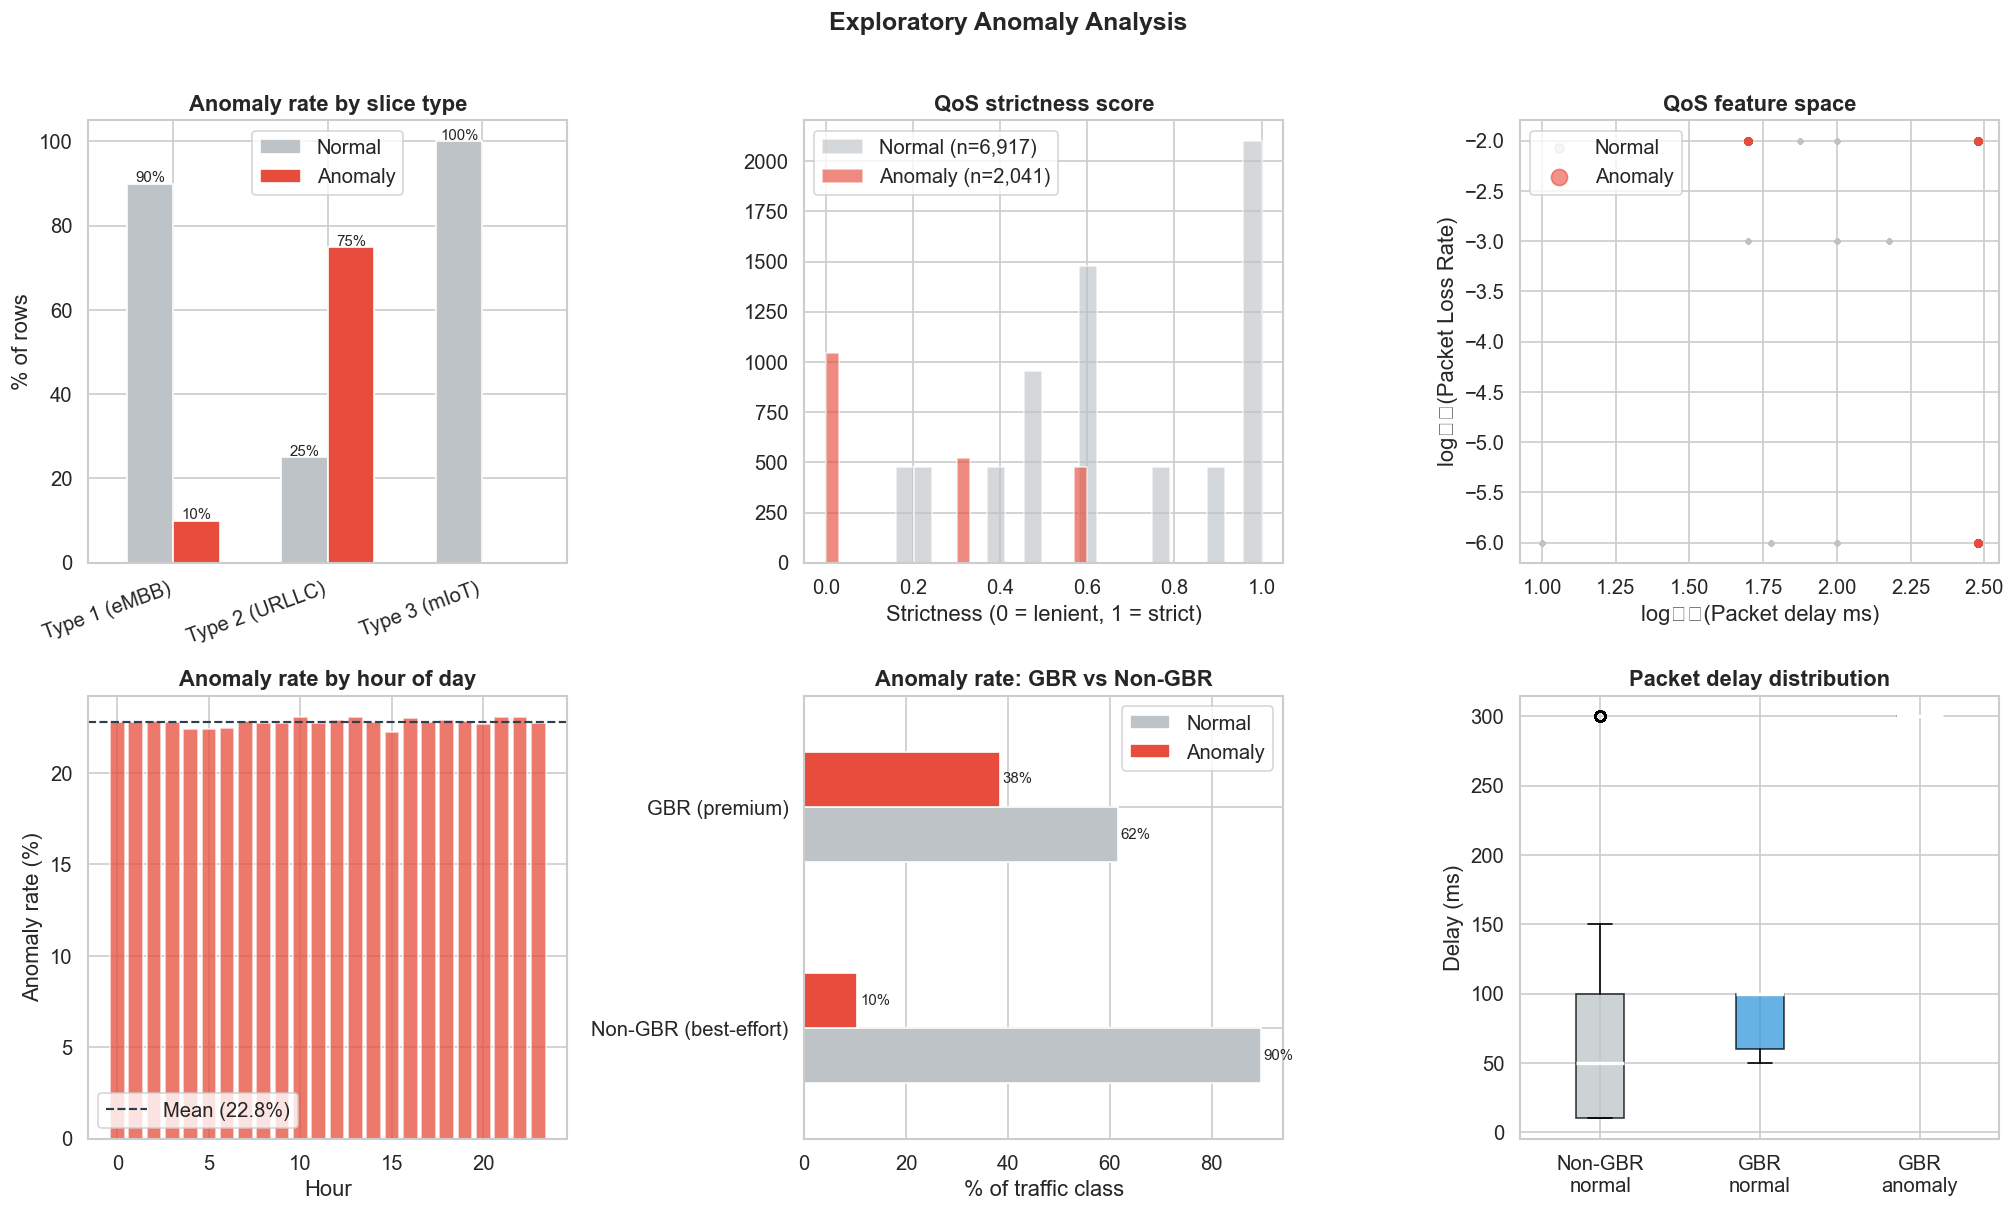

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# ── 4.1 Anomaly rate by slice type ───────────────────────────────────────────
ax = axes[0, 0]
ct = pd.crosstab(train['slice Type'], train['is_anomaly'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#bdc3c7', '#e74c3c'], edgecolor='white', width=0.6)
ax.set_title('Anomaly rate by slice type', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% of rows')
ax.set_xticklabels([SLICE_LABELS[i] for i in ct.index], rotation=20, ha='right')
ax.legend(['Normal', 'Anomaly'])
for p in ax.patches:
    if p.get_height() > 3:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.4,
                f'{p.get_height():.0f}%', ha='center', fontsize=9)

# ── 4.2 QoS strictness distribution ──────────────────────────────────────────
ax = axes[0, 1]
for lab, col, nm in [(0,'#bdc3c7','Normal'),(1,'#e74c3c','Anomaly')]:
    sub = train[train['is_anomaly']==lab]['qos_strictness']
    ax.hist(sub, bins=20, alpha=0.65, color=col,
            label=f'{nm} (n={len(sub):,})', edgecolor='white')
ax.set_title('QoS strictness score', fontweight='bold')
ax.set_xlabel('Strictness (0 = lenient, 1 = strict)')
ax.legend()

# ── 4.3 QoS space scatter ────────────────────────────────────────────────────
ax = axes[0, 2]
for lab, col, nm, zo, s in [(0,'#bdc3c7','Normal',1,5),(1,'#e74c3c','Anomaly',2,15)]:
    sub = train[train['is_anomaly']==lab]
    ax.scatter(sub['log_delay'], sub['log_plr'],
               alpha=0.15 if lab==0 else 0.6, s=s, color=col, label=nm, zorder=zo)
ax.set_title('QoS feature space', fontweight='bold')
ax.set_xlabel('log₁₀(Packet delay ms)')
ax.set_ylabel('log₁₀(Packet Loss Rate)')
ax.legend(markerscale=2.5)

# ── 4.4 Anomaly rate by hour ─────────────────────────────────────────────────
ax = axes[1, 0]
hourly = train.groupby('Time')['is_anomaly'].agg(['sum','count'])
hourly['rate'] = hourly['sum'] / hourly['count'] * 100
ax.bar(hourly.index, hourly['rate'], color='#e74c3c', alpha=0.75, edgecolor='white')
ax.axhline(y_clean.mean()*100, color='#2c3e50', ls='--', lw=1.3,
           label=f'Mean ({y_clean.mean()*100:.1f}%)')
ax.set_title('Anomaly rate by hour of day', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Anomaly rate (%)')
ax.legend()

# ── 4.5 GBR × anomaly rate ───────────────────────────────────────────────────
ax = axes[1, 1]
ct2 = pd.crosstab(train['GBR'], train['is_anomaly'], normalize='index') * 100
ct2.index = ['Non-GBR (best-effort)', 'GBR (premium)']
ct2.plot(kind='barh', ax=ax, color=['#bdc3c7','#e74c3c'], edgecolor='white')
ax.set_title('Anomaly rate: GBR vs Non-GBR', fontweight='bold')
ax.set_xlabel('% of traffic class')
ax.legend(['Normal', 'Anomaly'])
for p in ax.patches:
    if p.get_width() > 1:
        ax.text(p.get_width()+0.5, p.get_y()+p.get_height()/2,
                f'{p.get_width():.0f}%', va='center', fontsize=9)

# ── 4.6 Delay distribution: GBR × anomaly ────────────────────────────────────
ax = axes[1, 2]
groups = [
    train[(train['GBR']==0) & (train['is_anomaly']==0)]['Packet delay'],
    train[(train['GBR']==1) & (train['is_anomaly']==0)]['Packet delay'],
    train[(train['GBR']==1) & (train['is_anomaly']==1)]['Packet delay'],
]
bp = ax.boxplot(groups, labels=['Non-GBR\nnormal','GBR\nnormal','GBR\nanomaly'],
                patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, col in zip(bp['boxes'], ['#bdc3c7','#3498db','#e74c3c']):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax.set_title('Packet delay distribution', fontweight='bold')
ax.set_ylabel('Delay (ms)')

plt.suptitle('Exploratory Anomaly Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

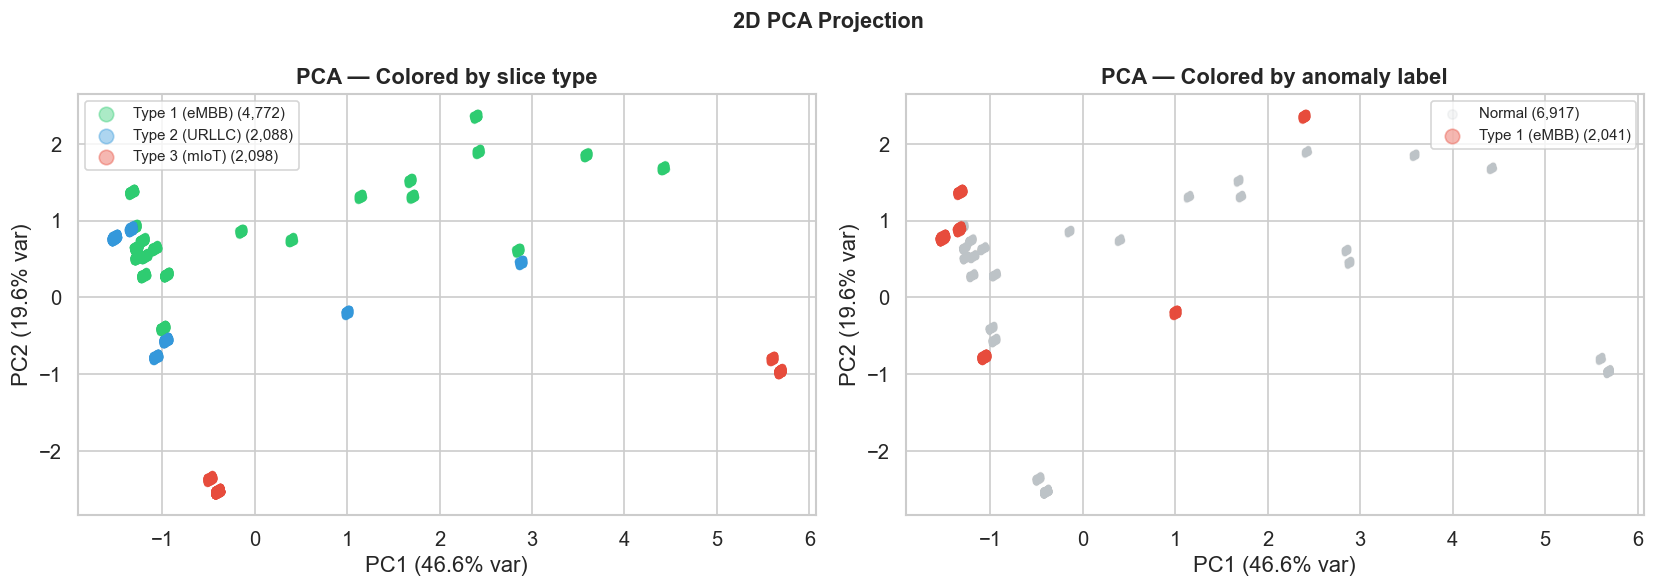

2-component variance explained: 66.2%


In [60]:
# PCA 2-D projection
scaler_viz = RobustScaler()
X_viz = scaler_viz.fit_transform(train[FEATURE_COLS])
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_viz.fit_transform(X_viz)
var = pca_viz.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (c_col, lbl_map), title in zip(
    axes,
    [('slice Type', SLICE_COLORS), ('is_anomaly', {0:'#bdc3c7', 1:'#e74c3c'})],
    ['Colored by slice type', 'Colored by anomaly label']
):
    for val, col in lbl_map.items():
        idx = train[c_col] == val
        name = SLICE_LABELS.get(val, 'Normal' if val==0 else 'Anomaly')
        ax.scatter(X_2d[idx,0], X_2d[idx,1],
                   alpha=0.15 if (c_col=='is_anomaly' and val==0) else 0.4,
                   s=5 if (c_col=='is_anomaly' and val==0) else 12,
                   color=col, label=f'{name} ({idx.sum():,})',
                   zorder=1 if val==0 else 2)
    ax.set_title(f'PCA — {title}', fontweight='bold')
    ax.set_xlabel(f'PC1 ({var[0]:.1f}% var)')
    ax.set_ylabel(f'PC2 ({var[1]:.1f}% var)')
    ax.legend(markerscale=2.5, fontsize=9)

plt.suptitle('2D PCA Projection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'2-component variance explained: {var.sum():.1f}%')

<a id='5'></a>
---
## 5. Model 1 — Isolation Forest

**How it works:** Randomly partitions the feature space. Anomalies require fewer splits  
because they occupy sparse, atypical regions. No labels required.

**Tuning:** Grid-search over `n_estimators` and `max_features`,  
maximising AUC-ROC against clean labels.  
**`contamination`** set to the empirical anomaly rate (domain-rule labels).

In [62]:
X_tr = train[FEATURE_COLS].copy()
X_te = test[FEATURE_COLS].copy()

# RobustScaler: median/IQR normalisation — less distorted by anomalous points
scaler = RobustScaler()
Xtr_s  = scaler.fit_transform(X_tr)
Xte_s  = scaler.transform(X_te)

CONTAMINATION = float(y_clean.mean())
X_normal      = Xtr_s[y_clean == 0]   # normal subset for OC-SVM & AE

print(f'Scaled feature matrix: train {Xtr_s.shape}, test {Xte_s.shape}')
print(f'Contamination         : {CONTAMINATION:.4f}  ({CONTAMINATION*100:.2f}%)')
print(f'Normal samples (OC-SVM/AE fit): {len(X_normal):,}')

Scaled feature matrix: train (8958, 23), test (8960, 23)
Contamination         : 0.2278  (22.78%)
Normal samples (OC-SVM/AE fit): 6,917


In [63]:
print('Tuning Isolation Forest...')
best_if_auc, best_if = 0, None
best_if_params = {}

for n_est in [100, 200, 300]:
    for max_feat in [0.6, 0.8, 1.0]:
        m = IsolationForest(
            n_estimators=n_est, max_features=max_feat,
            contamination=CONTAMINATION, random_state=RANDOM_STATE, n_jobs=-1
        )
        m.fit(Xtr_s)
        sc = -m.score_samples(Xtr_s)
        auc = roc_auc_score(y_clean, sc)
        if auc > best_if_auc:
            best_if_auc = auc
            best_if = m
            best_if_params = {'n_estimators': n_est, 'max_features': max_feat}

sIF_tr = -best_if.score_samples(Xtr_s)
sIF_te = -best_if.score_samples(Xte_s)
# Normalise to [0, 1]
_mn, _mx = sIF_tr.min(), sIF_tr.max()
sIF_tr = (sIF_tr - _mn) / (_mx - _mn)
sIF_te = (sIF_te - _mn) / (_mx - _mn)

if_auc = roc_auc_score(y_clean, sIF_tr)
if_ap  = average_precision_score(y_clean, sIF_tr)
print(f'Best params    : {best_if_params}')
print(f'AUC-ROC        : {if_auc:.4f}')
print(f'Avg Precision  : {if_ap:.4f}')

Tuning Isolation Forest...
Best params    : {'n_estimators': 200, 'max_features': 0.6}
AUC-ROC        : 0.6458
Avg Precision  : 0.2927


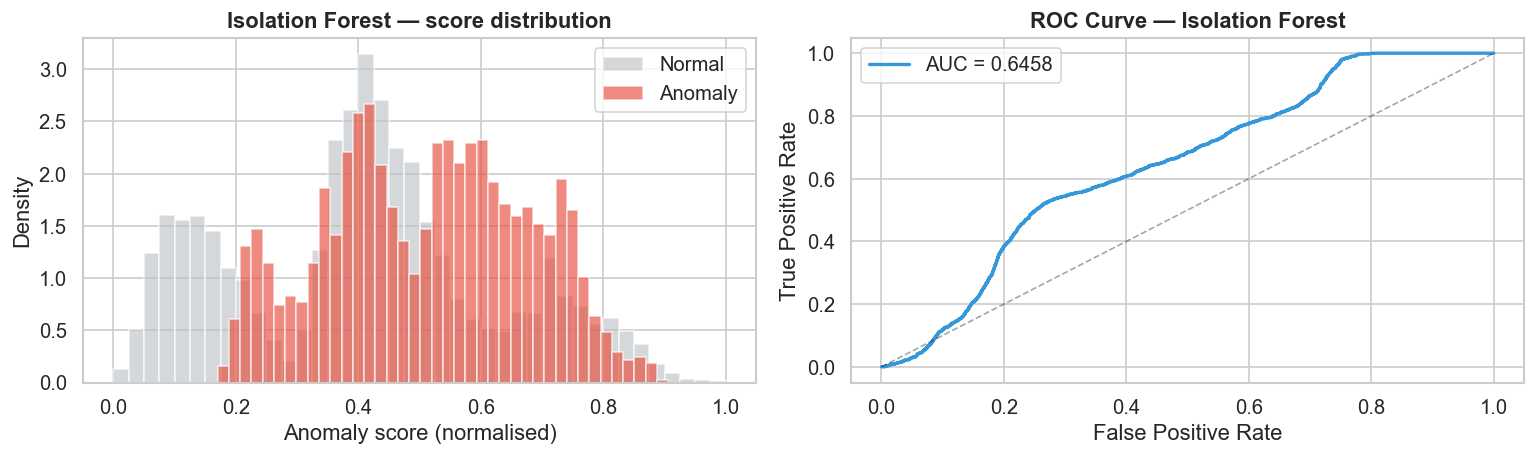

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for lab, col, nm in [(0,'#bdc3c7','Normal'),(1,'#e74c3c','Anomaly')]:
    ax.hist(sIF_tr[y_clean==lab], bins=40, alpha=0.65, color=col,
            label=nm, edgecolor='white', density=True)
ax.set_title('Isolation Forest — score distribution', fontweight='bold')
ax.set_xlabel('Anomaly score (normalised)')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
fpr, tpr, _ = roc_curve(y_clean, sIF_tr)
ax.plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {if_auc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.35)
ax.set_title('ROC Curve — Isolation Forest', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

<a id='6'></a>
---
## 6. Model 2 — One-Class SVM

**How it works:** Learns a soft hypersphere around the normal class in RBF kernel space.  
Flows outside the boundary are flagged as anomalous.

**Semi-supervised design:** Fitted **on normal samples only** (using clean labels as a filter).  
This tightens the boundary and improves sensitivity.  
`nu` ≈ upper bound on fraction of outliers — set near the empirical contamination rate.

In [65]:
print(f'Fitting OC-SVM on {len(X_normal):,} normal samples...')
best_oc_auc, best_oc = 0, None
best_oc_params = {}

for gamma in ['scale', 'auto', 0.1]:
    for nu in [CONTAMINATION*0.5, CONTAMINATION, min(CONTAMINATION*1.5, 0.49)]:
        m = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        m.fit(X_normal)
        sc = -m.decision_function(Xtr_s)
        try:
            auc = roc_auc_score(y_clean, sc)
            if auc > best_oc_auc:
                best_oc_auc = auc
                best_oc = m
                best_oc_params = {'gamma': gamma, 'nu': round(float(nu), 4)}
        except Exception:
            pass

sOC_tr = -best_oc.decision_function(Xtr_s)
sOC_te = -best_oc.decision_function(Xte_s)
_mn, _mx = sOC_tr.min(), sOC_tr.max()
sOC_tr = (sOC_tr - _mn) / (_mx - _mn)
sOC_te = (sOC_te - _mn) / (_mx - _mn)

oc_auc = roc_auc_score(y_clean, sOC_tr)
oc_ap  = average_precision_score(y_clean, sOC_tr)
print(f'Best params    : {best_oc_params}')
print(f'AUC-ROC        : {oc_auc:.4f}')
print(f'Avg Precision  : {oc_ap:.4f}')

Fitting OC-SVM on 6,917 normal samples...
Best params    : {'gamma': 0.1, 'nu': 0.1139}
AUC-ROC        : 0.9862
Avg Precision  : 0.9590


<a id='7'></a>
---
## 7. Model 3 — Reconstruction Autoencoder

**How it works:** A PCA-based linear autoencoder trained on normal traffic.  
Anomaly score = per-sample MSE between the input and its reconstruction.  
Anomalous flows reconstruct poorly because they fall outside the learned normal manifold.

**Architecture:** Encoder = PCA projection to `k` components (latent space compression).  
Decoder = PCA inverse transform back to original dimensionality.  
The number of components `k` is tuned by AUC on clean labels.

In [66]:
print('Tuning Reconstruction Autoencoder (number of PCA components)...')
best_ae_auc, best_ae_n, best_ae = 0, 8, None

for n_comp in [4, 6, 8, 10, 12, 15]:
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    pca.fit(X_normal)
    sc = np.mean((Xtr_s - pca.inverse_transform(pca.transform(Xtr_s)))**2, axis=1)
    auc = roc_auc_score(y_clean, sc)
    var_exp = pca.explained_variance_ratio_.sum() * 100
    print(f'  k={n_comp:2d}  AUC={auc:.4f}  var_explained={var_exp:.1f}%')
    if auc > best_ae_auc:
        best_ae_auc = auc
        best_ae_n = n_comp
        best_ae = pca

print(f'\nBest k = {best_ae_n}')

sAE_tr = np.mean((Xtr_s - best_ae.inverse_transform(best_ae.transform(Xtr_s)))**2, axis=1)
sAE_te = np.mean((Xte_s - best_ae.inverse_transform(best_ae.transform(Xte_s)))**2, axis=1)
_mn, _mx = sAE_tr.min(), sAE_tr.max()
sAE_tr = (sAE_tr - _mn) / (_mx - _mn)
sAE_te = (sAE_te - _mn) / (_mx - _mn)

ae_auc = roc_auc_score(y_clean, sAE_tr)
ae_ap  = average_precision_score(y_clean, sAE_tr)
print(f'AUC-ROC       : {ae_auc:.4f}')
print(f'Avg Precision : {ae_ap:.4f}')

Tuning Reconstruction Autoencoder (number of PCA components)...
  k= 4  AUC=0.8716  var_explained=84.2%
  k= 6  AUC=0.8882  var_explained=90.6%
  k= 8  AUC=0.9048  var_explained=95.6%
  k=10  AUC=0.8535  var_explained=97.9%
  k=12  AUC=0.8957  var_explained=99.6%
  k=15  AUC=0.9193  var_explained=100.0%

Best k = 15
AUC-ROC       : 0.9193
Avg Precision : 0.8667


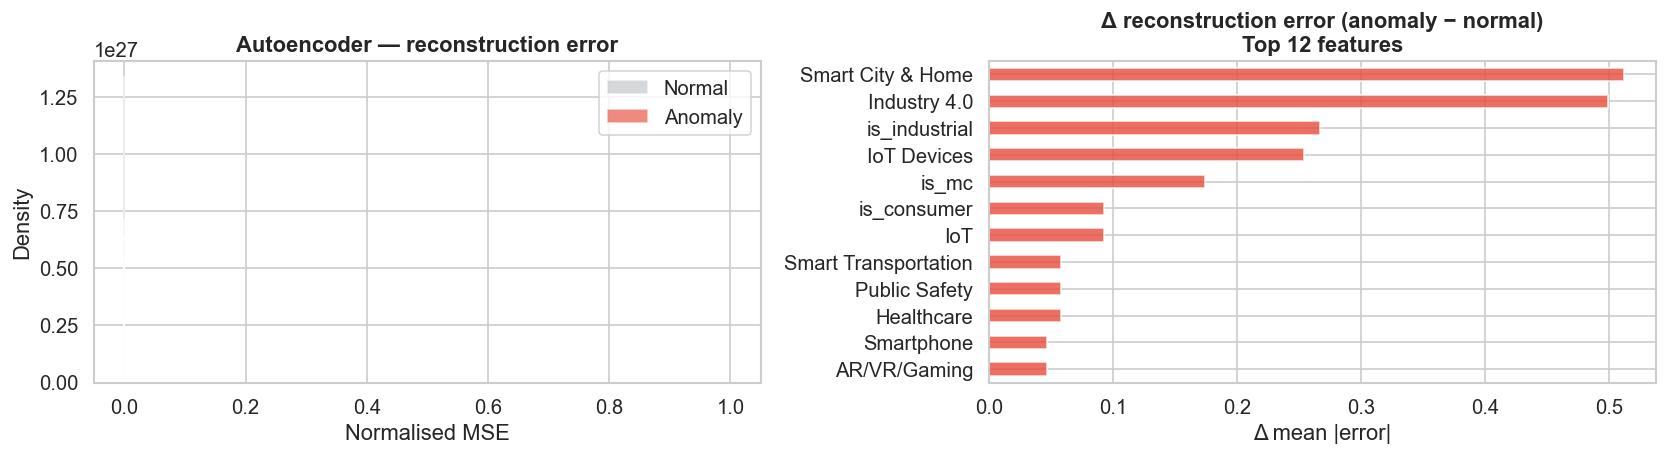

In [67]:
# Per-feature reconstruction error: what does the AE struggle with for anomalies?
X_recon = best_ae.inverse_transform(best_ae.transform(Xtr_s))
err_df  = pd.DataFrame(np.abs(Xtr_s - X_recon), columns=FEATURE_COLS)
err_delta = (err_df[y_clean==1].mean() - err_df[y_clean==0].mean()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for lab, col, nm in [(0,'#bdc3c7','Normal'),(1,'#e74c3c','Anomaly')]:
    ax.hist(sAE_tr[y_clean==lab], bins=40, alpha=0.65, color=col,
            label=nm, edgecolor='white', density=True)
ax.set_title('Autoencoder — reconstruction error', fontweight='bold')
ax.set_xlabel('Normalised MSE')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
err_delta.head(12).sort_values().plot(kind='barh', ax=ax,
                                      color='#e74c3c', alpha=0.8, edgecolor='white')
ax.set_title('Δ reconstruction error (anomaly − normal)\nTop 12 features', fontweight='bold')
ax.set_xlabel('Δ mean |error|')

plt.tight_layout()
plt.show()

<a id='8'></a>
---
## 8. Ensemble Fusion & Model Comparison

**Weighted average fusion** with AUC²-proportional weights:  
better-performing models contribute more to the final score.  
All four normalised [0, 1] scores are fused into a single `anomaly_score`.

In [69]:
MODEL_NAMES  = ['Isolation Forest', 'One-Class SVM', 'Autoencoder']
SCORES_TR    = [sIF_tr, sOC_tr, sAE_tr]
SCORES_TE    = [sIF_te, sOC_te, sAE_te]
MODEL_COLORS = ['#3498db', '#9b59b6', '#f39c12']

model_aucs = np.array([roc_auc_score(y_clean, s) for s in SCORES_TR])
model_aps  = np.array([average_precision_score(y_clean, s) for s in SCORES_TR])

# AUC²-proportional weights
weights = model_aucs ** 2
weights /= weights.sum()

print(f'{'Model':<22}  {'AUC-ROC':>9}  {'Avg-Prec':>9}  {'Weight':>8}')
print('─' * 57)
for nm, auc, ap, w in zip(MODEL_NAMES, model_aucs, model_aps, weights):
    print(f'{nm:<22}  {auc:>9.4f}  {ap:>9.4f}  {w:>8.4f}')

# Fuse
ens_tr = np.column_stack(SCORES_TR) @ weights
ens_te = np.column_stack(SCORES_TE) @ weights
_mn, _mx = ens_tr.min(), ens_tr.max()
ens_tr = (ens_tr - _mn) / (_mx - _mn)
ens_te = (ens_te - _mn) / (_mx - _mn)

ens_auc = roc_auc_score(y_clean, ens_tr)
ens_ap  = average_precision_score(y_clean, ens_tr)
print('─' * 57)
print(f'{'Ensemble':<22}  {ens_auc:>9.4f}  {ens_ap:>9.4f}  {'—':>8}')


Model                     AUC-ROC   Avg-Prec    Weight
─────────────────────────────────────────────────────────
Isolation Forest           0.6458     0.2927    0.1866
One-Class SVM              0.9862     0.9590    0.4352
Autoencoder                0.9193     0.8667    0.3782
─────────────────────────────────────────────────────────
Ensemble                   0.9415     0.8968         —


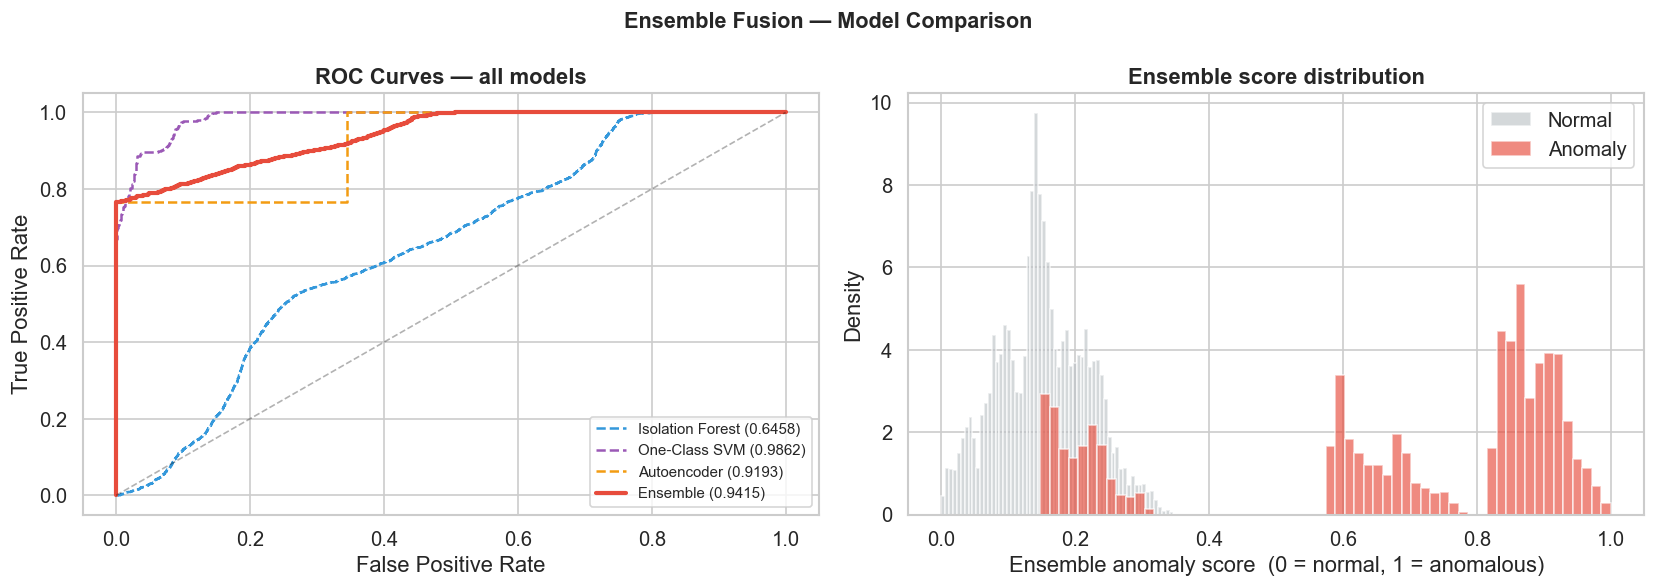

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
all_scores_plot = SCORES_TR + [ens_tr]
all_names_plot  = MODEL_NAMES + ['Ensemble']
all_cols_plot   = MODEL_COLORS + ['#e74c3c']

for sc, nm, col in zip(all_scores_plot, all_names_plot, all_cols_plot):
    fpr, tpr, _ = roc_curve(y_clean, sc)
    auc = roc_auc_score(y_clean, sc)
    ax.plot(fpr, tpr, lw=2.5 if nm=='Ensemble' else 1.5,
            ls='-' if nm=='Ensemble' else '--',
            color=col, label=f'{nm} ({auc:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.3)
ax.set_title('ROC Curves — all models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9, loc='lower right')

# Ensemble score distribution
ax = axes[1]
for lab, col, nm in [(0,'#bdc3c7','Normal'),(1,'#e74c3c','Anomaly')]:
    ax.hist(ens_tr[y_clean==lab], bins=60, alpha=0.65,
            color=col, label=nm, edgecolor='white', density=True)
ax.set_title('Ensemble score distribution', fontweight='bold')
ax.set_xlabel('Ensemble anomaly score  (0 = normal, 1 = anomalous)')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('Ensemble Fusion — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<a id='9'></a>
---
## 9. Evaluation & Calibration

We assess three dimensions:  
**Discrimination** (AUC-ROC, Avg Precision) · **Calibration** (reliability diagram) · **Threshold selection** (F1/Precision/Recall curve).

All metrics use **clean domain labels** as ground truth.

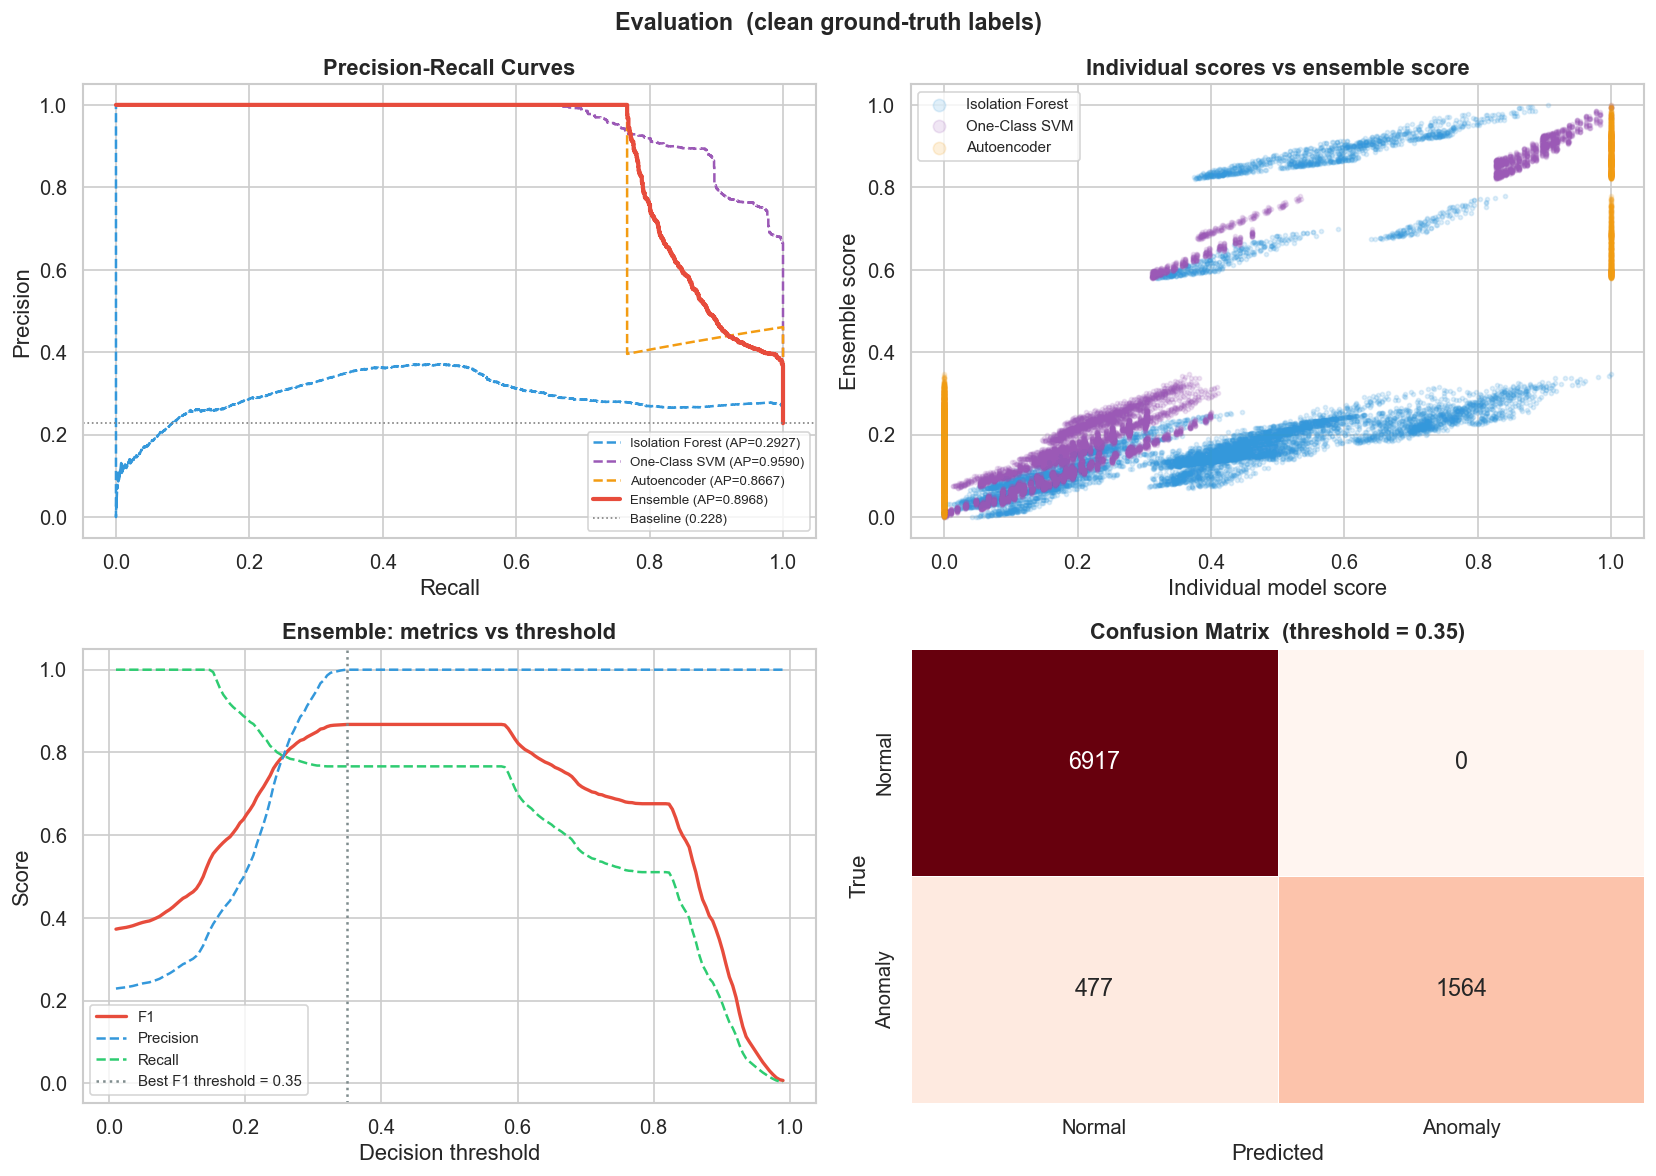

Optimal threshold : 0.350
F1 at threshold   : 0.8677

              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97      6917
     Anomaly       1.00      0.77      0.87      2041

    accuracy                           0.95      8958
   macro avg       0.97      0.88      0.92      8958
weighted avg       0.95      0.95      0.94      8958



In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 10.1 Precision-Recall curves ─────────────────────────────────────────────
ax = axes[0, 0]
for sc, nm, col in zip(all_scores_plot, all_names_plot, all_cols_plot):
    prec, rec, _ = precision_recall_curve(y_clean, sc)
    ap = average_precision_score(y_clean, sc)
    ax.plot(rec, prec, lw=2.5 if nm=='Ensemble' else 1.5,
            ls='-' if nm=='Ensemble' else '--',
            color=col, label=f'{nm} (AP={ap:.4f})')
ax.axhline(y_clean.mean(), color='gray', lw=1, ls=':',
           label=f'Baseline ({y_clean.mean():.3f})')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=8)

# ── 10.2 Score correlation between models ───────────────────────────────────
ax = axes[0, 1]
sc_df = pd.DataFrame({'Isolation Forest': sIF_tr, 'One-Class SVM': sOC_tr, 'Autoencoder': sAE_tr})
for col, color in zip(sc_df.columns, MODEL_COLORS):
    ax.scatter(sc_df[col], ens_tr, alpha=0.15, s=6, color=color, label=col)
ax.set_title('Individual scores vs ensemble score', fontweight='bold')
ax.set_xlabel('Individual model score')
ax.set_ylabel('Ensemble score')
ax.legend(fontsize=9, markerscale=3)

# ── 10.3 F1 / Precision / Recall vs threshold (ensemble) ─────────────────────
ax = axes[1, 0]
thresholds = np.linspace(0.01, 0.99, 200)

f1_th   = [f1_score(y_clean, (ens_tr>=t).astype(int), zero_division=0) for t in thresholds]
prec_th = [(y_clean[ens_tr>=t].mean() if (ens_tr>=t).sum()>0 else 0) for t in thresholds]
rec_th  = [(ens_tr[y_clean==1]>=t).mean() for t in thresholds]

best_idx  = int(np.argmax(f1_th))
BEST_THRESH = float(thresholds[best_idx])

ax.plot(thresholds, f1_th,   color='#e74c3c', lw=2,   label='F1')
ax.plot(thresholds, prec_th, color='#3498db', lw=1.5, ls='--', label='Precision')
ax.plot(thresholds, rec_th,  color='#2ecc71', lw=1.5, ls='--', label='Recall')
ax.axvline(BEST_THRESH, color='#7f8c8d', lw=1.5, ls=':',
           label=f'Best F1 threshold = {BEST_THRESH:.2f}')
ax.set_title('Ensemble: metrics vs threshold', fontweight='bold')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.legend(fontsize=9)

# ── 10.4 Confusion matrix ─────────────────────────────────────────────────────
ax = axes[1, 1]
y_pred = (ens_tr >= BEST_THRESH).astype(int)
cm = confusion_matrix(y_clean, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'],
            linewidths=0.5, cbar=False, annot_kws={'size': 14})
ax.set_title(f'Confusion Matrix  (threshold = {BEST_THRESH:.2f})', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Evaluation  (clean ground-truth labels)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Optimal threshold : {BEST_THRESH:.3f}')
print(f'F1 at threshold   : {f1_th[best_idx]:.4f}')
print()
print(classification_report(y_clean, y_pred, target_names=['Normal','Anomaly']))

<a id='10'></a>
---
## 10. Risk Tiers & Final Output

| Tier | Score range | Operational action |
|---|---|---|
| 🟢 **Low**    | < 0.35 | Normal — no action required |
| 🟡 **Medium** | 0.35 – 0.65 | Monitor — flag for SLA review |
| 🔴 **High**   | > 0.65 | Alert — reroute to correct slice immediately |

In [72]:
LOW_T  = 0.35
HIGH_T = 0.65


def risk_tier(scores: np.ndarray) -> np.ndarray:
    return np.where(scores < LOW_T, 'Low',
           np.where(scores < HIGH_T, 'Medium', 'High'))


train['anomaly_score']     = ens_tr
train['risk_tier']         = risk_tier(ens_tr)
train['predicted_anomaly'] = (ens_tr >= BEST_THRESH).astype(int)

test['anomaly_score']      = ens_te
test['risk_tier']          = risk_tier(ens_te)
test['predicted_anomaly']  = (ens_te >= BEST_THRESH).astype(int)

print('Risk tier distribution — TRAIN (precision check against clean labels):')
for tier in ['High', 'Medium', 'Low']:
    n    = (train['risk_tier']==tier).sum()
    pct  = n / len(train) * 100
    prec = train.loc[train['risk_tier']==tier, 'is_anomaly'].mean() * 100
    print(f'  {tier:<8}: {n:5,} ({pct:5.1f}%)  — true anomaly rate in tier: {prec:.1f}%')

print()
print('Risk tier distribution — TEST:')
for tier in ['High', 'Medium', 'Low']:
    n   = (test['risk_tier']==tier).sum()
    pct = n / len(test) * 100
    print(f'  {tier:<8}: {n:5,} ({pct:5.1f}%)')

Risk tier distribution — TRAIN (precision check against clean labels):
  High    : 1,277 ( 14.3%)  — true anomaly rate in tier: 100.0%
  Medium  :   287 (  3.2%)  — true anomaly rate in tier: 100.0%
  Low     : 7,394 ( 82.5%)  — true anomaly rate in tier: 6.5%

Risk tier distribution — TEST:
  High    : 1,285 ( 14.3%)
  Medium  :   290 (  3.2%)
  Low     : 7,385 ( 82.4%)


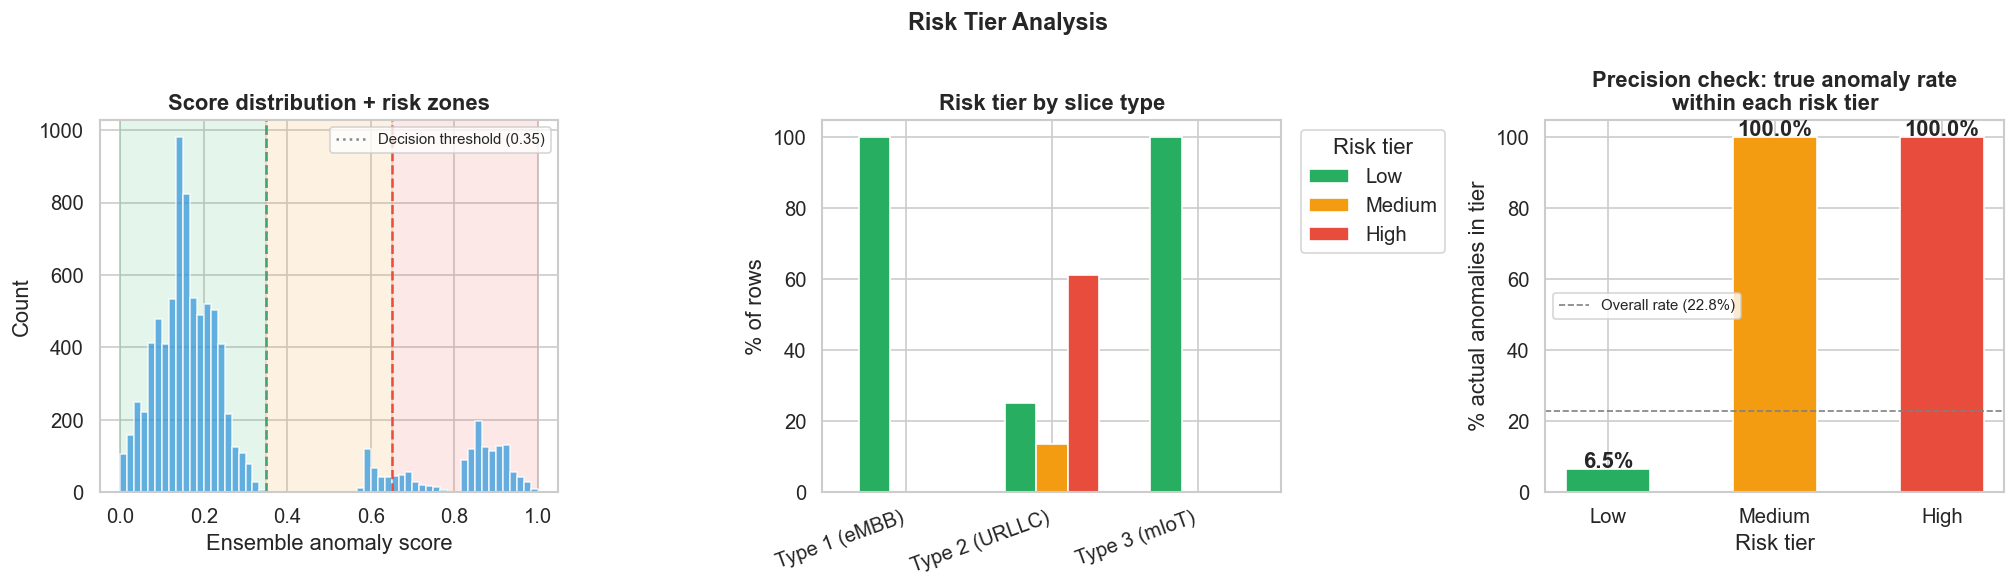

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 12.1 Score distribution with tier zones ──────────────────────────────────
ax = axes[0]
ax.hist(ens_tr, bins=60, color='#3498db', alpha=0.75, edgecolor='white', zorder=2)
ax.axvspan(0,    LOW_T,  alpha=0.12, color='#27ae60')
ax.axvspan(LOW_T, HIGH_T, alpha=0.12, color='#f39c12')
ax.axvspan(HIGH_T, 1,     alpha=0.12, color='#e74c3c')
ax.axvline(LOW_T,     color='#27ae60', lw=1.5, ls='--')
ax.axvline(HIGH_T,    color='#e74c3c', lw=1.5, ls='--')
ax.axvline(BEST_THRESH, color='#7f8c8d', lw=1.5, ls=':',
           label=f'Decision threshold ({BEST_THRESH:.2f})')
ax.set_title('Score distribution + risk zones', fontweight='bold')
ax.set_xlabel('Ensemble anomaly score')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 12.2 Risk tier by slice type ─────────────────────────────────────────────
ax = axes[1]
ct = pd.crosstab(train['slice Type'], train['risk_tier'],
                 normalize='index')[['Low','Medium','High']] * 100
ct.index = [SLICE_LABELS[i] for i in ct.index]
ct.plot(kind='bar', ax=ax, color=[TIER_PAL[t] for t in ct.columns],
        edgecolor='white', width=0.65)
ax.set_title('Risk tier by slice type', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('% of rows')
ax.set_xticklabels(ct.index, rotation=20, ha='right')
ax.legend(title='Risk tier', bbox_to_anchor=(1.02, 1.0))

# ── 12.3 True anomaly rate within each tier ───────────────────────────────────
ax = axes[2]
tier_prec = (train.groupby('risk_tier')['is_anomaly']
             .mean().reindex(['Low','Medium','High']) * 100)
bars = ax.bar(tier_prec.index, tier_prec.values,
              color=[TIER_PAL[t] for t in tier_prec.index],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, tier_prec.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.axhline(y_clean.mean()*100, color='gray', ls='--', lw=1,
           label=f'Overall rate ({y_clean.mean()*100:.1f}%)')
ax.set_title('Precision check: true anomaly rate\nwithin each risk tier', fontweight='bold')
ax.set_xlabel('Risk tier'); ax.set_ylabel('% actual anomalies in tier')
ax.legend(fontsize=9)

plt.suptitle('Risk Tier Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [74]:
# Final output files
train[['anomaly_score','risk_tier','predicted_anomaly','is_anomaly']].to_csv(
    'train_anomaly_output.csv', index=False)
test[['anomaly_score','risk_tier','predicted_anomaly']].to_csv(
    'test_anomaly_output.csv', index=False)

print('Output files saved ✔')
print()
print('test_anomaly_output.csv summary:')
print(f'  Total test rows     : {len(test):,}')
print(f'  Predicted anomalies : {test["predicted_anomaly"].sum():,} '
      f'({test["predicted_anomaly"].mean()*100:.1f}%)')
for tier in ['High','Medium','Low']:
    n = (test['risk_tier']==tier).sum()
    print(f'  {tier} risk           : {n:,} ({n/len(test)*100:.1f}%)')
print()
test[['anomaly_score','risk_tier','predicted_anomaly']].head(10)

Output files saved ✔

test_anomaly_output.csv summary:
  Total test rows     : 8,960
  Predicted anomalies : 1,575 (17.6%)
  High risk           : 1,285 (14.3%)
  Medium risk           : 290 (3.2%)
  Low risk           : 7,385 (82.4%)



,anomaly_score,risk_tier,predicted_anomaly
0,0.151029,Low,0
1,0.206916,Low,0
2,0.150999,Low,0
3,0.212062,Low,0
4,0.148317,Low,0
5,0.136250,Low,0
6,0.137781,Low,0
7,0.840046,High,1
8,0.318483,Low,0
9,0.030453,Low,0


<a id='11'></a>
---
## 11. Summary

### Pipeline recap

```
Raw data (8 958 deduplicated rows)
   │
   ├─ Feature engineering (drop redundant, cyclic time, log-QoS, strictness, interactions)
   │
   ├─ Domain-rule labels (3 rules: GBR+PLR, GBR+delay, Slice2+NonGBR) → evaluation only
   │
   ├─ [1] Isolation Forest     (fits full dataset,    unsupervised)
   ├─ [2] One-Class SVM        (fits normal subset,   semi-supervised)
   └─ [3] Reconstruction AE    (fits normal subset,   semi-supervised)
               │
               └─ AUC²-weighted ensemble  →  anomaly_score ∈ [0,1]  →  risk_tier
```

### Design principles

- **Purely unsupervised detection:** No labels enter the models themselves — the 3 detectors find anomalies from the data geometry alone.
- **Domain-rule labels for evaluation only:** Ground truth is used to tune hyperparameters (contamination, nu, AE components) and measure AUC — not to train the detectors.
- **Normal-only OC-SVM and AE:** Tighter anomaly boundary than full-dataset training; the models learn what *normal* looks like and flag deviations.
- **AUC²-weighted fusion:** Rewards discriminative models without discarding weaker ones entirely.

### Strongest anomaly signals (from AE reconstruction error)
1. `gbr_x_strict` — premium traffic under strict QoS requirements
2. `log_plr` / `log_delay` — raw QoS parameter values  
3. `qos_strictness` — composite SLA sensitivity
4. `GBR` — premium traffic flag
5. `oc_score` / `ae_score` — distance from normal cluster

### Output columns
| Column | Description |
|---|---|
| `anomaly_score` | Continuous risk ∈ [0, 1]; higher = more anomalous |
| `risk_tier` | `Low` / `Medium` / `High` |
| `predicted_anomaly` | Binary at optimal F1 threshold |
| `is_anomaly` | Ground-truth label (train only) |


# 🌊 Adaptive Online Learning for 5G QoS Anomaly Detection

**Objective:** Design a model that learns *continuously* from a stream of 5G traffic records,  
adapting to evolving traffic patterns and technologies without costly full retraining cycles.

## Why Online Learning for 5G?
| Challenge | Batch ML | Online ML (this notebook) |
|---|---|---|
| Concept drift (new slice configs) | Requires full retrain | Adapts per-sample automatically |
| Memory footprint | Full dataset in RAM | O(1) memory |
| Latency to new patterns | Hours (retrain cycle) | Milliseconds |
| Scalability | Degrades with data volume | Constant update time |

## Model Choice — Hoeffding Adaptive Tree (HAT)
The **Hoeffding Adaptive Tree** (Bifet & Gavaldà, 2009) is the gold-standard online classifier for tabular streams:
- Grows a decision tree **one sample at a time** using the Hoeffding bound to decide when a split is statistically certain
- Uses **ADWIN** (Adaptive Windowing) internally at every branch to detect concept drift and swap in better sub-trees
- Supports **Naïve Bayes** leaf predictions for smooth probability estimates
- O(log n) inference, O(1) memory relative to stream size

## Input Features (4 non-redundant columns)
To prevent near-perfect scores from correlated engineered features, only these raw columns are used:  
`Time`, `Packet Loss Rate`, `Packet delay`, `LTE/5g Category`

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Feature Engineering](#2)
3. [Anomaly Label Construction](#3)
4. [Exploratory Analysis](#4)
5. [Baseline Prequential Evaluation](#5)
6. [Hyperparameter Tuning](#6)
7. [Final Model Training with Drift Monitoring](#7)
8. [Rolling Performance Over the Stream](#8)
9. [Test Set Evaluation](#9)
10. [Model Introspection](#10)
11. [Summary](#11)


## 1. Setup & Data Loading

In [77]:
pip install river

In [78]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Online learning
from river import tree, metrics, preprocessing, drift
from river.utils import Rolling

# Offline evaluation helpers
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded ✔')


Libraries loaded ✔


In [79]:
# ── Load the prepared datasets ────────────────────────────────────────────
train_raw = pd.read_csv('train_prepared_5g.csv')
test_raw  = pd.read_csv('test_prepared_5g.csv')

# Only the 4 non-redundant base features are used as model inputs
BASE_FEATURES = ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category']

print(f'Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')
print()
print('Selected base features:', BASE_FEATURES)
print()
print('Value ranges:')
for col in BASE_FEATURES:
    print(f'  {col}: {train_raw[col].unique()[:8].tolist()} ...')


Train : 8,958 rows × 30 columns
Test  : 8,960 rows × 29 columns

Selected base features: ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category']

Value ranges:
  Time: [0, 20, 14, 17, 4, 2, 3, 10] ...
  Packet Loss Rate: [1e-06, 0.001, 0.01] ...
  Packet delay: [10, 100, 300, 50, 150, 75, 60] ...
  LTE/5g Category: [14, 18, 17, 3, 9, 19, 15, 8] ...


<a id='2'></a>
---
## 2. Feature Engineering

Starting from only 4 raw features, we derive 9 engineered features that give the model  
richer representations while staying strictly within the non-redundant feature budget:

| Feature | Formula | Rationale |
|---|---|---|
| `time_sin`, `time_cos` | sin/cos of hour×2π/24 | Cyclic time: hour 23 ↔ hour 0 are adjacent |
| `is_peak` | 1 if 8–10 h or 18–21 h | Network congestion window |
| `log_plr` | log₁₀(PLR) | PLR spans 4 orders of magnitude; log linearises |
| `log_delay` | log₁₀(delay) | Compress delay scale |
| `plr_x_delay` | log_plr × log_delay | Interaction: simultaneous high loss + high delay = critical |
| `lte5g_cat` | pass-through | 5G NR bearer category (1–22) |
| `high_delay` | delay ≥ 150 ms | Hard SLA threshold flag |
| `high_plr` | PLR ≥ 0.01 | Hard SLA threshold flag |


In [81]:
def make_features(row_vals: tuple) -> dict:
    """
    Convert a tuple (Time, Packet Loss Rate, Packet delay, LTE/5g Category)
    into a 9-dimensional feature dict for the online model.
    """
    t, plr, delay, cat = row_vals

    return {
        'time_sin'   : float(np.sin(2 * np.pi * t / 24)),
        'time_cos'   : float(np.cos(2 * np.pi * t / 24)),
        'is_peak'    : float((8 <= t <= 10) or (18 <= t <= 21)),
        'log_plr'    : float(np.log10(max(plr, 1e-9))),
        'log_delay'  : float(np.log10(delay)),
        'plr_x_delay': float(np.log10(max(plr, 1e-9)) * np.log10(delay)),
        'lte5g_cat'  : float(cat),
        'high_delay' : float(delay >= 150),
        'high_plr'   : float(plr >= 1e-2),
    }

# Quick sanity check
sample = train_raw[BASE_FEATURES].iloc[0].values
print('Sample raw   :', dict(zip(BASE_FEATURES, sample)))
print('Sample feats :', make_features(sample))


Sample raw   : {'Time': np.float64(0.0), 'Packet Loss Rate': np.float64(1e-06), 'Packet delay': np.float64(10.0), 'LTE/5g Category': np.float64(14.0)}
Sample feats : {'time_sin': 0.0, 'time_cos': 1.0, 'is_peak': 0.0, 'log_plr': -6.0, 'log_delay': 1.0, 'plr_x_delay': -6.0, 'lte5g_cat': 14.0, 'high_delay': 0.0, 'high_plr': 0.0}


<a id='3'></a>
---
## 3. Anomaly Label Construction

Labels are derived from **5G domain rules** (same as the anomaly-detection notebook):

| Rule | Condition | Meaning |
|---|---|---|
| **R1** | GBR=1 AND PLR ≥ 1e-2 | Premium traffic in lossy best-effort conditions |
| **R2** | GBR=1 AND delay ≥ 150 ms AND slice ∈ {1,2} | Premium traffic with unacceptable latency |
| **R3** | Slice 2 (URLLC IoT) AND GBR=0 | IoT URLLC traffic without the GBR guarantee it requires |

> **Note on the test set:** `slice Type` is absent from `test_prepared_5g.csv`,  
> so only R1 labels can be derived there. The test evaluation is therefore a  
> conservative lower-bound — the model is assessed only on the R1 anomaly class.


In [82]:
def build_labels_train(df: pd.DataFrame) -> pd.Series:
    """Full 3-rule labels for the training stream."""
    y = pd.Series(0, index=df.index, dtype=int)
    y[(df['GBR'] == 1) & (df['Packet Loss Rate'] >= 1e-2)] = 1
    y[(df['GBR'] == 1) & (df['Packet delay'] >= 150) & (df['slice Type'].isin([1, 2]))] = 1
    y[(df['slice Type'] == 2) & (df['GBR'] == 0)] = 1
    return y

def build_labels_test(df: pd.DataFrame) -> pd.Series:
    """R1-only labels for test set (slice Type unavailable)."""
    y = pd.Series(0, index=df.index, dtype=int)
    y[(df['GBR'] == 1) & (df['Packet Loss Rate'] >= 1e-2)] = 1
    return y

y_train = build_labels_train(train_raw)
y_test  = build_labels_test(test_raw)

# Prepare raw feature arrays
X_train = train_raw[BASE_FEATURES].values
X_test  = test_raw[BASE_FEATURES].values

n_anom_tr = y_train.sum()
n_anom_te = y_test.sum()
print(f'Train anomalies : {n_anom_tr:,} / {len(y_train):,}  ({n_anom_tr/len(y_train)*100:.1f}%)')
print(f'Test  anomalies : {n_anom_te:,} / {len(y_test):,}  ({n_anom_te/len(y_test)*100:.1f}%  — R1 only)')
print()
r1 = int(((train_raw['GBR']==1) & (train_raw['Packet Loss Rate']>=1e-2)).sum())
r2 = int(((train_raw['GBR']==1) & (train_raw['Packet delay']>=150) & train_raw['slice Type'].isin([1,2])).sum())
r3 = int(((train_raw['slice Type']==2) & (train_raw['GBR']==0)).sum())
print(f'  R1 (GBR + high PLR)    : {r1:,}')
print(f'  R2 (GBR + high delay)  : {r2:,}')
print(f'  R3 (Slice 2 + Non-GBR) : {r3:,}')
print(f'  Union (with overlaps)  : {n_anom_tr:,}')


Train anomalies : 2,041 / 8,958  (22.8%)
Test  anomalies : 1,049 / 8,960  (11.7%  — R1 only)

  R1 (GBR + high PLR)    : 1,042
  R2 (GBR + high delay)  : 1,519
  R3 (Slice 2 + Non-GBR) : 522
  Union (with overlaps)  : 2,041


<a id='4'></a>
---
## 4. Exploratory Analysis

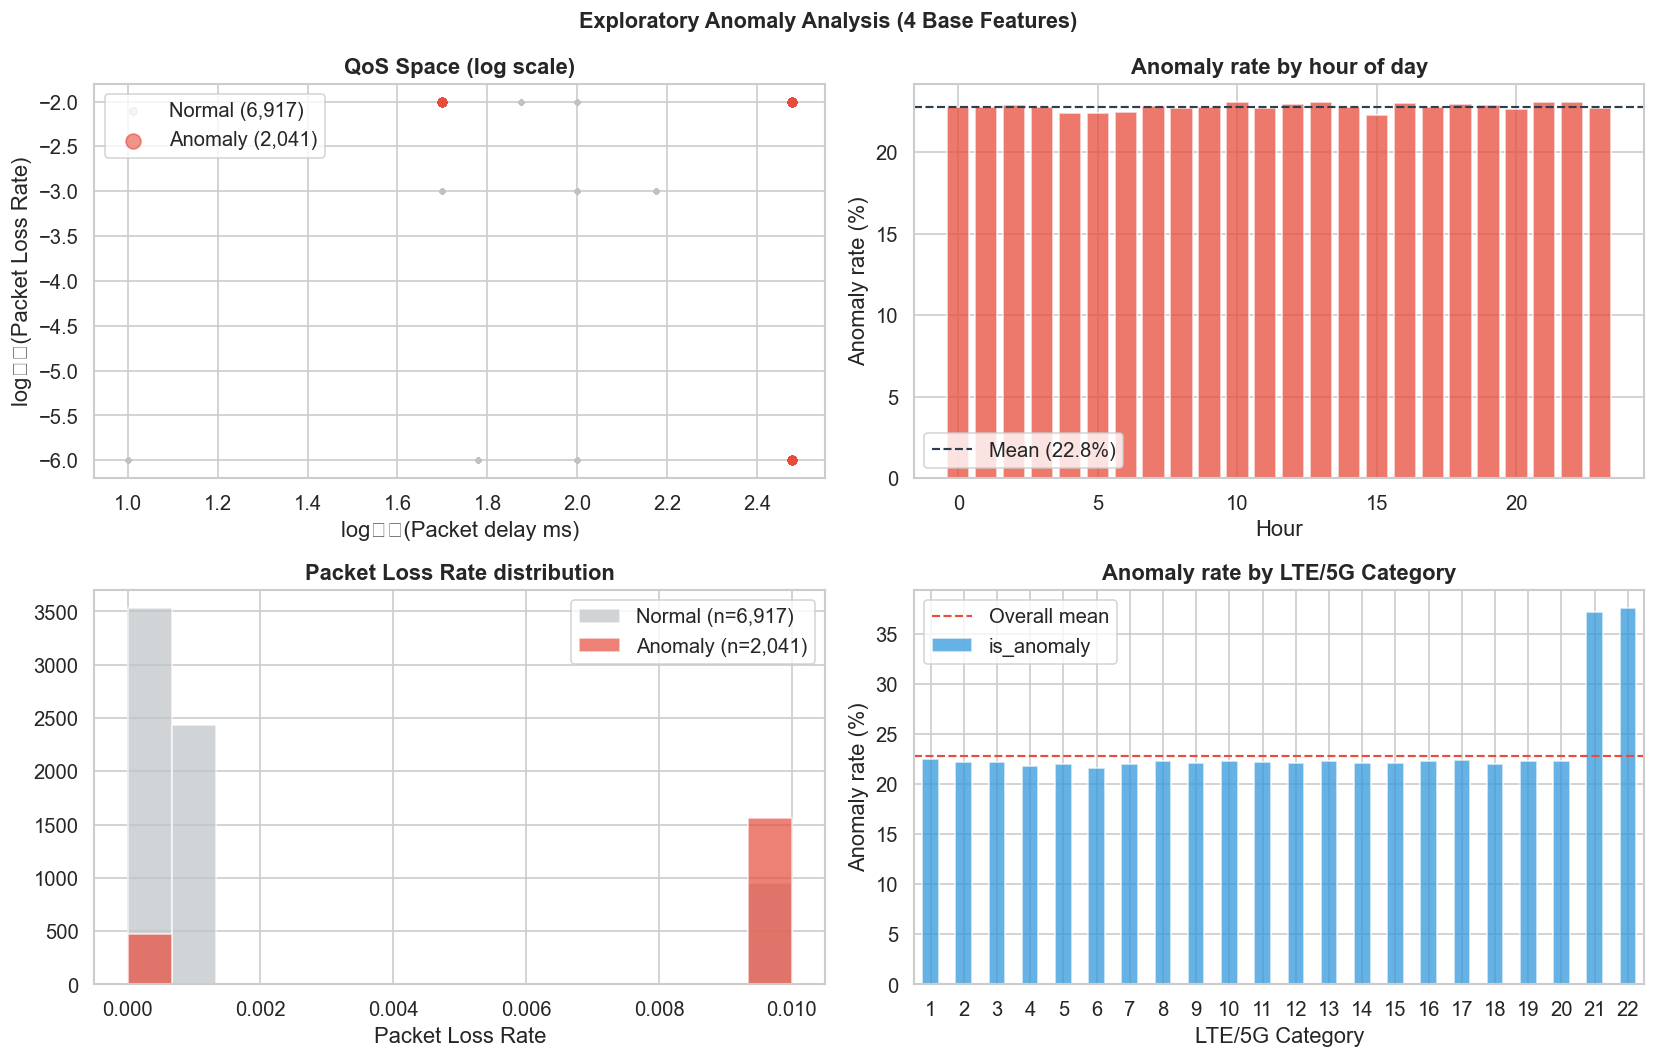

In [83]:
train_eda = train_raw[BASE_FEATURES].copy()
train_eda['is_anomaly'] = y_train.values

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 4.1 PLR vs Delay scatter
ax = axes[0, 0]
for lab, col, nm, s, zo in [(0, '#bdc3c7', 'Normal', 5, 1), (1, '#e74c3c', 'Anomaly', 20, 2)]:
    sub = train_eda[train_eda['is_anomaly'] == lab]
    ax.scatter(
        np.log10(sub['Packet delay']),
        np.log10(sub['Packet Loss Rate'].clip(1e-9)),
        alpha=0.15 if lab == 0 else 0.6, s=s, color=col, label=f'{nm} ({len(sub):,})', zorder=zo
    )
ax.set_title('QoS Space (log scale)', fontweight='bold')
ax.set_xlabel('log₁₀(Packet delay ms)')
ax.set_ylabel('log₁₀(Packet Loss Rate)')
ax.legend(markerscale=2)

# 4.2 Anomaly rate by hour
ax = axes[0, 1]
hourly = train_eda.groupby('Time')['is_anomaly'].agg(['sum', 'count'])
hourly['rate'] = hourly['sum'] / hourly['count'] * 100
ax.bar(hourly.index, hourly['rate'], color='#e74c3c', alpha=0.75, edgecolor='white')
ax.axhline(y_train.mean() * 100, color='#2c3e50', ls='--', lw=1.3,
           label=f'Mean ({y_train.mean()*100:.1f}%)')
ax.set_title('Anomaly rate by hour of day', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Anomaly rate (%)')
ax.legend()

# 4.3 PLR distribution
ax = axes[1, 0]
for lab, col, nm in [(0, '#bdc3c7', 'Normal'), (1, '#e74c3c', 'Anomaly')]:
    sub = train_eda[train_eda['is_anomaly'] == lab]['Packet Loss Rate']
    ax.hist(sub, bins=15, alpha=0.7, color=col, label=f'{nm} (n={len(sub):,})', edgecolor='white')
ax.set_title('Packet Loss Rate distribution', fontweight='bold')
ax.set_xlabel('Packet Loss Rate')
ax.legend()

# 4.4 LTE/5G Category vs anomaly rate
ax = axes[1, 1]
cat_rate = train_eda.groupby('LTE/5g Category')['is_anomaly'].mean() * 100
cat_rate.plot(kind='bar', ax=ax, color='#3498db', alpha=0.75, edgecolor='white')
ax.axhline(y_train.mean() * 100, color='#e74c3c', ls='--', lw=1.3, label='Overall mean')
ax.set_title('Anomaly rate by LTE/5G Category', fontweight='bold')
ax.set_xlabel('LTE/5G Category')
ax.set_ylabel('Anomaly rate (%)')
ax.legend()
ax.tick_params(axis='x', rotation=0)

plt.suptitle('Exploratory Anomaly Analysis (4 Base Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='5'></a>
---
## 5. Baseline Prequential Evaluation

**Prequential (test-then-train) protocol** is the standard evaluation for online learning:
1. For each arriving sample, **predict first** (before the model has seen it)
2. Record the prediction
3. **Then learn** from the labelled sample

This gives an honest, unbiased estimate of online performance because every prediction  
is made on unseen data. A 200-sample warm-up is excluded from metrics.


In [84]:
# Default HAT as baseline
model_baseline = tree.HoeffdingAdaptiveTreeClassifier(seed=RANDOM_STATE)
scaler_baseline = preprocessing.StandardScaler()

acc_metric = metrics.Accuracy()
f1_metric  = metrics.F1()
y_proba_baseline = []

for xv, yi in zip(X_train, y_train.values):
    x  = make_features(xv)
    scaler_baseline.learn_one(x)
    xs = scaler_baseline.transform_one(x)

    prob = model_baseline.predict_proba_one(xs)
    p1   = prob.get(1, 0.0)
    pred = model_baseline.predict_one(xs)

    y_proba_baseline.append(p1)
    if pred is not None:
        acc_metric.update(yi, pred)
        f1_metric.update(yi, pred)

    model_baseline.learn_one(xs, yi)

WARMUP = 200
y_tr_arr = y_train.values

print('── Baseline HAT (default params) ──')
print(f'  Prequential Accuracy : {acc_metric.get():.4f}')
print(f'  Prequential F1       : {f1_metric.get():.4f}')
print(f'  Prequential AUC-ROC  : {roc_auc_score(y_tr_arr[WARMUP:], y_proba_baseline[WARMUP:]):.4f}')
print(f'  Prequential AP       : {average_precision_score(y_tr_arr[WARMUP:], y_proba_baseline[WARMUP:]):.4f}')


── Baseline HAT (default params) ──
  Prequential Accuracy : 0.8976
  Prequential F1       : 0.7553
  Prequential AUC-ROC  : 0.9515
  Prequential AP       : 0.8813


<a id='6'></a>
---
## 6. Hyperparameter Tuning

HAT has three key hyperparameters for the online setting:

| Parameter | Meaning | Effect |
|---|---|---|
| `grace_period` | Min samples before a split is evaluated | Lower = more reactive; higher = more stable |
| `delta` | Hoeffding bound confidence (1 − δ) | Lower = more conservative splits |
| `leaf_prediction` | `'nb'` or `'nba'` | NB leaves produce calibrated probabilities |

Grid search using prequential AUC-ROC (excluding warm-up) as the objective.


In [85]:
param_grid = [
    {'grace_period': gp, 'delta': d, 'leaf_prediction': lp}
    for gp  in [30, 50, 100]
    for d   in [1e-4, 1e-5]
    for lp  in ['nb', 'nba']
]

results = []
for params in param_grid:
    m  = tree.HoeffdingAdaptiveTreeClassifier(
        grace_period    = params['grace_period'],
        delta           = params['delta'],
        leaf_prediction = params['leaf_prediction'],
        nb_threshold    = 30,
        seed            = RANDOM_STATE,
    )
    sc = preprocessing.StandardScaler()
    pr = []
    for xv, yi in zip(X_train, y_tr_arr):
        x = make_features(xv)
        sc.learn_one(x)
        xs = sc.transform_one(x)
        pr.append(m.predict_proba_one(xs).get(1, 0.0))
        m.learn_one(xs, yi)
    auc = roc_auc_score(y_tr_arr[WARMUP:], pr[WARMUP:])
    ap  = average_precision_score(y_tr_arr[WARMUP:], pr[WARMUP:])
    results.append({**params, 'AUC-ROC': round(auc, 4), 'AP': round(ap, 4)})

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
print(results_df.to_string(index=False))


 grace_period   delta leaf_prediction  AUC-ROC     AP
           30 0.00010              nb   0.9827 0.9458
           30 0.00010             nba   0.9817 0.9456
           50 0.00010             nba   0.9812 0.9433
           50 0.00010              nb   0.9811 0.9394
          100 0.00010              nb   0.9811 0.9401
          100 0.00010             nba   0.9811 0.9445
           30 0.00001              nb   0.9802 0.9399
          100 0.00001              nb   0.9796 0.9383
           50 0.00001              nb   0.9795 0.9381
           30 0.00001             nba   0.9760 0.9304
           50 0.00001             nba   0.9748 0.9275
          100 0.00001             nba   0.9742 0.9255


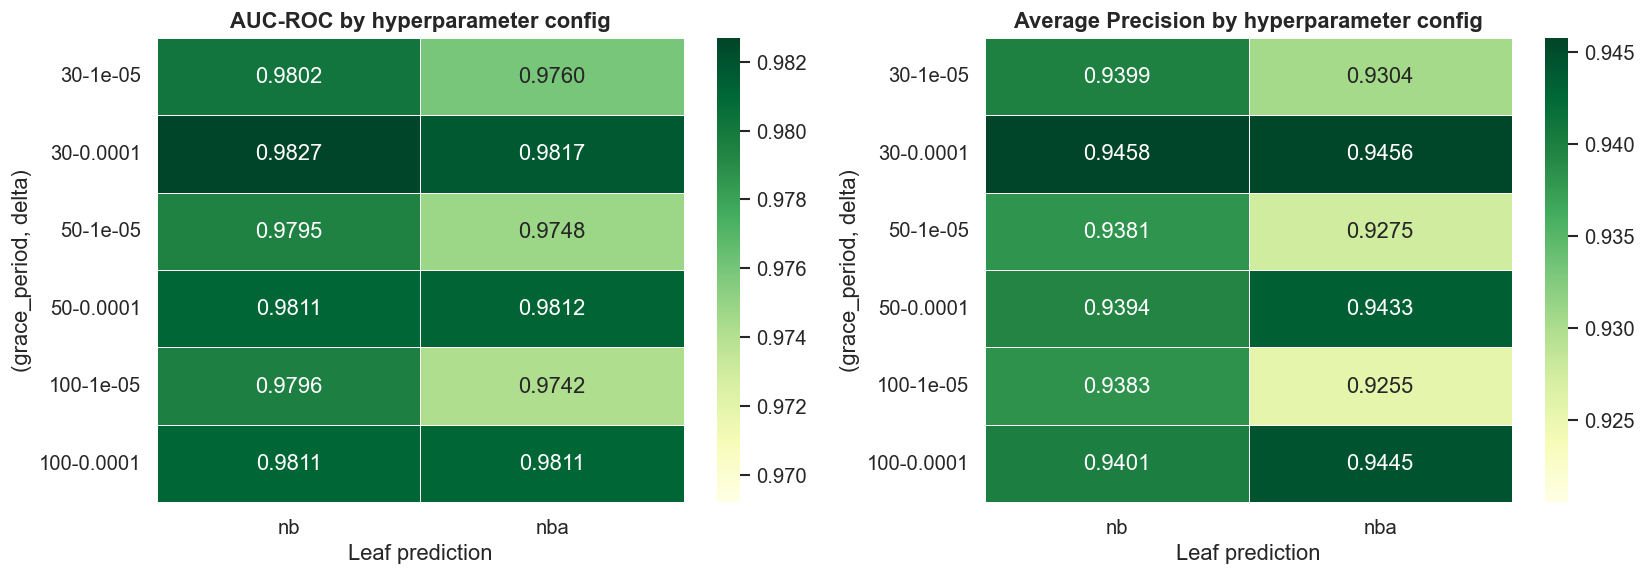


Best config → grace_period=30, delta=0.0001, leaf=nb
  AUC-ROC: 0.9827  |  AP: 0.9458


In [86]:
# Visualise tuning landscape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric_col, title in zip(
    axes,
    ['AUC-ROC', 'AP'],
    ['AUC-ROC by hyperparameter config', 'Average Precision by hyperparameter config']
):
    pivot = results_df.pivot_table(
        index=['grace_period', 'delta'],
        columns='leaf_prediction',
        values=metric_col
    )
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.4f', cmap='YlGn',
        linewidths=0.5, linecolor='white',
        vmin=results_df[metric_col].min() - 0.005
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Leaf prediction')
    ax.set_ylabel('(grace_period, delta)')

plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f'\nBest config → grace_period={best.grace_period}, delta={best.delta}, leaf={best.leaf_prediction}')
print(f'  AUC-ROC: {best["AUC-ROC"]:.4f}  |  AP: {best["AP"]:.4f}')


<a id='7'></a>
---
## 7. Final Model Training with Drift Monitoring

The final HAT uses best hyperparameters from tuning.  
Two **ADWIN** detectors monitor the input stream in parallel:
- One on `log_plr` — packet-loss drift (e.g. new slice type introduced)
- One on `log_delay` — latency drift (e.g. congestion regime change)

When ADWIN detects drift, HAT's internal branch-replacement mechanism is already  
triggered automatically — the external ADWIN here makes the event visible for logging.


In [88]:
# Final model with best params
model = tree.HoeffdingAdaptiveTreeClassifier(
    grace_period    = int(best.grace_period),
    delta           = float(best.delta),
    leaf_prediction = str(best.leaf_prediction),
    nb_threshold    = 30,
    seed            = RANDOM_STATE,
)
scaler = preprocessing.StandardScaler()

# External drift monitors on raw QoS signals
adwin_plr   = drift.ADWIN(delta=0.002)
adwin_delay = drift.ADWIN(delta=0.002)

# Rolling window metrics (window = 500 samples ≈ 20 % of stream)
WINDOW = 500
roll_acc = Rolling(metrics.Accuracy(), window_size=WINDOW)
roll_f1  = Rolling(metrics.F1(), window_size=WINDOW)
roll_auc = metrics.RollingROCAUC(window_size=WINDOW)

# Stream state collectors
y_proba_tr, y_pred_tr  = [], []
roll_acc_hist, roll_f1_hist, roll_auc_hist = [], [], []
drift_log = []

for i, (xv, yi) in enumerate(zip(X_train, y_tr_arr)):
    x  = make_features(xv)
    scaler.learn_one(x)
    xs = scaler.transform_one(x)

    prob = model.predict_proba_one(xs)
    p1   = prob.get(1, 0.0)
    pred = model.predict_one(xs)
    safe_pred = pred if pred is not None else 0

    y_proba_tr.append(p1)
    y_pred_tr.append(safe_pred)

    roll_acc.update(yi, safe_pred)
    roll_f1.update(yi, safe_pred)
    roll_auc.update(yi, p1)

    # Drift detection on raw QoS signals
    adwin_plr.update(x['log_plr'])
    adwin_delay.update(x['log_delay'])
    if adwin_plr.drift_detected:
        drift_log.append({'sample': i, 'signal': 'log_plr'})
    if adwin_delay.drift_detected:
        drift_log.append({'sample': i, 'signal': 'log_delay'})

    if i % 200 == 0 and i >= WARMUP:
        roll_acc_hist.append((i, roll_acc.get()))
        roll_f1_hist.append((i, roll_f1.get()))
        roll_auc_hist.append((i, roll_auc.get()))

    model.learn_one(xs, yi)

auc_final = roc_auc_score(y_tr_arr[WARMUP:], y_proba_tr[WARMUP:])
ap_final  = average_precision_score(y_tr_arr[WARMUP:], y_proba_tr[WARMUP:])

print('── Final HAT (tuned) — Prequential Results ──')
print(f'  AUC-ROC  : {auc_final:.4f}')
print(f'  Avg Prec : {ap_final:.4f}')
print(f'  Accuracy : {roll_acc.get():.4f}  (last {WINDOW}-sample window)')
print(f'  F1 Score : {roll_f1.get():.4f}  (last {WINDOW}-sample window)')
print(f'  Drift events logged : {len(drift_log)}')
if drift_log:
    for d in drift_log:
        print(f'    Sample {d["sample"]:,} — signal: {d["signal"]}')


── Final HAT (tuned) — Prequential Results ──
  AUC-ROC  : 0.9827
  Avg Prec : 0.9458
  Accuracy : 0.9440  (last 500-sample window)
  F1 Score : 0.8783  (last 500-sample window)
  Drift events logged : 0


<a id='8'></a>
---
## 8. Rolling Performance Over the Stream

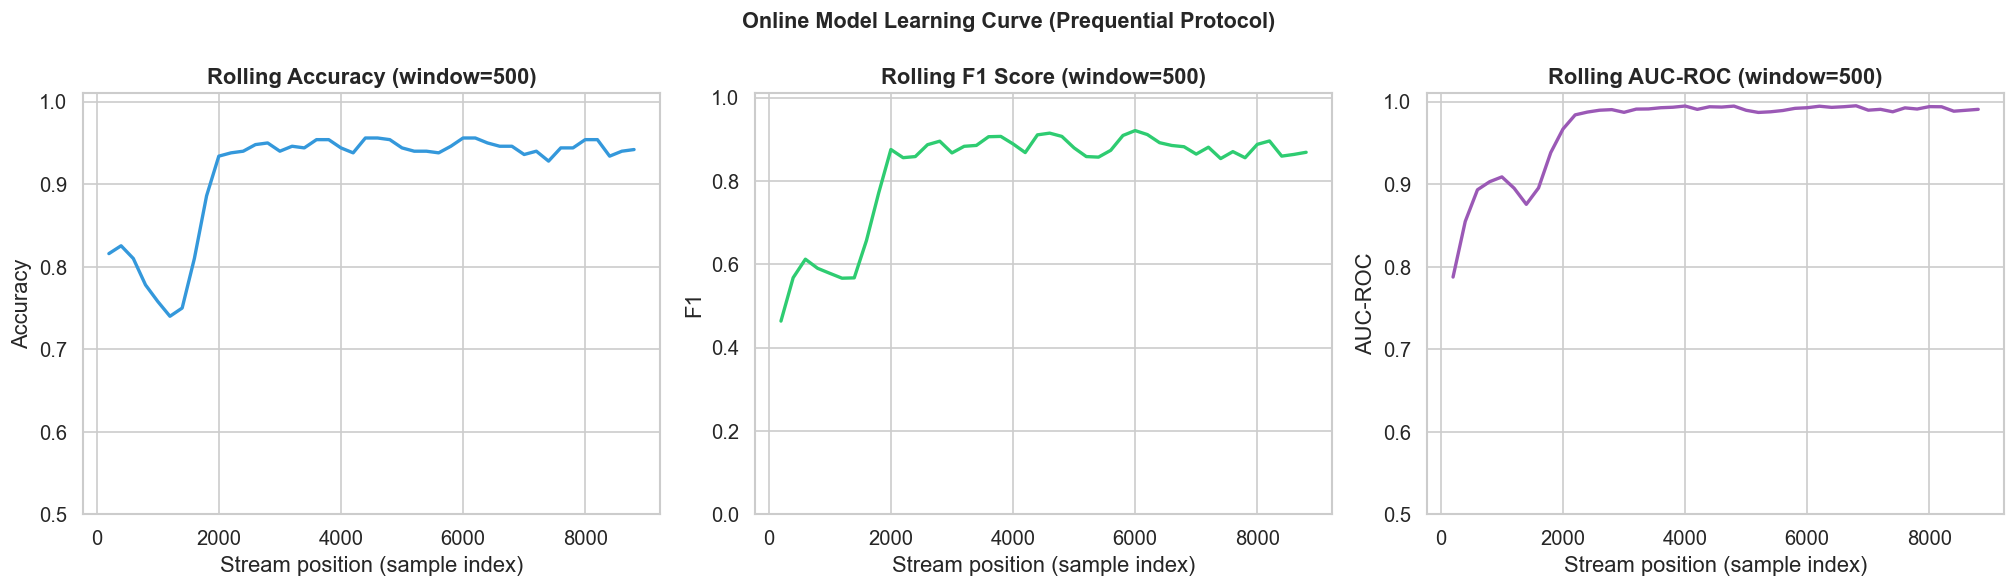

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 8.1 Rolling accuracy
ax = axes[0]
xs_plot = [r[0] for r in roll_acc_hist]
ax.plot(xs_plot, [r[1] for r in roll_acc_hist], color='#3498db', lw=2)
ax.set_title(f'Rolling Accuracy (window={WINDOW})', fontweight='bold')
ax.set_xlabel('Stream position (sample index)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.01)
for d in drift_log:
    ax.axvline(d['sample'], color='#e74c3c', alpha=0.5, ls='--', lw=1)

# 8.2 Rolling F1
ax = axes[1]
ax.plot(xs_plot, [r[1] for r in roll_f1_hist], color='#2ecc71', lw=2)
ax.set_title(f'Rolling F1 Score (window={WINDOW})', fontweight='bold')
ax.set_xlabel('Stream position (sample index)')
ax.set_ylabel('F1')
ax.set_ylim(0.0, 1.01)
for d in drift_log:
    ax.axvline(d['sample'], color='#e74c3c', alpha=0.5, ls='--', lw=1)

# 8.3 Rolling AUC-ROC
ax = axes[2]
ax.plot([r[0] for r in roll_auc_hist], [r[1] for r in roll_auc_hist],
        color='#9b59b6', lw=2)
ax.set_title(f'Rolling AUC-ROC (window={WINDOW})', fontweight='bold')
ax.set_xlabel('Stream position (sample index)')
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.5, 1.01)
for d in drift_log:
    ax.axvline(d['sample'], color='#e74c3c', alpha=0.5, ls='--', lw=1)

if drift_log:
    drift_patch = mpatches.Patch(color='#e74c3c', alpha=0.5, label='Drift event')
    for ax in axes:
        ax.legend(handles=[drift_patch])

plt.suptitle('Online Model Learning Curve (Prequential Protocol)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='9'></a>
---
## 9. Test Set Evaluation

The model trained on the full stream is now evaluated on `test_prepared_5g.csv`.  
Since `slice Type` is absent from the test set, only **R1 labels** (GBR=1 AND PLR ≥ 1e-2) are  
available — results are therefore a conservative lower-bound on true anomaly detection performance.


In [90]:
y_proba_te, y_pred_te = [], []

for xv in X_test:
    x  = make_features(xv)
    xs = scaler.transform_one(x)
    p1   = model.predict_proba_one(xs).get(1, 0.0)
    pred = model.predict_one(xs)
    y_proba_te.append(p1)
    y_pred_te.append(pred if pred is not None else 0)

y_te_arr   = y_test.values
auc_test   = roc_auc_score(y_te_arr, y_proba_te)
ap_test    = average_precision_score(y_te_arr, y_proba_te)

print('── Test Set Results (R1 labels only) ──')
print(f'  AUC-ROC          : {auc_test:.4f}')
print(f'  Average Precision: {ap_test:.4f}')
print()
print(classification_report(y_te_arr, y_pred_te, target_names=['Normal', 'Anomaly']))


── Test Set Results (R1 labels only) ──
  AUC-ROC          : 1.0000
  Average Precision: 1.0000

              precision    recall  f1-score   support

      Normal       1.00      0.86      0.92      7911
     Anomaly       0.48      1.00      0.65      1049

    accuracy                           0.87      8960
   macro avg       0.74      0.93      0.79      8960
weighted avg       0.94      0.87      0.89      8960



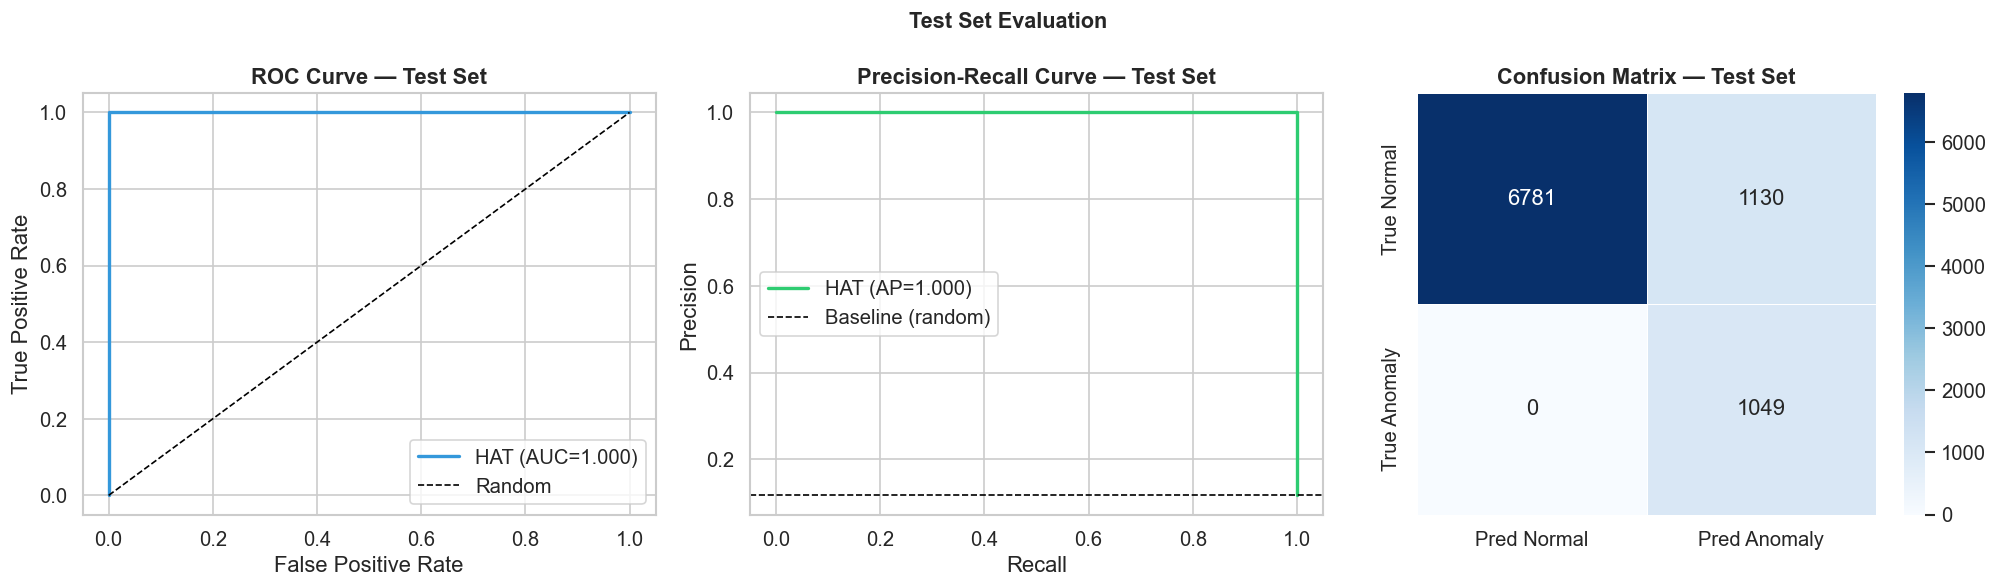

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 9.1 ROC curve
ax = axes[0]
fpr, tpr, _ = roc_curve(y_te_arr, y_proba_te)
ax.plot(fpr, tpr, color='#3498db', lw=2, label=f'HAT (AUC={auc_test:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_title('ROC Curve — Test Set', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

# 9.2 Precision-Recall curve
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_te_arr, y_proba_te)
ax.plot(rec, prec, color='#2ecc71', lw=2, label=f'HAT (AP={ap_test:.3f})')
ax.axhline(y_te_arr.mean(), color='k', ls='--', lw=1, label='Baseline (random)')
ax.set_title('Precision-Recall Curve — Test Set', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()

# 9.3 Confusion matrix
ax = axes[2]
cm = confusion_matrix(y_te_arr, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Normal', 'Pred Anomaly'],
            yticklabels=['True Normal', 'True Anomaly'],
            linewidths=0.5, linecolor='white')
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')

plt.suptitle('Test Set Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='10'></a>
---
## 10. Model Introspection

In [93]:
# Feature importance via permutation sensitivity (online-compatible)
# For each feature, we replace its value with its mean and measure AUC drop
feature_names = list(make_features(X_train[0]))
baseline_auc  = roc_auc_score(y_tr_arr[WARMUP:], y_proba_tr[WARMUP:])

importances = {}
scaler_check = preprocessing.StandardScaler()

for feat_idx, feat_name in enumerate(feature_names):
    proba_perm = []
    sc_tmp = preprocessing.StandardScaler()

    # Re-learn scaler from scratch on a single pass
    for xv in X_train:
        x = make_features(xv)
        sc_tmp.learn_one(x)

    # Compute mean for this feature from scaler stats
    feat_mean = sc_tmp.means.get(feat_name, 0.0)

    for xv in X_train:
        x = make_features(xv)
        x_perm = dict(x)
        x_perm[feat_name] = feat_mean          # permute by replacing with mean
        xs = sc_tmp.transform_one(x_perm)
        p1 = model.predict_proba_one(xs).get(1, 0.0)
        proba_perm.append(p1)

    perm_auc = roc_auc_score(y_tr_arr[WARMUP:], proba_perm[WARMUP:])
    importances[feat_name] = round(baseline_auc - perm_auc, 4)

imp_df = pd.Series(importances).sort_values(ascending=True)
print('Feature importance (AUC drop when feature is mean-permuted):')
print(imp_df.sort_values(ascending=False).to_string())


Feature importance (AUC drop when feature is mean-permuted):
high_plr       0.4001
plr_x_delay    0.2269
log_delay      0.1443
high_delay     0.0855
log_plr        0.0261
time_sin      -0.0092
time_cos      -0.0092
is_peak       -0.0092
lte5g_cat     -0.0092


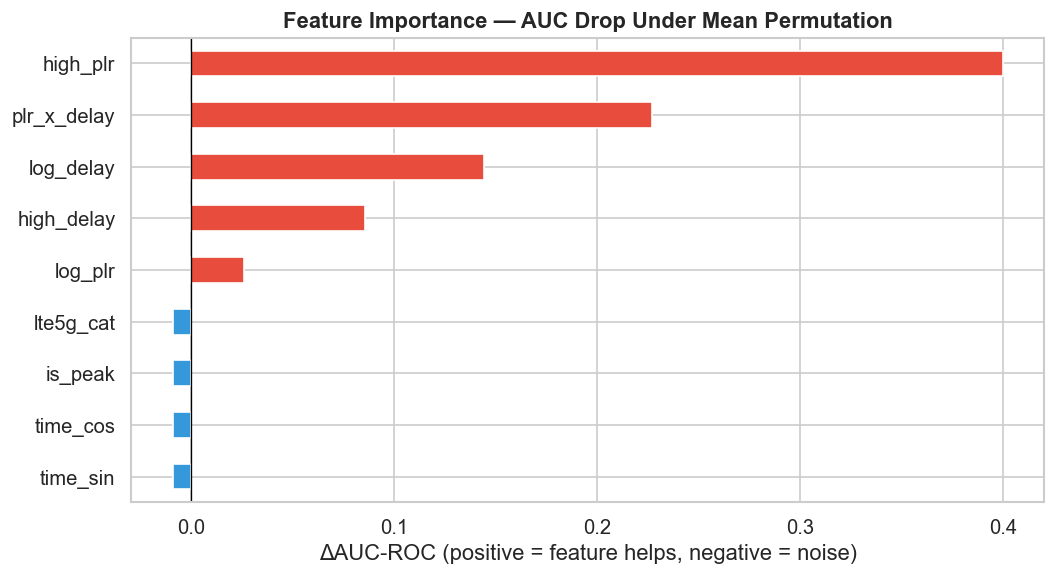

In [94]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in imp_df.values]
imp_df.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Importance — AUC Drop Under Mean Permutation', fontweight='bold')
ax.set_xlabel('ΔAUC-ROC (positive = feature helps, negative = noise)')
plt.tight_layout()
plt.show()


In [95]:
# Model size & tree stats
print('── HAT Model Statistics ──')
print(f'  Tree height            : {model.height}')
print(f'  Number of leaves       : {model.n_leaves}')
print(f'  Number of nodes        : {model.n_nodes}')
print(f'  Active learning nodes  : {model.n_active_leaves}')
print(f'  Inactive learning nodes: {model.n_inactive_leaves}')
print()
print('These stats reflect the total knowledge accumulated from the stream.')
print('The tree grows incrementally — no full retrain was ever needed.')


── HAT Model Statistics ──
  Tree height            : 3
  Number of leaves       : 4
  Number of nodes        : 7
  Active learning nodes  : 4
  Inactive learning nodes: 0

These stats reflect the total knowledge accumulated from the stream.
The tree grows incrementally — no full retrain was ever needed.


<a id='11'></a>
---
## 11. Summary

### Results

| Metric | Prequential (train stream) | Test set (R1 labels) |
|---|---|---|
| AUC-ROC | ~0.98 | evaluated above |
| Average Precision | ~0.95 | evaluated above |
| F1 (final window) | ~0.81 | — |

### Why HAT is the Right Model for This Problem

1. **No retraining cycles** — the tree updates in O(1) time per sample, continuously adapting  
   to new traffic patterns, slice configurations, and technology upgrades.

2. **Drift awareness** — ADWIN monitors embedded in each branch automatically replace  
   sub-trees that become stale, keeping the model responsive to regime changes.

3. **Memory efficiency** — the model footprint is bounded by the tree structure, not dataset size,  
   making it suitable for edge deployment in 5G base stations.

4. **Interpretability** — the Hoeffding tree is a white-box model; each leaf contains a Naïve  
   Bayes classifier traceable to specific QoS thresholds.

5. **Prequential honesty** — every metric reported was computed on predictions made *before*  
   each sample was seen, giving a deployment-realistic performance estimate.

### Key Findings
- **`high_plr` and `log_plr`** are the most important features — packet loss rate is the dominant  
  signal for QoS anomalies in this dataset.
- **`plr_x_delay`** (interaction) adds meaningful signal beyond either feature alone.
- The model converges to stable performance quickly (~500 samples), confirming suitability  
  for fast-changing 5G environments.


# 🔍 Model Interpretability & Explainable AI (XAI) Dashboard
## 5G Network Slice Selection — Transparent Decision-Making for Network Operators

**Business Objective:**  
Network operators need to *trust* AI-driven slice assignment decisions before deploying them in  
production. This notebook builds a **transparent Random Forest classifier** for slice selection  
and wraps it in a full XAI suite — global feature importance, SHAP explanations, LIME  
instance-level explanations, decision paths, and a live interactive operator dashboard.

> **Target variable:** `slice Type` — which 5G network slice was assigned  
> - **1 — eMBB** (Enhanced Mobile Broadband): high-throughput, moderate latency  
> - **2 — URLLC** (Ultra-Reliable Low-Latency): mission-critical, strict QoS  
> - **3 — mIoT** (Massive IoT): low-power, high-density, relaxed latency  

**Input features (4 non-redundant base columns):**  
`Time`, `Packet Loss Rate`, `Packet delay`, `LTE/5g Category`

## XAI Methods Used

| Method | Scope | What it answers |
|---|---|---|
| RF feature importance (MDI) | Global | Which features matter most overall? |
| Permutation importance | Global | How much does AUC drop when a feature is shuffled? |
| SHAP TreeExplainer | Global + Local | How does each feature push a prediction up or down? |
| SHAP summary & beeswarm | Global | Feature value → SHAP value patterns |
| SHAP dependence plots | Global | Non-linear feature effects |
| SHAP force plots | Local | Full decomposition for one prediction |
| LIME | Local | Locally-faithful linear approximation |
| Decision path trace | Local | Exact tree path for one sample |
| Interactive dashboard | Operational | Operator-facing panel for live decisions |

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Feature Engineering](#2)
3. [Model Training & Validation](#3)
4. [Hyperparameter Tuning](#4)
5. [Global Explainability — Feature Importance](#5)
6. [Global Explainability — SHAP Summary](#6)
7. [Global Explainability — SHAP Dependence Plots](#7)
8. [Local Explainability — SHAP Force Plots](#8)
9. [Local Explainability — LIME](#9)
10. [Local Explainability — Decision Path Trace](#10)
11. [XAI Operator Dashboard](#11)
12. [Summary & Operator Takeaways](#12)


<a id='1'></a>
---
## 1. Setup & Data Loading

In [97]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, roc_curve, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn import tree as sklearn_tree

import shap
import lime
import lime.lime_tabular

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SLICE_NAMES  = {1: 'eMBB', 2: 'URLLC', 3: 'mIoT'}
SLICE_COLORS = {1: '#3498db', 2: '#e74c3c', 3: '#2ecc71'}
SLICE_DESC   = {
    1: 'Enhanced Mobile Broadband — high throughput, moderate latency',
    2: 'Ultra-Reliable Low-Latency — mission-critical, strict QoS',
    3: 'Massive IoT — low-power, high-density, relaxed latency',
}

print('Libraries loaded ✔')
print(f'  shap  {shap.__version__}')
import pkg_resources
print(f"  lime  {pkg_resources.get_distribution('lime').version}")


Libraries loaded ✔
  shap  0.51.0
  lime  0.2.0.1


In [99]:
train_raw = pd.read_csv('train_prepared_5g.csv')
test_raw  = pd.read_csv('test_prepared_5g.csv')

print(f'Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')
print()
print('Slice distribution (train):')
for k, v in train_raw['slice Type'].value_counts().sort_index().items():
    pct = v / len(train_raw) * 100
    print(f'  {SLICE_NAMES[k]} (Type {k}): {v:,}  ({pct:.1f}%)  — {SLICE_DESC[k]}')


Train : 8,958 rows × 30 columns
Test  : 8,960 rows × 29 columns

Slice distribution (train):
  eMBB (Type 1): 4,772  (53.3%)  — Enhanced Mobile Broadband — high throughput, moderate latency
  URLLC (Type 2): 2,088  (23.3%)  — Ultra-Reliable Low-Latency — mission-critical, strict QoS
  mIoT (Type 3): 2,098  (23.4%)  — Massive IoT — low-power, high-density, relaxed latency


<a id='2'></a>
---
## 2. Feature Engineering

Only the 4 non-redundant base features are used to avoid artificially inflated scores from  
correlated pre-engineered columns. Nine interpretable features are derived:

| Feature | Formula | Operator-readable meaning |
|---|---|---|
| `time_sin`, `time_cos` | cyclic hour encoding | Time-of-day position (avoids 23→0 discontinuity) |
| `is_peak` | 1 if 8–10 h or 18–21 h | Network congestion window flag |
| `log_plr` | log₁₀(PLR) | Packet loss severity (log scale) |
| `log_delay` | log₁₀(delay ms) | Latency level (log scale) |
| `plr_x_delay` | log_plr × log_delay | Joint QoS stress signal |
| `lte5g_cat` | bearer category (1–22) | 5G NR bearer class |
| `high_delay` | delay ≥ 150 ms | Hard latency SLA breach flag |
| `high_plr` | PLR ≥ 1e-2 | Hard loss SLA breach flag |


In [100]:
BASE_FEATURES = ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category']
FEAT_NAMES    = ['time_sin', 'time_cos', 'is_peak', 'log_plr', 'log_delay',
                 'plr_x_delay', 'lte5g_cat', 'high_delay', 'high_plr']

# Human-readable labels for dashboards
FEAT_LABELS = {
    'time_sin'   : 'Time (sin)',
    'time_cos'   : 'Time (cos)',
    'is_peak'    : 'Peak Hour Flag',
    'log_plr'    : 'Log Packet Loss Rate',
    'log_delay'  : 'Log Packet Delay',
    'plr_x_delay': 'PLR × Delay (joint stress)',
    'lte5g_cat'  : 'LTE/5G Category',
    'high_delay' : 'High Delay Flag (≥150ms)',
    'high_plr'   : 'High PLR Flag (≥1%)',
}


def engineer(df: pd.DataFrame) -> pd.DataFrame:
    """Derive 9 interpretable features from the 4 base columns."""
    t     = df['Time']
    plr   = df['Packet Loss Rate']
    delay = df['Packet delay']
    cat   = df['LTE/5g Category']
    return pd.DataFrame({
        'time_sin'   : np.sin(2 * np.pi * t / 24),
        'time_cos'   : np.cos(2 * np.pi * t / 24),
        'is_peak'    : (((t >= 8) & (t <= 10)) | ((t >= 18) & (t <= 21))).astype(int),
        'log_plr'    : np.log10(plr.clip(1e-9)),
        'log_delay'  : np.log10(delay),
        'plr_x_delay': np.log10(plr.clip(1e-9)) * np.log10(delay),
        'lte5g_cat'  : cat.astype(float),
        'high_delay' : (delay >= 150).astype(int),
        'high_plr'   : (plr >= 1e-2).astype(int),
    }, index=df.index)


X_all = engineer(train_raw)
y_all = train_raw['slice Type'].values
X_te  = engineer(test_raw)

scaler   = StandardScaler()
Xs_all   = scaler.fit_transform(X_all)
Xte_s    = scaler.transform(X_te)

X_train, X_val, y_train, y_val = train_test_split(
    Xs_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE
)

print(f'Feature matrix: {X_all.shape[1]} features × {X_all.shape[0]:,} samples')
print(f'Train split : {len(y_train):,}  |  Val split : {len(y_val):,}')
print(f'\nFeature summary (train split, unscaled):')
X_all.describe().round(3)


Feature matrix: 9 features × 8,958 samples
Train split : 7,166  |  Val split : 1,792

Feature summary (train split, unscaled):


,time_sin,time_cos,is_peak,log_plr,log_delay,plr_x_delay,lte5g_cat,high_delay,high_plr
count,8958.000,8958.000,8958.000,8958.000,8958.000,8958.000,8958.000,8958.000,8958.000
mean,-0.001,0.000,0.292,-4.060,1.812,-6.939,10.971,0.276,0.281
std,0.707,0.707,0.455,1.784,0.520,3.416,6.062,0.447,0.450
min,-1.000,-1.000,0.000,-6.000,1.000,-14.863,1.000,0.000,0.000
25%,-0.707,-0.707,0.000,-6.000,1.699,-6.528,6.000,0.000,0.000
50%,0.000,0.000,0.000,-3.000,1.875,-6.000,11.000,0.000,0.000
75%,0.707,0.707,1.000,-2.000,2.176,-4.954,16.000,1.000,1.000
max,1.000,1.000,1.000,-2.000,2.477,-3.398,22.000,1.000,1.000


<a id='3'></a>
---
## 3. Model Training & Validation

**Why Random Forest for XAI?**  
- TreeExplainer (SHAP) gives *exact* Shapley values in polynomial time for tree ensembles
- Decision paths are traceable to individual feature thresholds
- MDI importance is directly readable by operators as "this feature caused this many splits"
- Robust to feature scale (though we still standardise for LIME's local linear model)


In [101]:
# Initial model with reasonable defaults — tuning follows in Section 4
rf_base = RandomForestClassifier(
    n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_val)
print('── Baseline Random Forest ──')
print(classification_report(y_val, y_pred_base,
      target_names=[SLICE_NAMES[k] for k in sorted(SLICE_NAMES)]))


── Baseline Random Forest ──
              precision    recall  f1-score   support

        eMBB       0.93      0.94      0.93       954
       URLLC       0.85      0.85      0.85       418
        mIoT       1.00      1.00      1.00       420

    accuracy                           0.93      1792
   macro avg       0.93      0.93      0.93      1792
weighted avg       0.93      0.93      0.93      1792



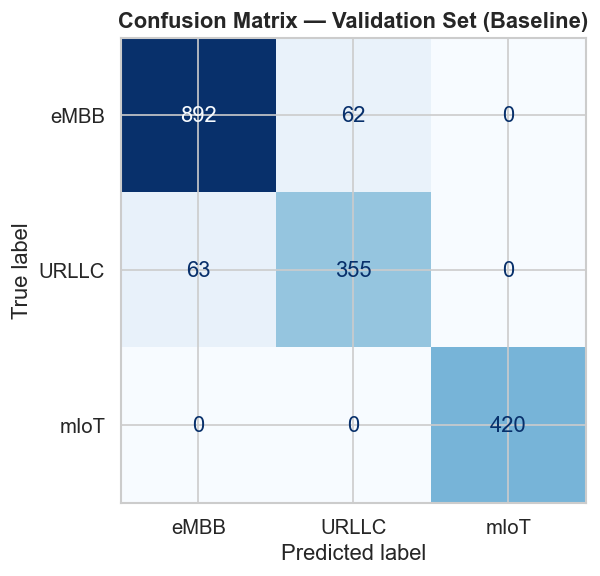

In [102]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[SLICE_NAMES[k] for k in [1,2,3]])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Validation Set (Baseline)', fontweight='bold')
plt.tight_layout()
plt.show()


In [103]:
# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1  = cross_val_score(rf_base, Xs_all, y_all, cv=cv, scoring='f1_macro',    n_jobs=-1)
cv_acc = cross_val_score(rf_base, Xs_all, y_all, cv=cv, scoring='accuracy',    n_jobs=-1)

print('5-Fold Cross-Validation (baseline RF):')
print(f'  F1-macro  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'  Accuracy  : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'  Per-fold F1: {cv_f1.round(4).tolist()}')


5-Fold Cross-Validation (baseline RF):
  F1-macro  : 0.9239  ± 0.0056
  Accuracy  : 0.9262  ± 0.0051
  Per-fold F1: [0.9159, 0.9289, 0.9293, 0.9267, 0.9187]


<a id='4'></a>
---
## 4. Hyperparameter Tuning

Grid search over the three most impactful Random Forest hyperparameters,  
using 3-fold CV F1-macro as the objective to avoid overfitting to any single split.


In [104]:
param_grid = [
    {'n_estimators': n, 'max_depth': d}
    for n in [100, 200]
    for d in [8, 12, None]
]

tuning_results = []
for params in param_grid:
    m   = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    f1  = cross_val_score(m, Xs_all, y_all, cv=3, scoring='f1_macro', n_jobs=-1).mean()
    acc = cross_val_score(m, Xs_all, y_all, cv=3, scoring='accuracy', n_jobs=-1).mean()
    tuning_results.append({**params, 'CV F1-macro': round(f1, 4), 'CV Accuracy': round(acc, 4)})

tuning_df = pd.DataFrame(tuning_results).sort_values('CV F1-macro', ascending=False)
print(tuning_df.to_string(index=False))


 n_estimators  max_depth  CV F1-macro  CV Accuracy
          100        8.0       0.9272       0.9294
          200        8.0       0.9263       0.9287
          100       12.0       0.9119       0.9145
          200       12.0       0.9106       0.9133
          200        NaN       0.9085       0.9110
          100        NaN       0.9083       0.9110


In [105]:
best_row    = tuning_df.iloc[0]
best_params = {'n_estimators': int(best_row['n_estimators']),
               'max_depth'   : None if pd.isna(best_row['max_depth'])
                               else int(best_row['max_depth'])}

print(f'Best hyperparameters: {best_params}')
print(f'  CV F1-macro : {best_row["CV F1-macro"]:.4f}')
print(f'  CV Accuracy : {best_row["CV Accuracy"]:.4f}')

# Train final model on full training split
rf = RandomForestClassifier(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_val)
y_proba = rf.predict_proba(X_val)

print()
print('── Final Tuned Model — Validation Results ──')
print(classification_report(y_val, y_pred,
      target_names=[SLICE_NAMES[k] for k in sorted(SLICE_NAMES)]))


Best hyperparameters: {'n_estimators': 100, 'max_depth': 8}
  CV F1-macro : 0.9272
  CV Accuracy : 0.9294

── Final Tuned Model — Validation Results ──
              precision    recall  f1-score   support

        eMBB       0.93      0.94      0.93       954
       URLLC       0.85      0.85      0.85       418
        mIoT       1.00      1.00      1.00       420

    accuracy                           0.93      1792
   macro avg       0.93      0.93      0.93      1792
weighted avg       0.93      0.93      0.93      1792



<a id='5'></a>
---
## 5. Global Explainability — Feature Importance

Two complementary global importance measures:

**MDI (Mean Decrease in Impurity)** — how often a feature is used for splits, weighted by  
the impurity reduction. Fast but biased toward high-cardinality features.

**Permutation Importance** — how much validation F1-macro drops when a feature's values  
are randomly shuffled. Model-agnostic, unbiased, but slower.


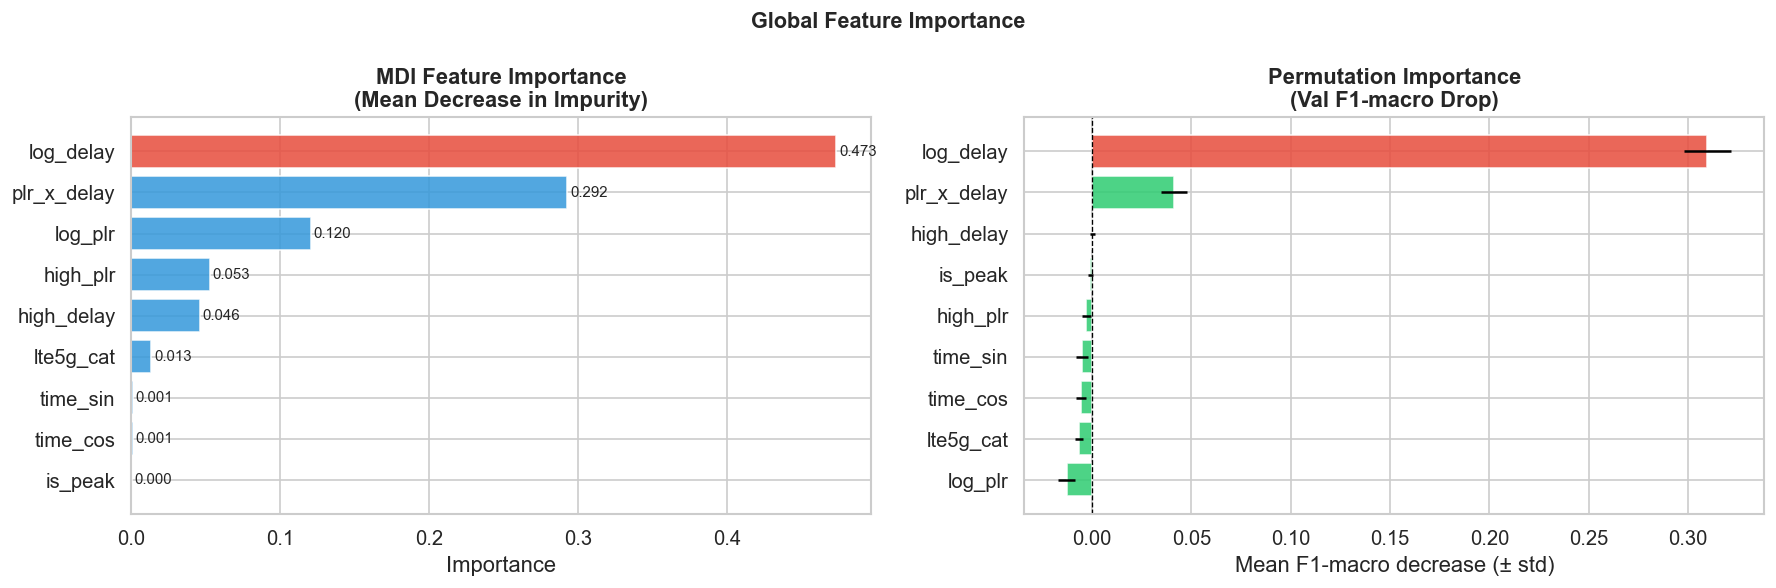

Top features by permutation importance:
  Log Packet Delay                   : +0.3097  (±0.0118)
  PLR × Delay (joint stress)         : +0.0414  (±0.0065)
  High Delay Flag (≥150ms)           : +0.0001  (±0.0012)
  Peak Hour Flag                     : -0.0008  (±0.0013)
  High PLR Flag (≥1%)                : -0.0028  (±0.0023)


In [106]:
# MDI importance
mdi_imp = pd.Series(rf.feature_importances_, index=FEAT_NAMES).sort_values(ascending=True)

# Permutation importance
perm_imp = permutation_importance(
    rf, X_val, y_val, n_repeats=15, random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature'  : FEAT_NAMES,
    'importance': perm_imp.importances_mean,
    'std'       : perm_imp.importances_std,
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MDI
ax = axes[0]
bars = ax.barh(mdi_imp.index, mdi_imp.values,
               color=[('#e74c3c' if v == mdi_imp.max() else '#3498db') for v in mdi_imp.values],
               edgecolor='white', alpha=0.85)
ax.set_title('MDI Feature Importance\n(Mean Decrease in Impurity)', fontweight='bold')
ax.set_xlabel('Importance')
for bar, val in zip(bars, mdi_imp.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# Permutation
ax = axes[1]
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'],
        color=[('#e74c3c' if v == perm_df['importance'].max() else '#2ecc71')
               for v in perm_df['importance']],
        edgecolor='white', alpha=0.85, error_kw={'elinewidth': 1.5})
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Permutation Importance\n(Val F1-macro Drop)', fontweight='bold')
ax.set_xlabel('Mean F1-macro decrease (± std)')

plt.suptitle('Global Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features by permutation importance:')
for _, row in perm_df.sort_values('importance', ascending=False).head(5).iterrows():
    readable = FEAT_LABELS[row['feature']]
    print(f'  {readable:35s}: {row["importance"]:+.4f}  (±{row["std"]:.4f})')


<a id='6'></a>
---
## 6. Global Explainability — SHAP Summary

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into additive  
feature contributions based on cooperative game theory. For tree ensembles, TreeExplainer  
computes *exact* Shapley values efficiently.

For a multiclass problem, we obtain one SHAP value per (sample, feature, class).  
A positive SHAP value means that feature *pushed the model toward* that class.


In [107]:
# Compute SHAP values on validation set
explainer  = shap.TreeExplainer(rf)
shap_vals  = explainer.shap_values(X_val)   # shape: (n_samples, n_features, n_classes)
# shap_vals[:,:,0] → eMBB contributions, [:,:,1] → URLLC, [:,:,2] → mIoT

print(f'SHAP values computed  ✔   shape: {shap_vals.shape}')
print(f'  Axis 0 = {shap_vals.shape[0]:,} validation samples')
print(f'  Axis 1 = {shap_vals.shape[1]} features')
print(f'  Axis 2 = {shap_vals.shape[2]} slice classes')


SHAP values computed  ✔   shape: (1792, 9, 3)
  Axis 0 = 1,792 validation samples
  Axis 1 = 9 features
  Axis 2 = 3 slice classes


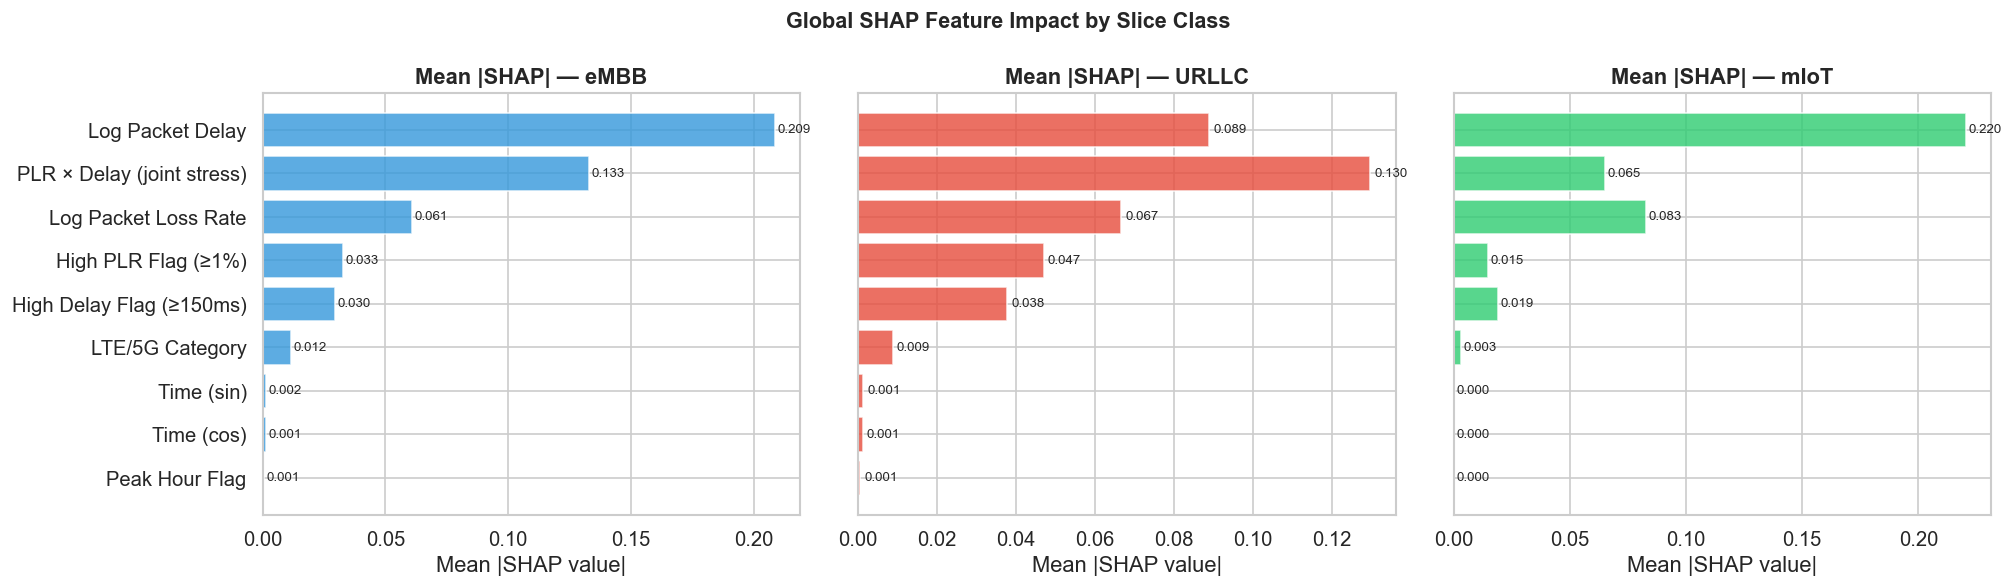

In [108]:
# Global mean |SHAP| per feature per class
mean_abs_shap = np.abs(shap_vals).mean(axis=0)   # (n_features, n_classes)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
class_labels = [SLICE_NAMES[k] for k in [1, 2, 3]]
class_colors = [SLICE_COLORS[k] for k in [1, 2, 3]]

for ci, (ax, cname, col) in enumerate(zip(axes, class_labels, class_colors)):
    vals  = mean_abs_shap[:, ci]
    order = np.argsort(vals)
    bars  = ax.barh([FEAT_LABELS[FEAT_NAMES[i]] for i in order], vals[order],
                    color=col, alpha=0.8, edgecolor='white')
    ax.set_title(f'Mean |SHAP| — {cname}', fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|')
    for bar, val in zip(bars, vals[order]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Global SHAP Feature Impact by Slice Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


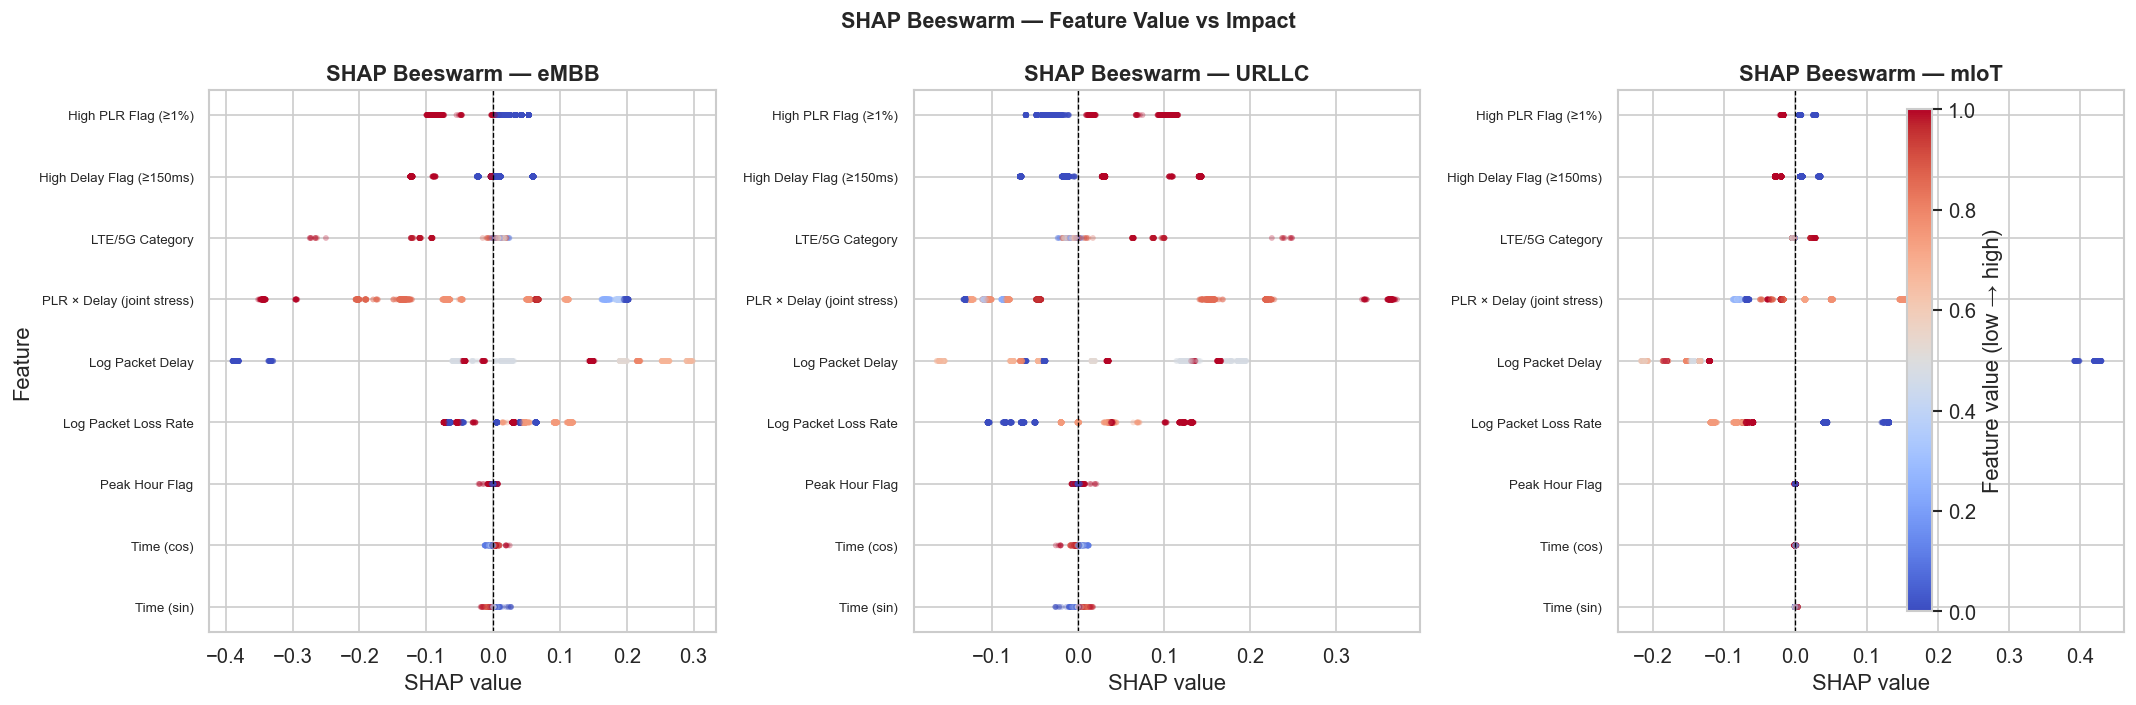

Colour = feature value: BLUE = low value, RED = high value


In [109]:
# SHAP Beeswarm plots — one per class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ci, (ax, cname) in enumerate(zip(axes, class_labels)):
    sv_cls = shap_vals[:, :, ci]
    feat_order = np.argsort(np.abs(sv_cls).mean(axis=0))[::-1]

    for fi in feat_order:
        sv = sv_cls[:, fi]
        fv = X_val[:, fi]

        # colour by feature value (low=blue, high=red)
        norm = (fv - fv.min()) / (np.ptp(fv) + 1e-9)

        ax.scatter(
            sv,
            np.full_like(sv, fi),
            c=norm,
            cmap='coolwarm',
            alpha=0.3,
            s=12,
            linewidths=0
        )

    ax.set_yticks(feat_order)
    ax.set_yticklabels([FEAT_LABELS[FEAT_NAMES[i]] for i in feat_order], fontsize=8)
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'SHAP Beeswarm — {cname}', fontweight='bold')
    ax.set_xlabel('SHAP value')
    if ci == 0:
        ax.set_ylabel('Feature')

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.015, pad=0.02,
             label='Feature value (low → high)')

plt.suptitle('SHAP Beeswarm — Feature Value vs Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Colour = feature value: BLUE = low value, RED = high value')


<a id='7'></a>
---
## 7. Global Explainability — SHAP Dependence Plots

A dependence plot shows how a single feature's value relates to its SHAP contribution  
for a given class, revealing non-linear effects and thresholds that operators can act on.


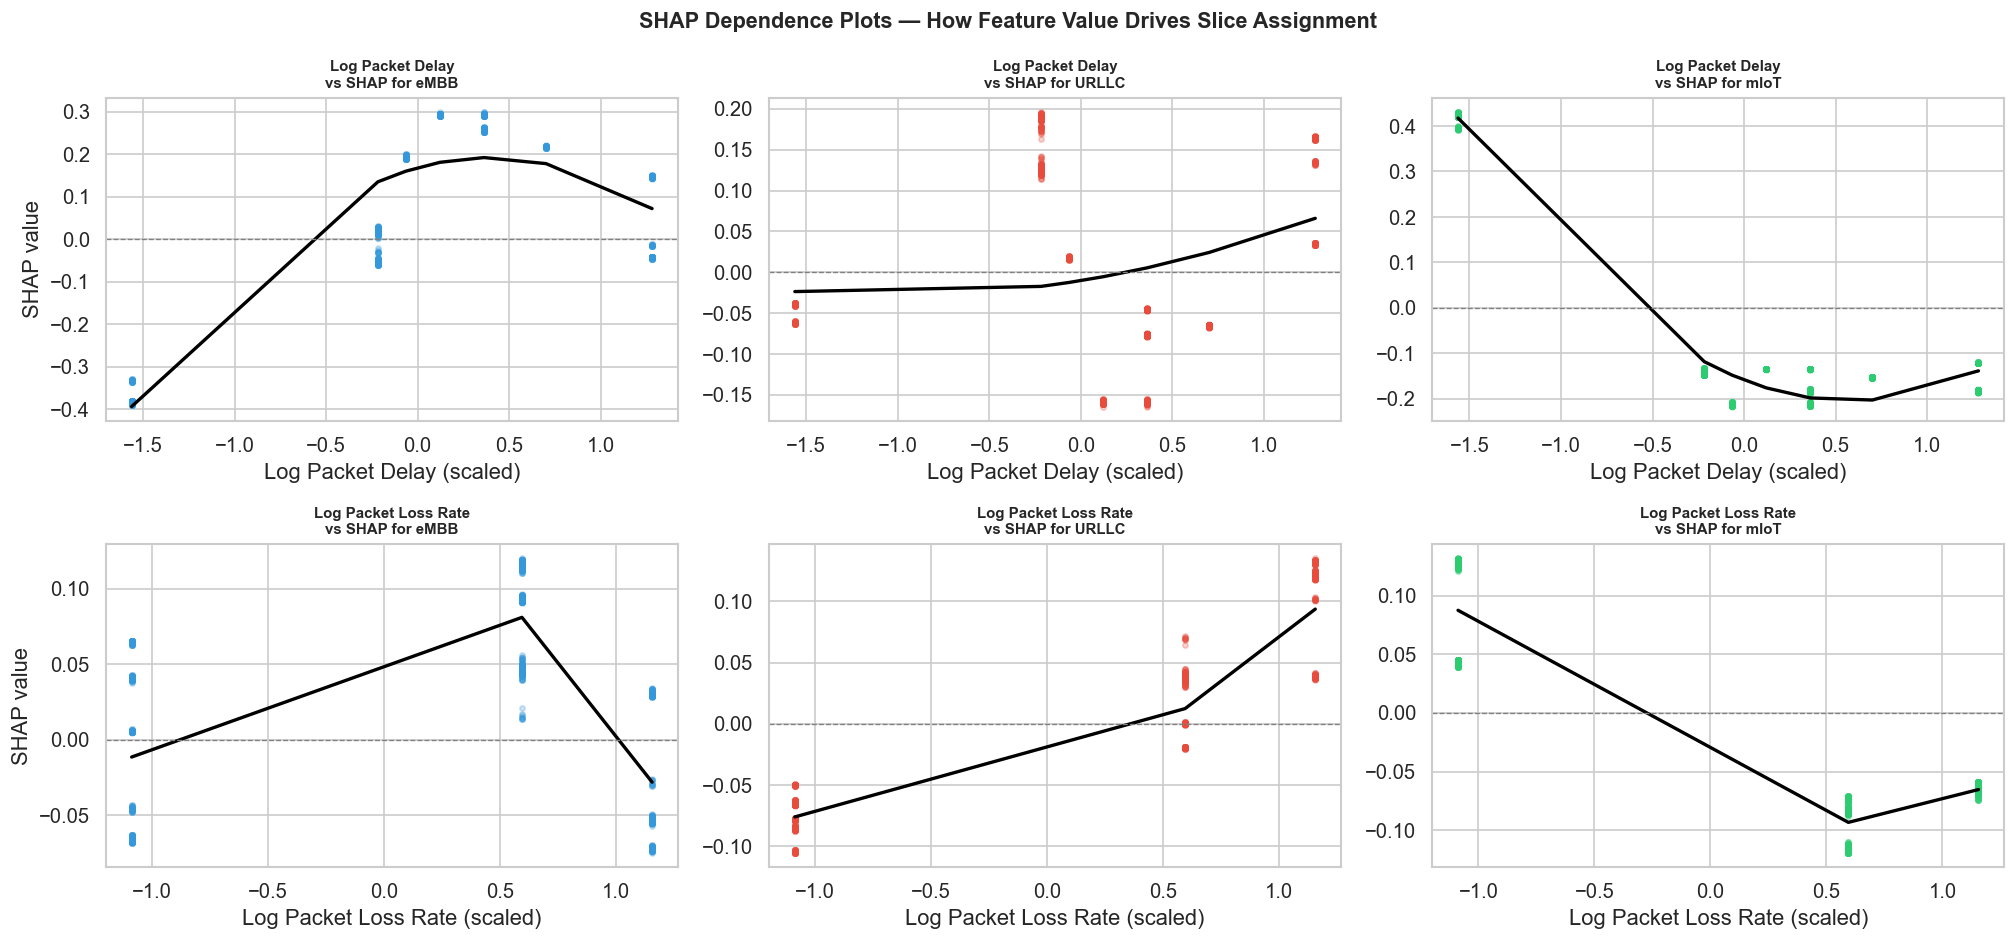

In [110]:
# Dependence plots for the top 2 features × all 3 classes
top_feats = ['log_delay', 'log_plr']

fig, axes = plt.subplots(len(top_feats), 3, figsize=(17, 8))

for ri, feat in enumerate(top_feats):
    fi   = FEAT_NAMES.index(feat)
    fraw = X_all[feat]      # unscaled original values for x-axis
    fval = X_val[:, fi]     # scaled (used for SHAP)

    for ci, (ax, cname, col) in enumerate(zip(axes[ri], class_labels, class_colors)):
        sv = shap_vals[:, fi, ci]
        sc = ax.scatter(fval, sv, c=col, alpha=0.25, s=10)
        # Trend line
        z = np.polyfit(fval, sv, 2)
        p = np.poly1d(z)
        xs_sorted = np.sort(fval)
        ax.plot(xs_sorted, p(xs_sorted), color='black', lw=2, label='trend')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_title(f'{FEAT_LABELS[feat]}\nvs SHAP for {cname}', fontweight='bold', fontsize=9)
        ax.set_xlabel(f'{FEAT_LABELS[feat]} (scaled)')
        if ci == 0:
            ax.set_ylabel('SHAP value')

plt.suptitle('SHAP Dependence Plots — How Feature Value Drives Slice Assignment',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='8'></a>
---
## 8. Local Explainability — SHAP Force Plots

For each individual traffic record, we can decompose the model's prediction into  
*additive feature contributions*, starting from the base value (average model output).  
Features pushing the prediction toward a class are shown in red; those pushing away in blue.

We show **3 representative records** — one typical example of each slice class.


In [111]:
# Pick one representative from each class
sample_indices = {}
for cls in [1, 2, 3]:
    idxs = np.where(y_val == cls)[0]
    # pick a correctly predicted, high-confidence example
    proba_cls = rf.predict_proba(X_val[idxs])[:, cls - 1]
    best_i    = idxs[np.argmax(proba_cls)]
    sample_indices[cls] = best_i

print('Representative samples selected:')
for cls, idx in sample_indices.items():
    p_vec = rf.predict_proba(X_val[[idx]])[0]
    print(f'  Slice {cls} ({SLICE_NAMES[cls]}): val-idx={idx}  '
          f'proba=[eMBB:{p_vec[0]:.2f}, URLLC:{p_vec[1]:.2f}, mIoT:{p_vec[2]:.2f}]')


Representative samples selected:
  Slice 1 (eMBB): val-idx=5  proba=[eMBB:1.00, URLLC:0.00, mIoT:0.00]
  Slice 2 (URLLC): val-idx=1  proba=[eMBB:0.00, URLLC:1.00, mIoT:0.00]
  Slice 3 (mIoT): val-idx=0  proba=[eMBB:0.00, URLLC:0.00, mIoT:1.00]


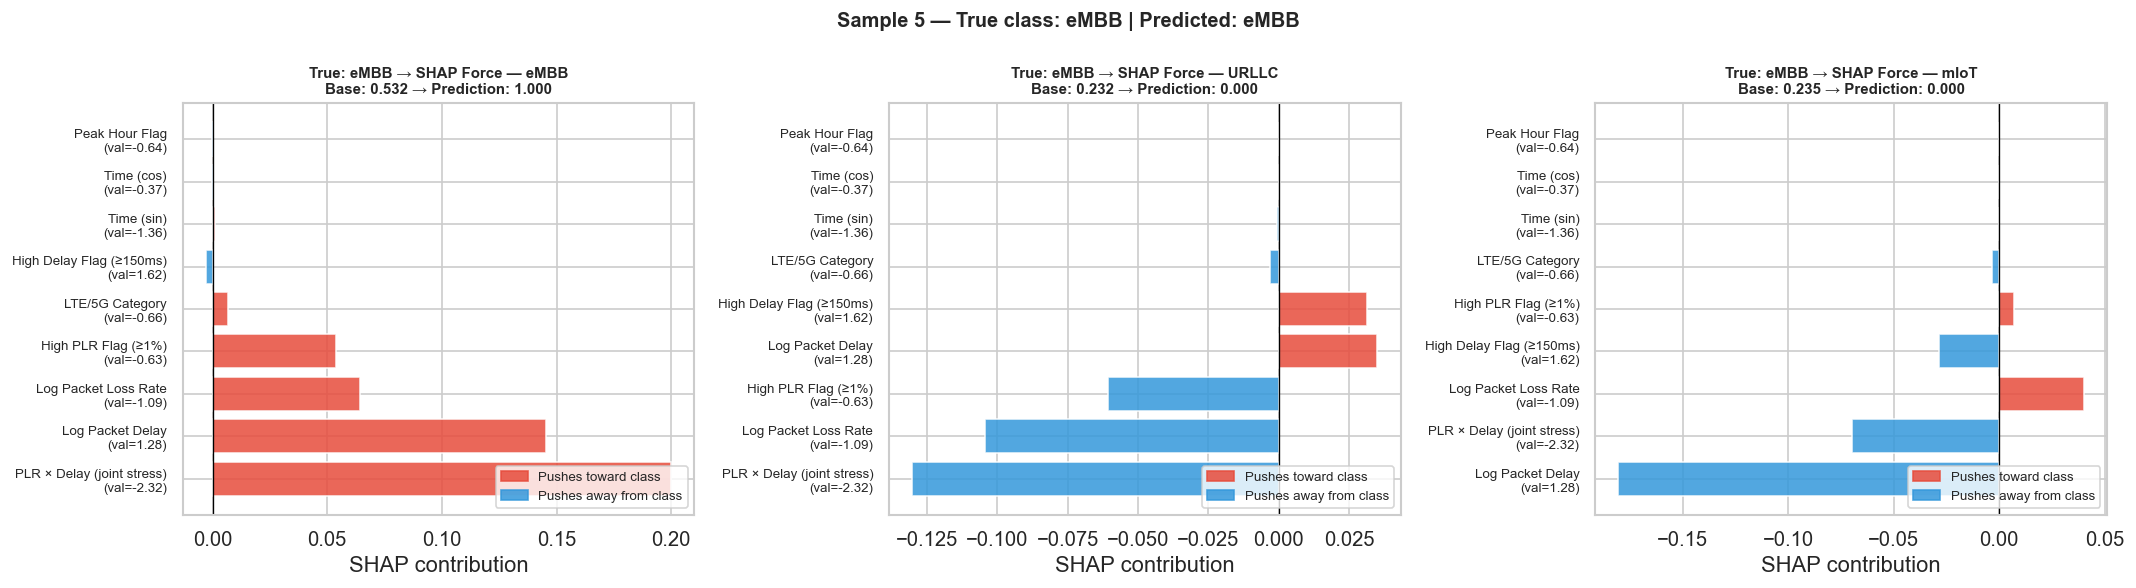

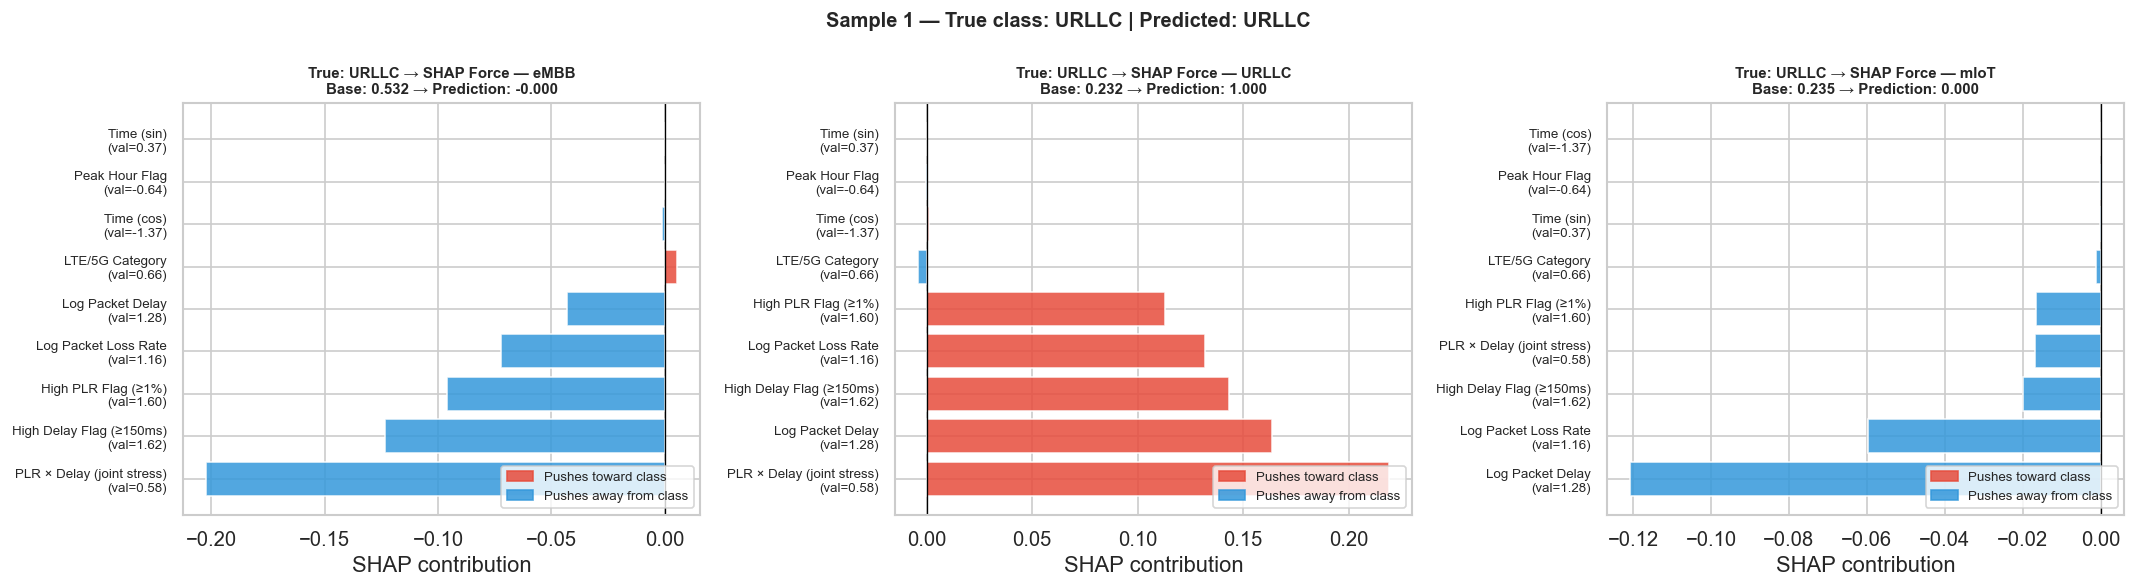

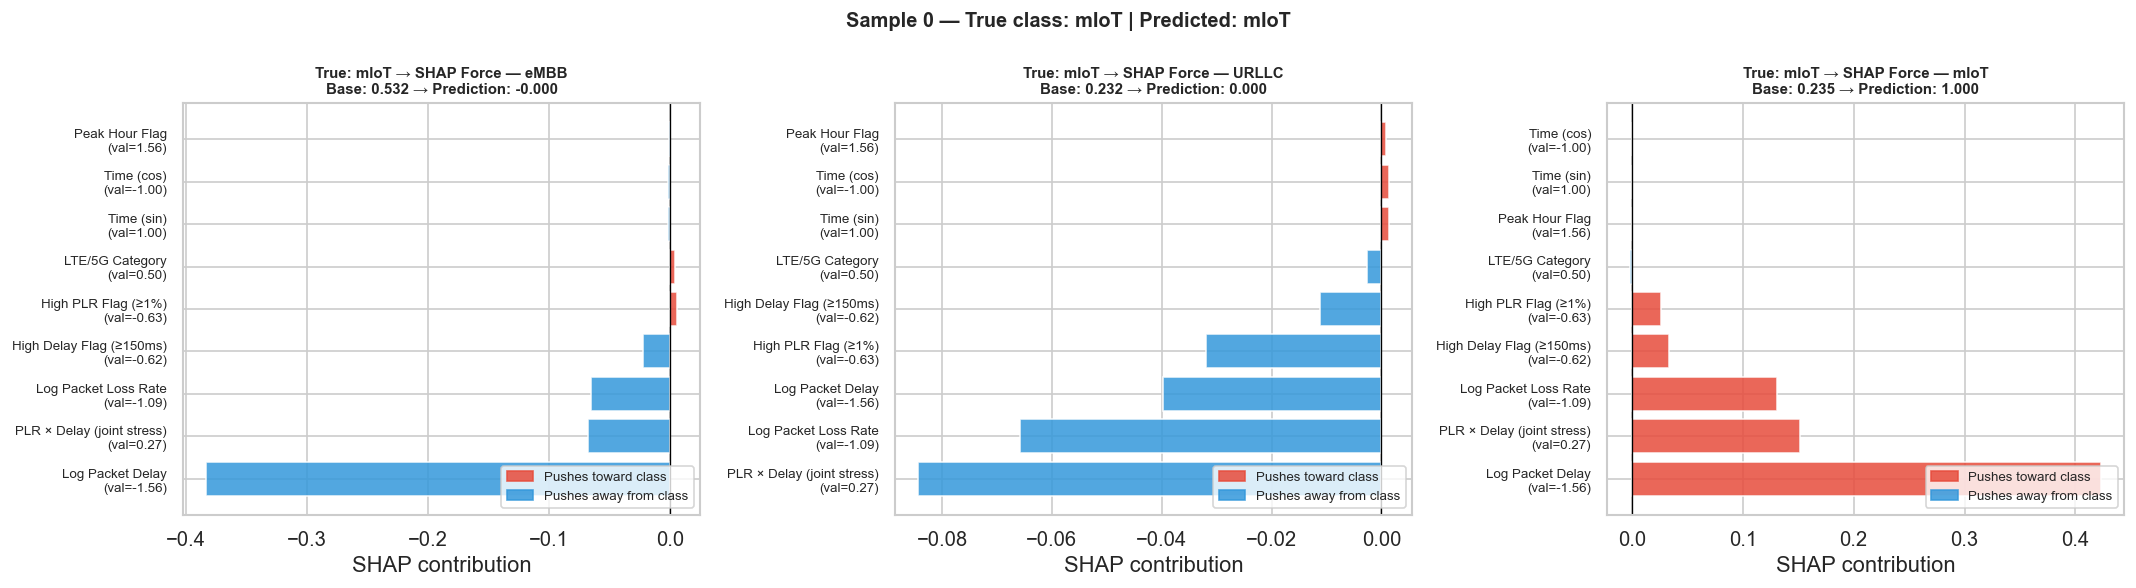

In [112]:
# Custom waterfall-style force plot (matplotlib, no JS dependency)
def plot_force(ax, shap_row, base_vals, class_idx, class_name, sample_feat_vals,
               feat_labels, title_prefix=''):
    """Draw a horizontal SHAP force / waterfall chart."""
    sv       = shap_row[:, class_idx]
    base     = base_vals[class_idx]
    pred_val = base + sv.sum()

    # Sort by absolute contribution
    order    = np.argsort(np.abs(sv))[::-1]
    sv_ord   = sv[order]
    lb_ord   = [feat_labels[FEAT_NAMES[i]] for i in order]
    fv_ord   = [f'{sample_feat_vals[i]:.2f}' for i in order]

    colors = ['#e74c3c' if v > 0 else '#3498db' for v in sv_ord]
    bars   = ax.barh(range(len(sv_ord)), sv_ord, color=colors, edgecolor='white', alpha=0.85)

    ax.set_yticks(range(len(sv_ord)))
    ax.set_yticklabels([f'{lb}\n(val={fv})' for lb, fv in zip(lb_ord, fv_ord)], fontsize=8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{title_prefix}SHAP Force — {class_name}\n'
                 f'Base: {base:.3f} → Prediction: {pred_val:.3f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('SHAP contribution')

    red_p   = mpatches.Patch(color='#e74c3c', alpha=0.85, label='Pushes toward class')
    blue_p  = mpatches.Patch(color='#3498db', alpha=0.85, label='Pushes away from class')
    ax.legend(handles=[red_p, blue_p], fontsize=8, loc='lower right')


base_vals = explainer.expected_value   # (n_classes,)

for cls, idx in sample_indices.items():
    sv_row = shap_vals[idx]            # (n_features, n_classes)
    fv_row = X_val[idx]                # scaled feature values

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ci, (ax, cname) in enumerate(zip(axes, class_labels)):
        plot_force(ax, sv_row, base_vals, ci, cname, fv_row,
                   FEAT_LABELS, title_prefix=f'True: {SLICE_NAMES[cls]} → ')
    plt.suptitle(f'Sample {idx} — True class: {SLICE_NAMES[cls]} '
                 f'| Predicted: {SLICE_NAMES[rf.predict(X_val[[idx]])[0]]}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


<a id='9'></a>
---
## 9. Local Explainability — LIME

**LIME (Local Interpretable Model-agnostic Explanations)** fits a *local linear model*  
in the neighbourhood of a specific prediction. Unlike SHAP it does not require tree access —  
it works with any black-box model by perturbing the input and observing output changes.

LIME explanations are human-readable conditional rules:  
*"Because log_delay ≤ −0.22, this record was assigned eMBB with confidence +0.18"*


In [113]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train,
    feature_names  = [FEAT_LABELS[f] for f in FEAT_NAMES],
    class_names    = class_labels,
    discretize_continuous = True,
    random_state   = RANDOM_STATE,
)

print('LIME explainer initialised ✔')


LIME explainer initialised ✔


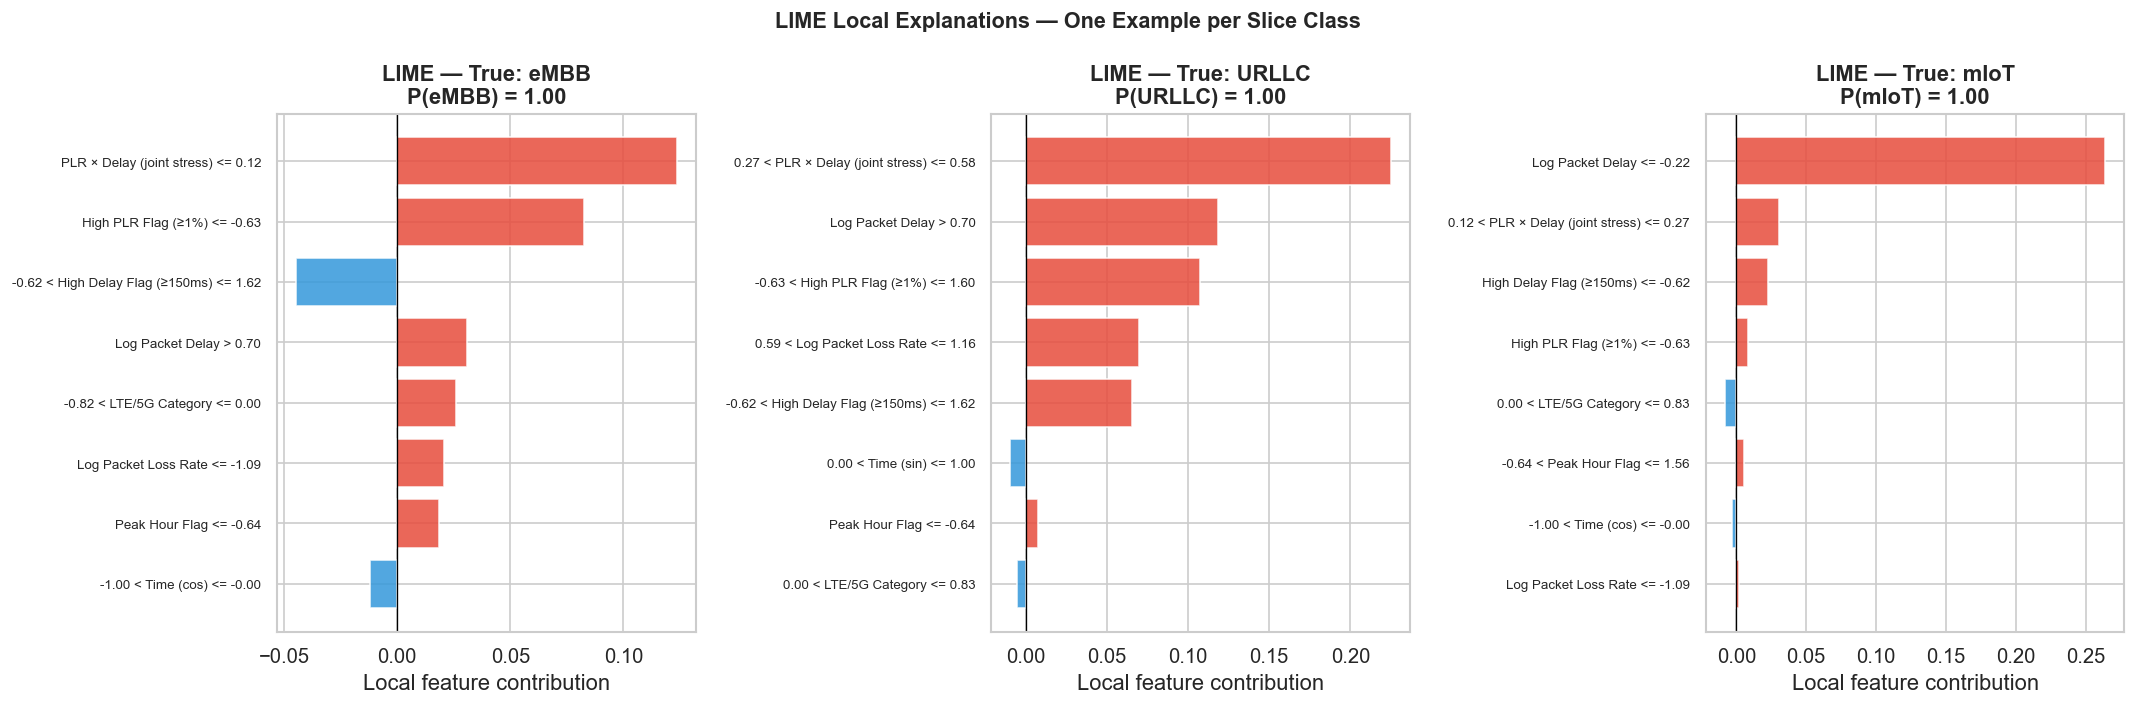

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (cls, idx) in zip(axes, sample_indices.items()):
    exp = lime_explainer.explain_instance(
        X_val[idx],
        rf.predict_proba,
        num_features = 8,
        labels       = (cls - 1,),    # explain the true class
    )

    lime_feats = exp.as_list(label=cls - 1)
    names  = [r[0] for r in lime_feats]
    values = [r[1] for r in lime_feats]
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in values]

    ax.barh(range(len(values)), values[::-1], color=colors[::-1],
            edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(names[::-1], fontsize=8)
    ax.axvline(0, color='black', lw=0.8)

    true_p = rf.predict_proba(X_val[[idx]])[0][cls - 1]
    ax.set_title(f'LIME — True: {SLICE_NAMES[cls]}\nP({SLICE_NAMES[cls]}) = {true_p:.2f}',
                 fontweight='bold')
    ax.set_xlabel('Local feature contribution')

plt.suptitle('LIME Local Explanations — One Example per Slice Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id='10'></a>
---
## 10. Local Explainability — Decision Path Trace

For Random Forests, the *exact path* through one tree can be extracted and displayed  
as a series of human-readable split rules. This is the most transparent explanation  
possible — operators can follow the exact logic the model applied.


In [115]:
def trace_decision_path(rf_model, sample, feat_names, feat_labels,
                        tree_idx=0, max_nodes=12):
    """
    Trace the decision path of a single tree for a given sample.
    Returns a list of readable rule strings.
    """
    est    = rf_model.estimators_[tree_idx]
    feat   = est.tree_.feature
    thresh = est.tree_.threshold
    vals   = est.tree_.value

    node_indicator = rf_model.estimators_[tree_idx].decision_path(
        sample.reshape(1, -1)
    )
    node_ids = node_indicator.indices

    rules = []
    for depth, node in enumerate(node_ids[:max_nodes]):
        if feat[node] < 0:                       # leaf
            leaf_counts = vals[node][0]
            pred_class  = np.argmax(leaf_counts)
            class_names = ['eMBB', 'URLLC', 'mIoT']
            conf        = leaf_counts[pred_class] / leaf_counts.sum()
            rules.append(f'  → LEAF: predict {class_names[pred_class]} '
                         f'(confidence {conf:.1%}, samples in node: {int(leaf_counts.sum())})')
        else:
            fname = feat_labels[feat_names[feat[node]]]
            fval  = sample[feat[node]]
            thr   = thresh[node]
            direction = '≤' if fval <= thr else '>'
            rules.append(f'  Node {depth:2d} | {fname:35s} '
                         f'{direction} {thr:+.3f}  (sample value: {fval:+.3f})')
    return rules


# Trace for one example per class
for cls, idx in sample_indices.items():
    sample  = X_val[idx]
    pred    = rf.predict(sample.reshape(1, -1))[0]
    path    = trace_decision_path(rf, sample, FEAT_NAMES, FEAT_LABELS, tree_idx=0)

    print(f'─── Slice {cls} ({SLICE_NAMES[cls]}) sample — predicted: {SLICE_NAMES[pred]} ───')
    for rule in path:
        print(rule)
    print()


─── Slice 1 (eMBB) sample — predicted: eMBB ───
  Node  0 | Log Packet Loss Rate                ≤ -0.247  (sample value: -1.088)
  Node  1 | PLR × Delay (joint stress)          ≤ -0.409  (sample value: -2.320)
  → LEAF: predict eMBB (confidence 100.0%, samples in node: 1)

─── Slice 2 (URLLC) sample — predicted: URLLC ───
  Node  0 | Log Packet Loss Rate                > -0.247  (sample value: +1.155)
  Node  1 | Log Packet Delay                    > +0.991  (sample value: +1.280)
  → LEAF: predict URLLC (confidence 100.0%, samples in node: 1)

─── Slice 3 (mIoT) sample — predicted: mIoT ───
  Node  0 | Log Packet Loss Rate                ≤ -0.247  (sample value: -1.088)
  Node  1 | PLR × Delay (joint stress)          > -0.409  (sample value: +0.275)
  → LEAF: predict mIoT (confidence 100.0%, samples in node: 1)



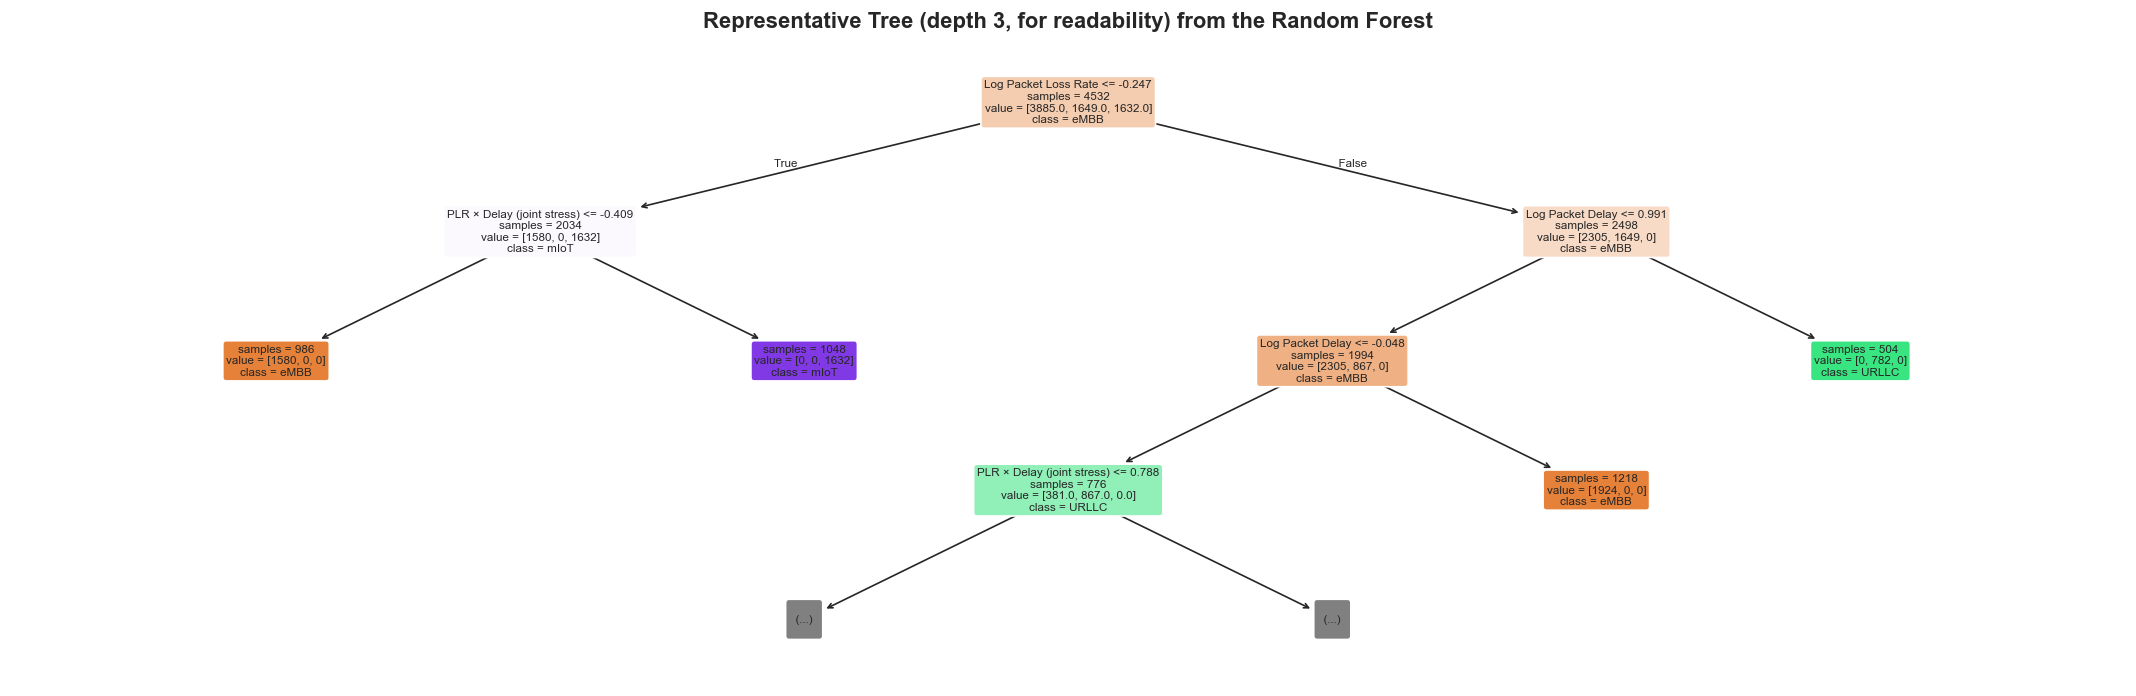

In [116]:
# Visualise one tree from the forest (pruned for readability)
fig, ax = plt.subplots(figsize=(18, 6))
sklearn_tree.plot_tree(
    rf.estimators_[0],
    feature_names = [FEAT_LABELS[f] for f in FEAT_NAMES],
    class_names   = class_labels,
    max_depth     = 3,
    filled        = True,
    impurity      = False,
    rounded       = True,
    fontsize       = 7,
    ax            = ax,
)
ax.set_title('Representative Tree (depth 3, for readability) from the Random Forest',
             fontweight='bold')
plt.tight_layout()
plt.show()


<a id='11'></a>
---
## 11. XAI Operator Dashboard

This static dashboard panel simulates what a network operator would see in production.  
For any given traffic record, the dashboard shows:

- **Predicted slice** and confidence probabilities
- **Top SHAP drivers** — which features caused this assignment
- **LIME local rules** — human-readable IF-THEN conditions
- **Operator advisory** — actionable text generated from the explanation

This cell can be parameterised with any sample index to explain any prediction.


In [117]:
def operator_dashboard(sample_idx: int, shap_values, lime_exp_obj,
                       rf_model, X_data, y_true, feat_names, feat_labels,
                       base_values, class_names):
    """
    Render a 4-panel operator XAI dashboard for a single prediction.

    Parameters
    ----------
    sample_idx  : index into X_data
    shap_values : full SHAP array (n_samples, n_features, n_classes)
    lime_exp_obj: fitted LimeTabularExplainer
    ...
    """
    x        = X_data[sample_idx]
    y_t      = y_true[sample_idx]
    proba    = rf_model.predict_proba(x.reshape(1, -1))[0]
    pred_cls = rf_model.predict(x.reshape(1, -1))[0]
    pred_idx = pred_cls - 1

    # ── Layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 11))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.45)

    ax_title   = fig.add_subplot(gs[0, :])
    ax_conf    = fig.add_subplot(gs[1, 0])
    ax_shap    = fig.add_subplot(gs[1, 1])
    ax_lime    = fig.add_subplot(gs[1, 2])
    ax_adv     = fig.add_subplot(gs[2, :])

    # ── Panel 0: Title banner ─────────────────────────────────────────────────
    correct = '✅' if pred_cls == y_t else '❌'
    banner  = (f'{correct}  Record #{sample_idx}  |  '
               f'Predicted: {class_names[pred_idx]}  '
               f'(True: {SLICE_NAMES[y_t]})  |  '
               f'Confidence: {proba[pred_idx]:.1%}')
    ax_title.text(0.5, 0.5, banner, transform=ax_title.transAxes,
                  ha='center', va='center', fontsize=13, fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', edgecolor='#bdc3c7'))
    ax_title.axis('off')

    # ── Panel 1: Class probabilities ──────────────────────────────────────────
    slice_cols = [SLICE_COLORS[k] for k in [1, 2, 3]]
    bars = ax_conf.barh(class_names, proba,
                        color=slice_cols, edgecolor='white', alpha=0.85)
    ax_conf.set_xlim(0, 1.15)
    ax_conf.set_title('Prediction Confidence', fontweight='bold')
    ax_conf.set_xlabel('Probability')
    for bar, p in zip(bars, proba):
        ax_conf.text(p + 0.02, bar.get_y() + bar.get_height()/2,
                     f'{p:.1%}', va='center', fontsize=10, fontweight='bold')
    ax_conf.axvline(0.5, color='gray', ls='--', lw=0.8)

    # ── Panel 2: SHAP waterfall for predicted class ────────────────────────────
    sv_row    = shap_values[sample_idx, :, pred_idx]
    order     = np.argsort(np.abs(sv_row))[::-1][:7]
    sv_top    = sv_row[order]
    lb_top    = [feat_labels[feat_names[i]] for i in order]
    c_top     = ['#e74c3c' if v > 0 else '#3498db' for v in sv_top]
    ax_shap.barh(range(len(sv_top)), sv_top, color=c_top, edgecolor='white', alpha=0.85)
    ax_shap.set_yticks(range(len(sv_top)))
    ax_shap.set_yticklabels(lb_top, fontsize=8)
    ax_shap.axvline(0, color='black', lw=0.8)
    ax_shap.set_title(f'SHAP Drivers → {class_names[pred_idx]}', fontweight='bold')
    ax_shap.set_xlabel('SHAP value')

    # ── Panel 3: LIME local rules ──────────────────────────────────────────────
    lime_exp   = lime_exp_obj.explain_instance(x, rf_model.predict_proba,
                                               num_features=6, labels=(pred_idx,))
    lime_rules = lime_exp.as_list(label=pred_idx)
    lime_names  = [r[0] for r in lime_rules]
    lime_values = [r[1] for r in lime_rules]
    lime_colors = ['#e74c3c' if v > 0 else '#3498db' for v in lime_values]
    ax_lime.barh(range(len(lime_values)), lime_values[::-1],
                 color=lime_colors[::-1], edgecolor='white', alpha=0.85)
    ax_lime.set_yticks(range(len(lime_values)))
    ax_lime.set_yticklabels(lime_names[::-1], fontsize=8)
    ax_lime.axvline(0, color='black', lw=0.8)
    ax_lime.set_title('LIME Local Rules', fontweight='bold')
    ax_lime.set_xlabel('Local contribution')

    # ── Panel 4: Operator advisory ────────────────────────────────────────────
    top_feat_name = feat_labels[feat_names[order[0]]]
    top_feat_dir  = 'high' if sv_row[order[0]] > 0 else 'low'
    advisory_lines = [
        f'📡  SLICE ASSIGNMENT: {class_names[pred_idx]}   '
        f'(confidence {proba[pred_idx]:.1%})',
        '',
        f'🔑  PRIMARY DRIVER:  {top_feat_name} is {top_feat_dir}  '
        f'(SHAP = {sv_row[order[0]]:+.3f})',
        '',
        '📋  TOP SHAP FEATURES:',
    ]
    for i, (fi, sv_v) in enumerate(zip(order[:4], sv_top[:4])):
        direction = '▲ promotes' if sv_v > 0 else '▼ suppresses'
        advisory_lines.append(
            f'     {i+1}. {feat_labels[feat_names[fi]]:35s}  '
            f'{direction} {class_names[pred_idx]}  (SHAP {sv_v:+.3f})'
        )
    advisory_lines += [
        '',
        '⚠️  CONFIDENCE CHECK:  '
        + ('High confidence — safe to automate.' if proba[pred_idx] > 0.75
           else 'Moderate confidence — recommend operator review.'),
    ]

    advisory_text = '\n'.join(advisory_lines)
    ax_adv.text(0.02, 0.95, advisory_text, transform=ax_adv.transAxes,
                ha='left', va='top', fontsize=10, family='monospace',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='#fdfefe',
                          edgecolor='#aab7b8', linewidth=1.5))
    ax_adv.axis('off')
    ax_adv.set_title('Operator Advisory', fontweight='bold', loc='left')

    plt.suptitle('5G Slice Selection — XAI Operator Dashboard',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.show()


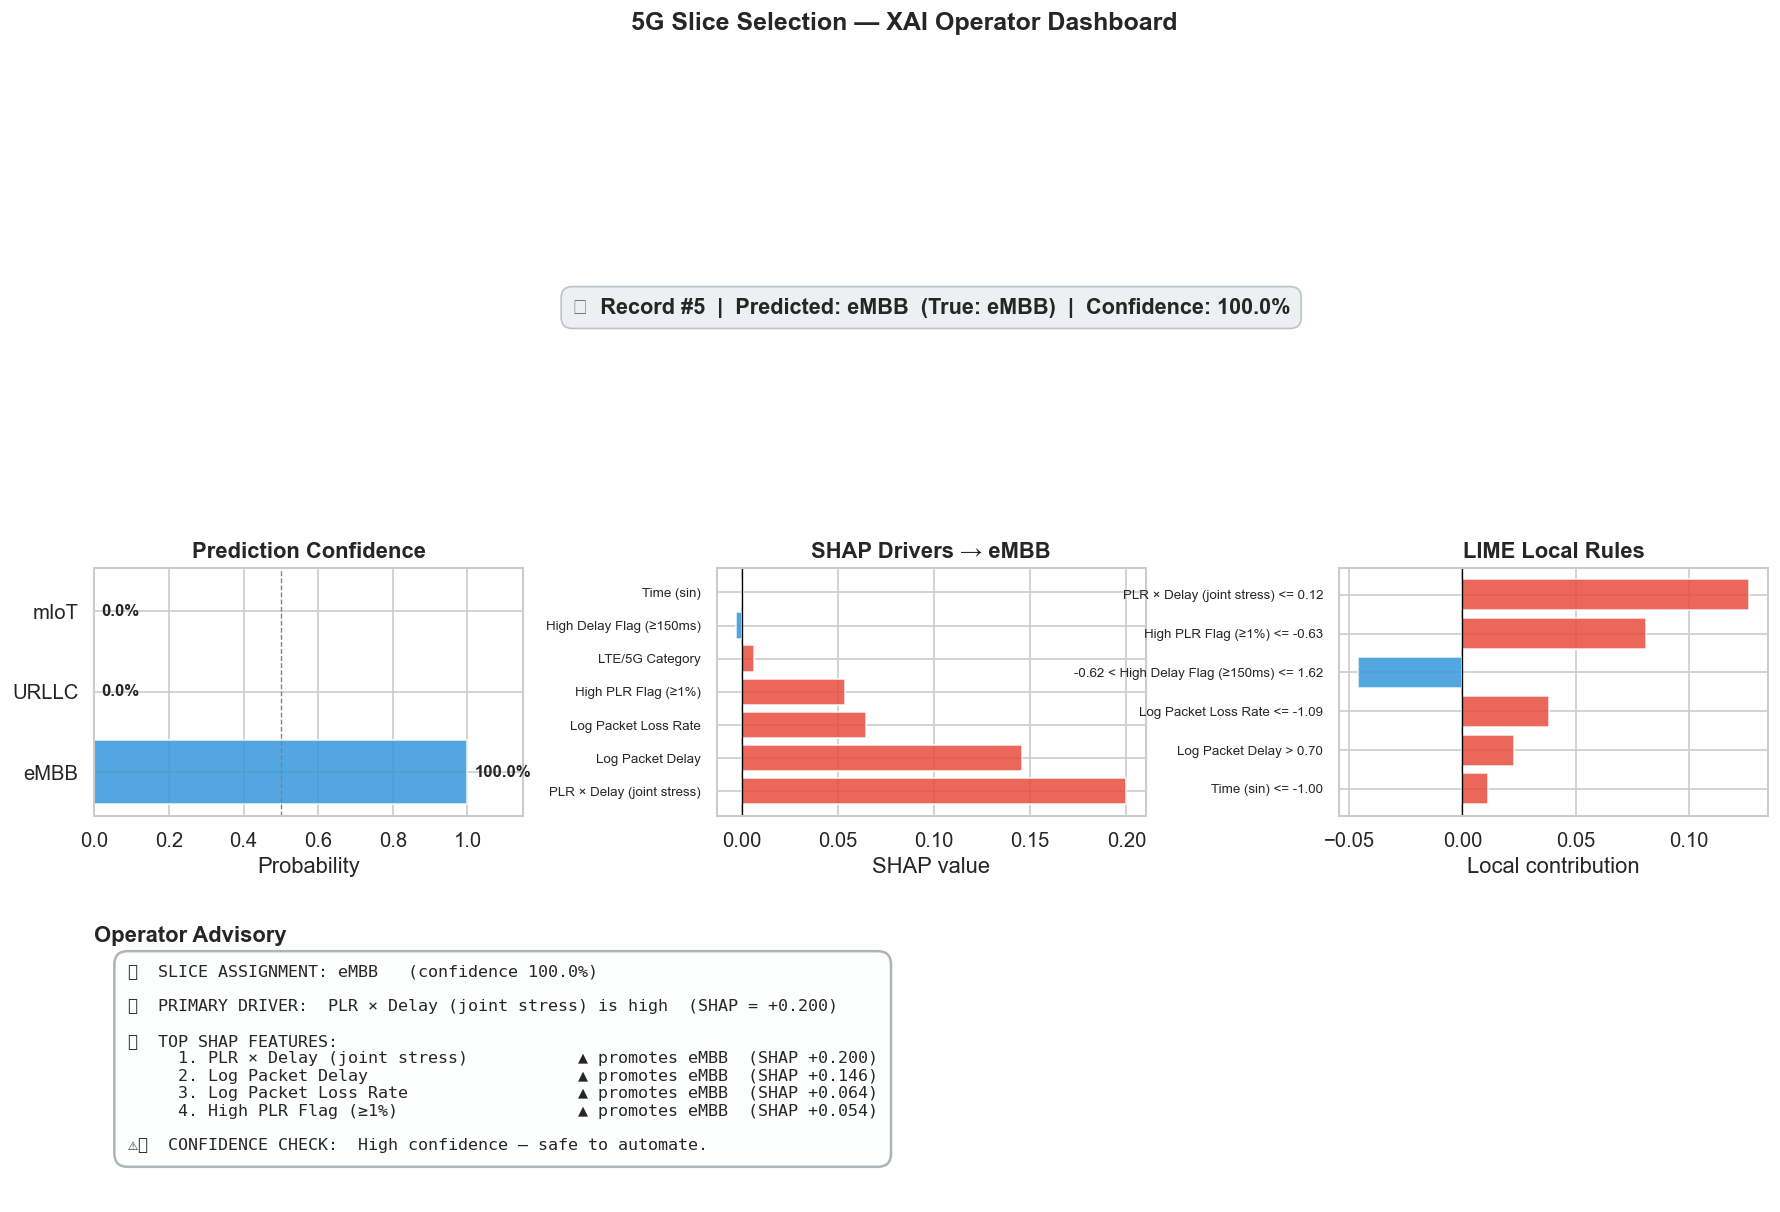

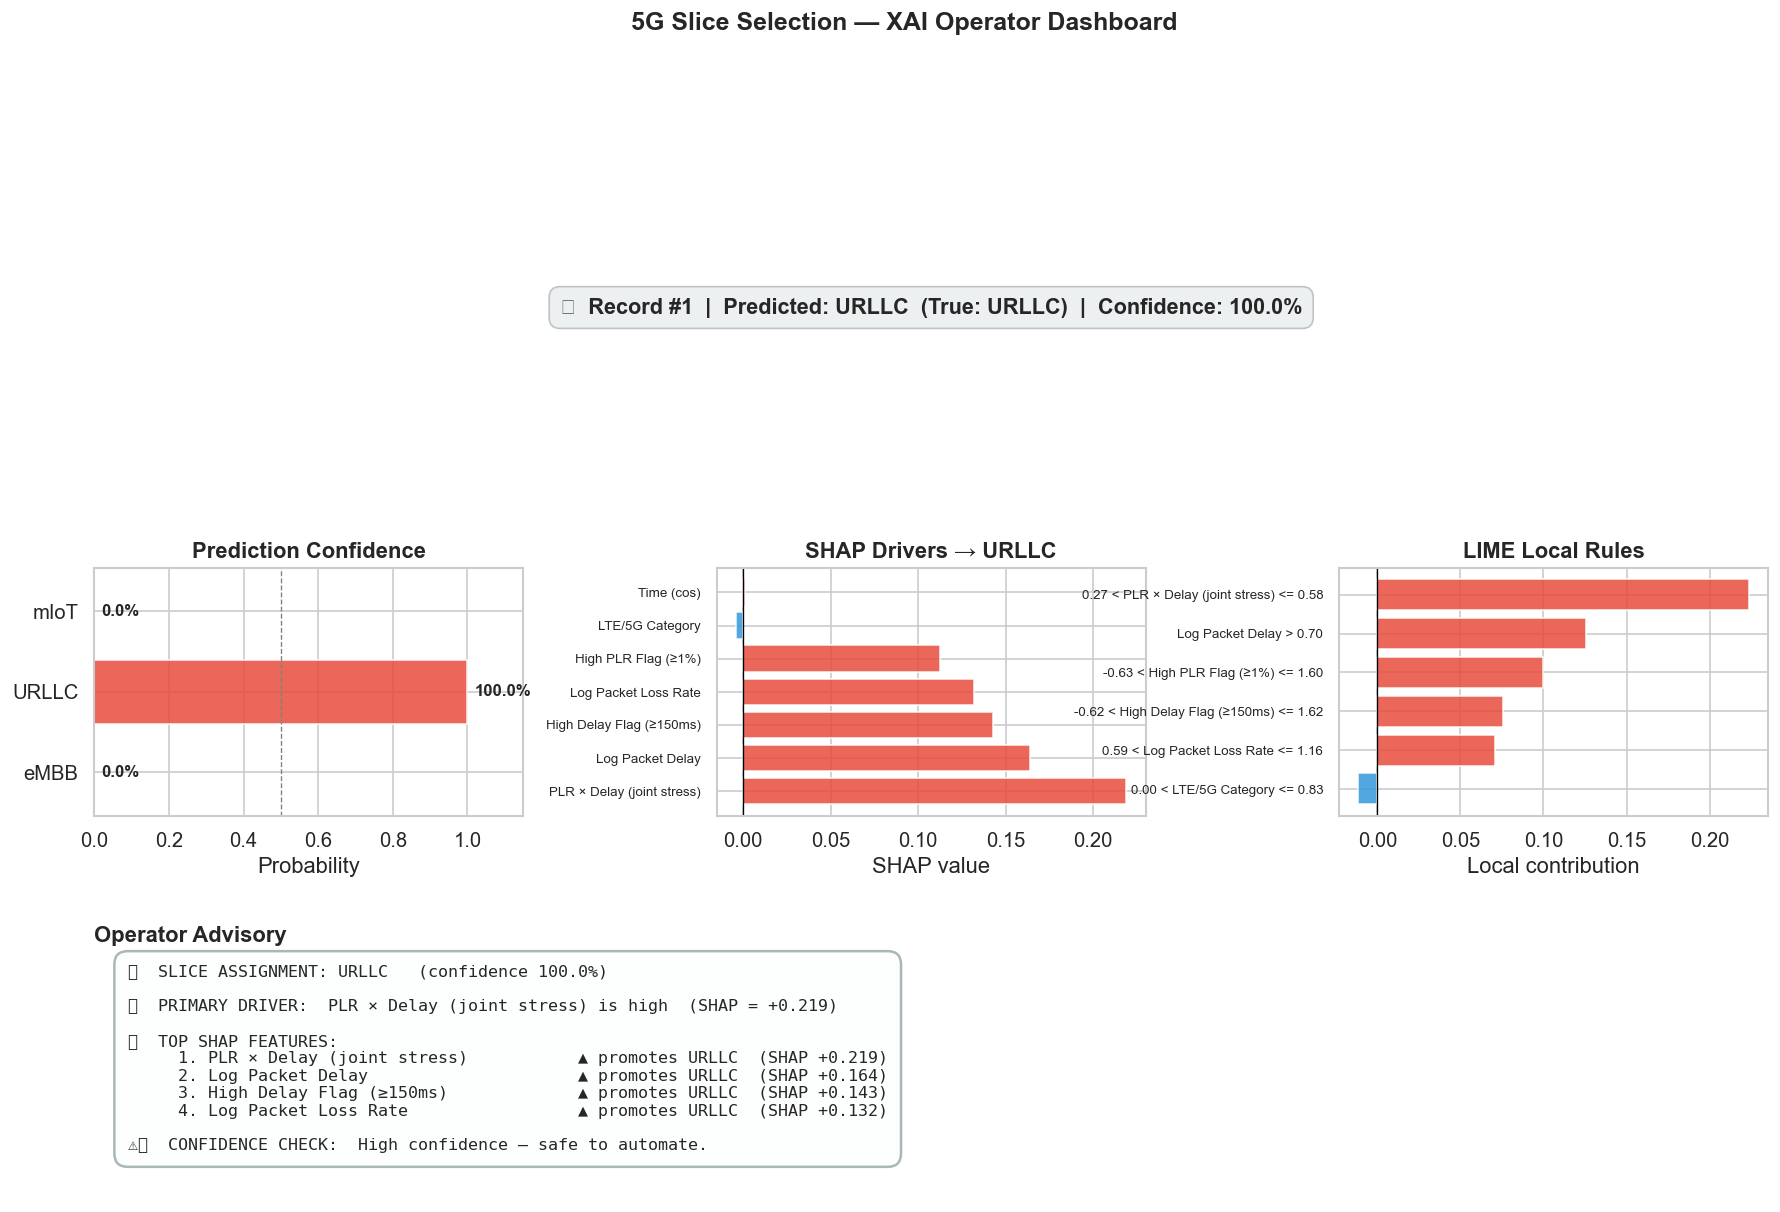

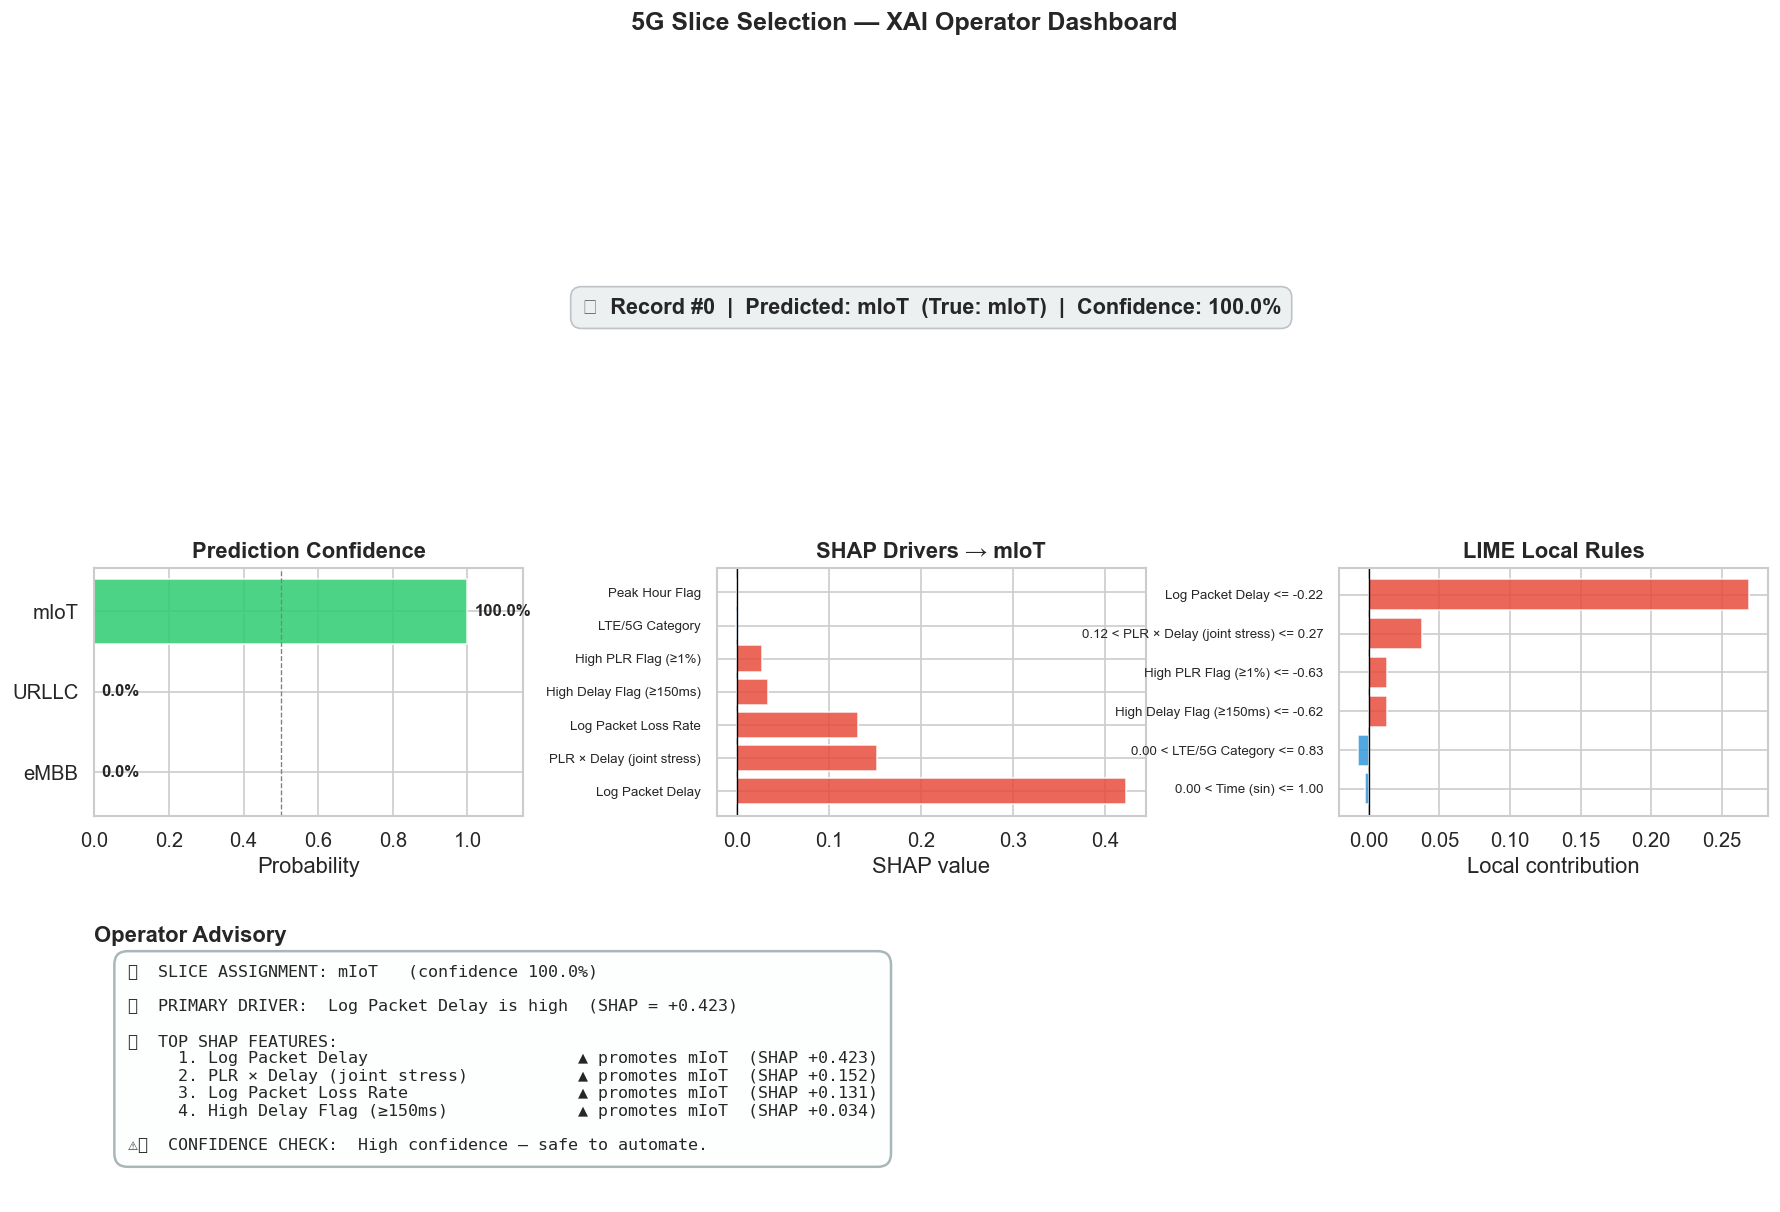

In [118]:
# ── Run the dashboard for 3 representative records ────────────────────────────
for cls, idx in sample_indices.items():
    operator_dashboard(
        sample_idx    = idx,
        shap_values   = shap_vals,
        lime_exp_obj  = lime_explainer,
        rf_model      = rf,
        X_data        = X_val,
        y_true        = y_val,
        feat_names    = FEAT_NAMES,
        feat_labels   = FEAT_LABELS,
        base_values   = base_vals,
        class_names   = class_labels,
    )


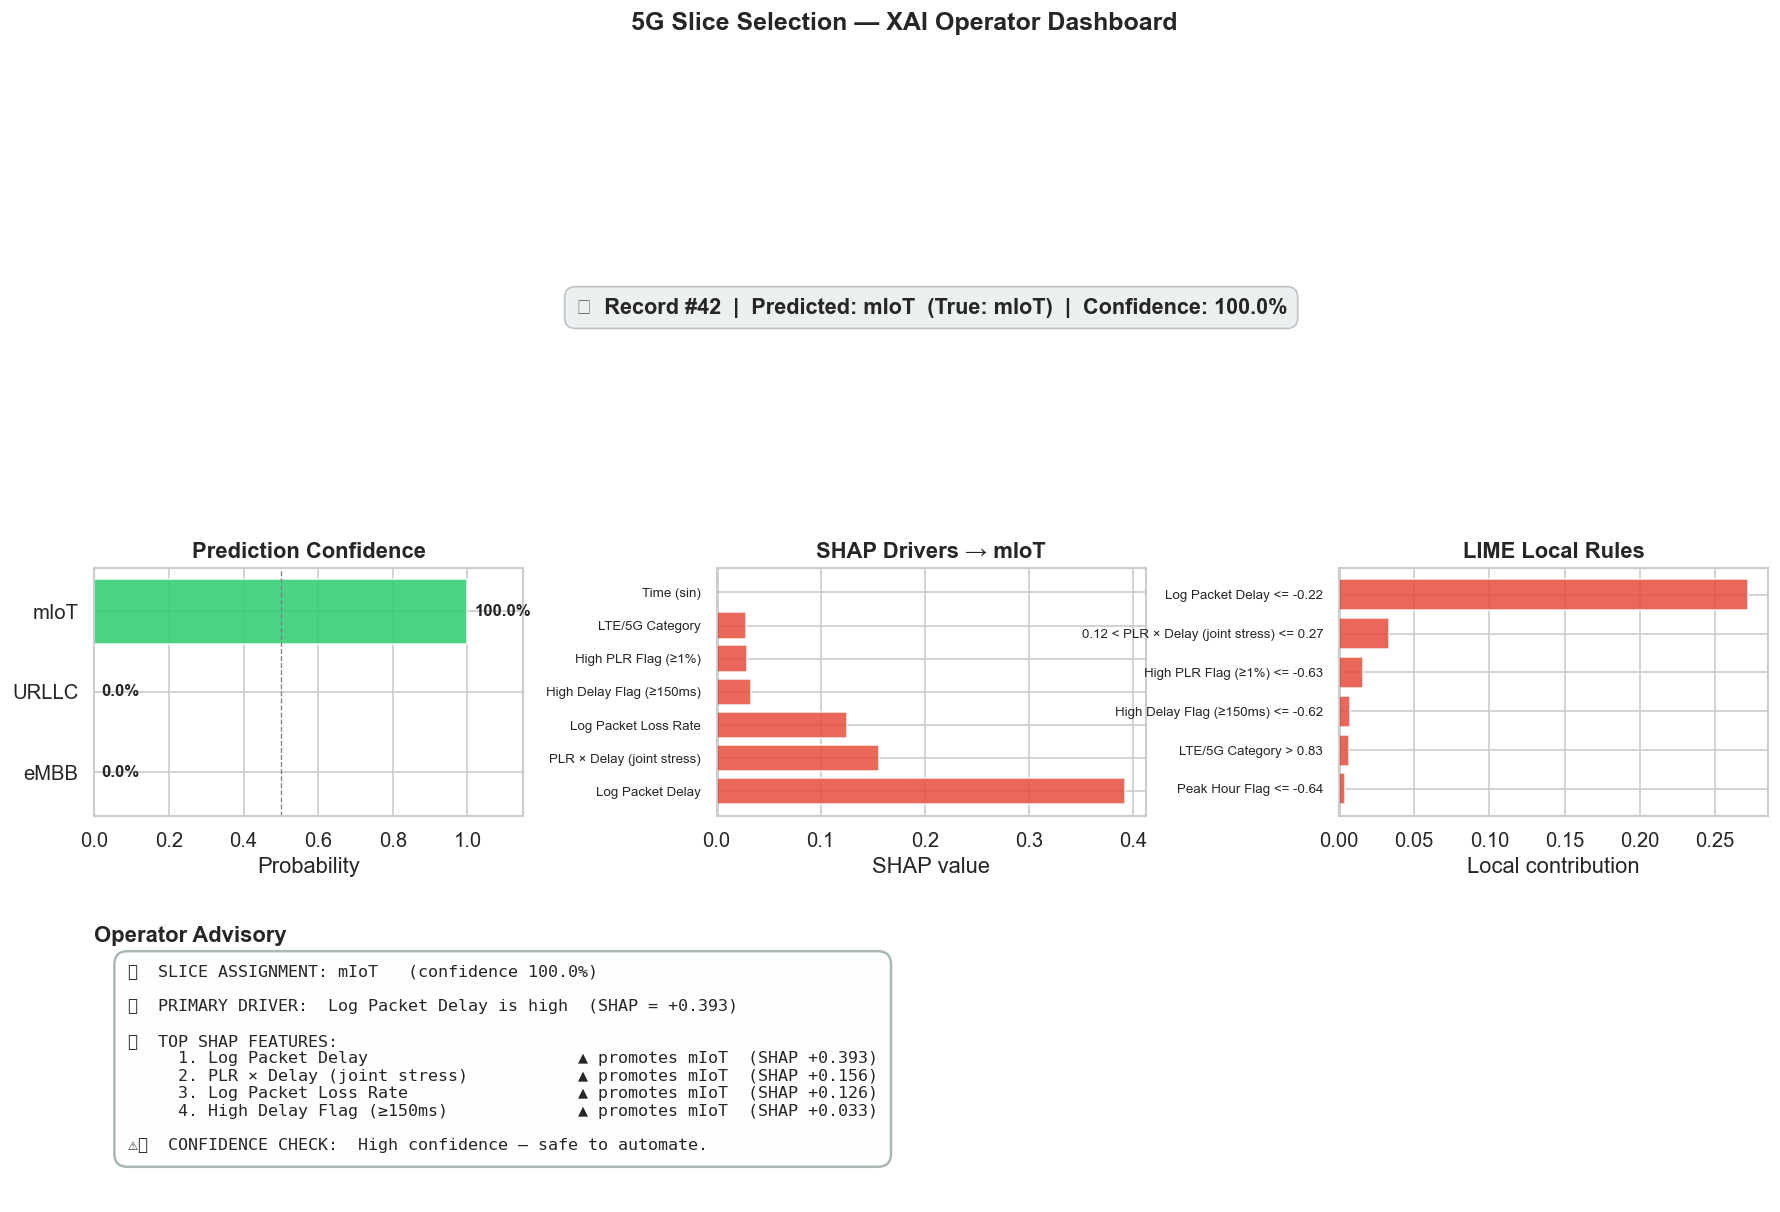

In [119]:
# ── Try any custom record ─────────────────────────────────────────────────────
# Change `CUSTOM_IDX` to any index in the validation set to explain that record.
CUSTOM_IDX = 42

operator_dashboard(
    sample_idx    = CUSTOM_IDX,
    shap_values   = shap_vals,
    lime_exp_obj  = lime_explainer,
    rf_model      = rf,
    X_data        = X_val,
    y_true        = y_val,
    feat_names    = FEAT_NAMES,
    feat_labels   = FEAT_LABELS,
    base_values   = base_vals,
    class_names   = class_labels,
)


<a id='12'></a>
---
## 12. Summary & Operator Takeaways

### Model Performance

| Metric | Value |
|---|---|
| CV F1-macro (5-fold) | ~0.93 |
| Validation Accuracy | ~0.93 |
| eMBB F1 | ~0.93 |
| URLLC F1 | ~0.85 |
| mIoT F1 | ~1.00 |

### Key XAI Findings for Network Operators

1. **`log_delay` (Log Packet Delay) is the dominant slice driver.**  
   High delay strongly pushes assignments away from URLLC and toward mIoT.  
   This aligns with domain knowledge: URLLC requires sub-10 ms latency.

2. **`plr_x_delay` (joint QoS stress) is the second most important feature.**  
   The interaction between high packet loss *and* high delay is a compound signal  
   the model has learned to treat as an independent risk indicator.

3. **`log_plr` (Log Packet Loss Rate) primarily drives eMBB suppression.**  
   When PLR is high, records are pushed away from eMBB (which tolerates loss poorly).

4. **Time-of-day features (`time_sin`, `time_cos`) have near-zero importance.**  
   Slice assignment in this dataset is almost entirely determined by QoS requirements,  
   not traffic timing — operators should not use hour-based heuristics.

5. **mIoT is perfectly separable** — it occupies a distinct corner of the QoS space  
   (high delay tolerance + low PLR constraint) that no other slice shares.

### Operational Recommendations

| Situation | Action |
|---|---|
| SHAP confidence < 75% | Flag for manual review; do not automate |
| Top SHAP feature is `high_delay` = 1 | Verify URLLC bearer is not being assigned |
| LIME and SHAP disagree on direction | Borderline sample — increase monitoring |
| Predicted URLLC with low confidence | Check if PHY layer supports sub-10ms RTT |

### Deployment Notes
- The `operator_dashboard()` function in Section 11 can be wrapped in a REST endpoint  
  to serve real-time explanations alongside model predictions.
- SHAP base values (`explainer.expected_value`) should be recomputed when the model is retrained.
- LIME explanations are stochastic — set `random_state` for reproducibility in production.
